In [1]:
import pandas as pd
import re
from difflib import get_close_matches
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
import numpy as np
from pathlib import Path
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from scipy.stats import chi2_contingency
from pathlib import Path
import statsmodels.api as sm
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.linear_model import RidgeCV, ElasticNetCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, f1_score,calinski_harabasz_score,davies_bouldin_score
from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from joblib import Parallel, delayed
import io, base64
from scipy.stats import kruskal
from IPython.display import HTML, display
from sklearn.multioutput import MultiOutputRegressor
from sklearn.impute import SimpleImputer
from sklearn.decomposition import IncrementalPCA 
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
!pip install imblearn
from sklearn.ensemble import GradientBoostingClassifier
!pip install xgboost
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
from xgboost import XGBRegressor
!pip install shap
from statsmodels.stats.multitest import multipletests
from scipy.stats import t as tdist
from sklearn.svm import SVR
import shap
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, make_scorer
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.feature_selection import f_regression
from scipy.stats import f
from statsmodels.stats.multitest import multipletests
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV, MultiTaskElasticNetCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import RidgeCV, MultiTaskElasticNetCV
from sklearn.cross_decomposition import PLSRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from joblib import Parallel, delayed
from scipy.stats import t
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# Data Loading

In [2]:
import yaml

# --- Load configuration file ---
with open("config_biorep1.yaml", "r") as f:
    config = yaml.safe_load(f)


genetic_path = config["data"]["genetic_data"]
aroma_path = config["data"]["aroma_data"]
pc_df_path = config["data"]["sensory_pca_pc_df"]


# --- Read CSV files ---
genetic_data = pd.read_csv(genetic_path)
aroma_df = pd.read_csv(aroma_path)
pc_df = pd.read_csv(pc_df_path)

# --- Display confirmations and previews ---
print(" Genetic data loaded from:", genetic_path)
print(genetic_data.head(5), "\n")

print(" Aroma data loaded from:", aroma_path)
print(aroma_df.head(5), "\n")

print(" PCA DataFrame loaded from:", pc_df_path)
pc_df.head(10)



 Genetic data loaded from: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Desktop/internship/bio_rep1/GeneMarkers-95 varieties 1.csv
   taglo_id  ATLANTIC_124776  ESCORT_159228  ARGOS_120931  ALTURAS_329540  \
0         7                0              0             0               0   
1        10                0              0             0               0   
2        13                0              0             0               0   
3        17                0              0             0               0   
4        21                0              0             0               0   

   ELMUNDO_835520  NADINE_241950  VIOLETQUEEN_3345402  DEODARA_513721  \
0               0              0                    0               0   
1               0              0                    0               0   
2               0              0                    0               0   
3               0              1                    0               0   
4               0              0        

,PC1,PC2,PC3,Variety,is_panel
0,7.797793,3.786555,-0.258905,ADORA,True
1,1.658722,-3.556767,1.917306,AGRIA,True
2,-1.051535,0.145923,3.496808,BERBER,True
3,1.577946,-3.208374,0.201062,BILDTSTAR,True
4,-2.531821,-0.997265,1.393942,BINTJE,True
5,2.147434,0.451214,-1.266318,CARRERA,True
6,-5.000658,2.756226,-0.678727,CECILE,True
7,-2.706073,0.430283,0.006144,CHALLENGER,True
8,3.236574,-0.560895,0.231981,DESIREE,True
9,2.316093,0.765887,0.141324,FABULA,True


# Data preparation

In [3]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import merge_genetic_aroma_sensory

# --- Load configuration ---
with open("config_biorep1.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- Read input data ---
genetic_data = pd.read_csv(config["data"]["genetic_data"])
aroma_df = pd.read_csv(config["data"]["aroma_data"])
sensory_pcs = pd.read_csv(config["data"]["sensory_pca_pc_df"])

# --- Run merge function ---
merged_snp_aroma, merged_snp_sensory, merged_all = merge_genetic_aroma_sensory(
    genetic_data, aroma_df, sensory_pcs
)


 Genetic table after reshape: (94, 262434)

# Aroma data cleanup summary:
  Total columns before: 47
  Dropped (all NaN): 0
  Final usable aroma columns: 47
  Sample aroma cols: ['1-Heptanol', '1-Nonanol', '1-Octen-3-ol', '1-Phenylethanol', '2,3-Pentanedione', '2,4-Decadienal', '2,6-Dimethylpyrazine', '2-Isopropyl-3-methoxypyrazine']

# Sensory PCs: 3
Sample sensory cols: ['PC1', 'PC2', 'PC3']

# Merge results:
  Genetic + Aroma: (94, 262481)
  Genetic + Sensory: (94, 262437)
  Genetic + Aroma + Sensory: (94, 262484)


# Exploratory analysis:

# 1.PCA of Genetic–Aroma Dataset

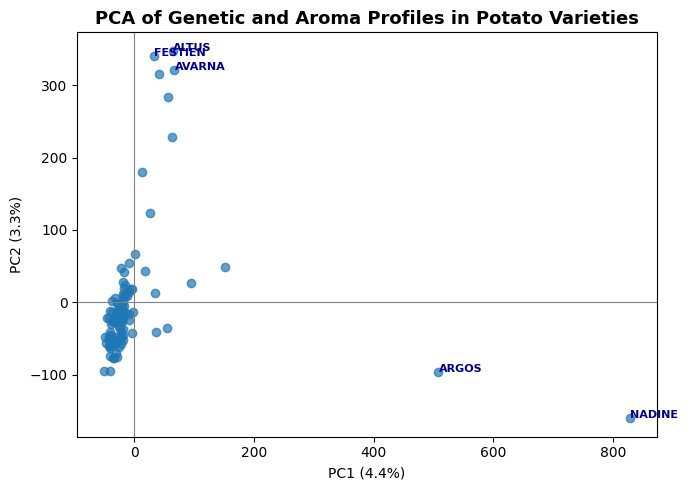

 PCA completed with 3 components.
Explained variance (first 2 PCs): [0.04357345 0.03250888]
Top 5% outliers: ['ALTUS', 'ARGOS', 'AVARNA', 'FESTIEN', 'NADINE']


In [4]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import perform_pca_with_outliers

pca_df, outliers, pca_model = perform_pca_with_outliers(
    merged_snp_aroma,
    n_components=3,
    outlier_percent=5,
    title="PCA of Genetic and Aroma Profiles in Potato Varieties"
)


# 2.PLSR on Genetic–Aroma Dataset

Top Influential Genes:
 GEN__168872    0.011551
GEN__321271    0.011551
GEN__30037     0.011551
GEN__321364    0.011551
GEN__168818    0.011551
GEN__321412    0.011551
GEN__168754    0.011551
GEN__321469    0.011551
GEN__169028    0.011551
GEN__320890    0.011551
dtype: float64

Top Influential Aroma Compounds:
 Acetic acid             0.012341
2-Methylthiazole        0.011767
Isovaleric acid         0.011551
Dimethyl disulfide      0.011551
Methional               0.010381
Methanethiol            0.009927
Furfural                0.008692
2,3-Pentanedione        0.006302
Propanal                0.005497
Butanoic acid           0.004596
1-Phenylethanol         0.004413
Ethyl acetate           0.004292
2-Methyl-1-propanol     0.004292
2,6-Dimethylpyrazine    0.004292
Ethyl propanoate        0.004292
Heptanal                0.004213
2,4-Decadienal          0.004205
Dimethyl trisulfide     0.003170
Pentanal                0.002682
Ethyl hexanoate         0.002162
dtype: float64


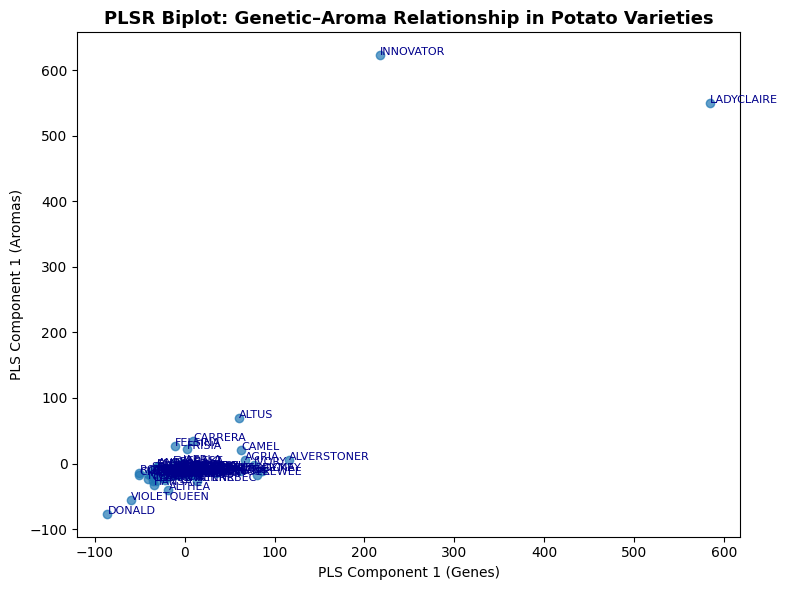


Explained variance (X, Y): (262434, 2), (47, 2)
Number of varieties analyzed: 94


In [5]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import analyze_gene_aroma_plsr
# Extract genetic and aroma parts from merged dataset
gd = merged_snp_aroma[[c for c in merged_snp_aroma.columns if c.startswith("GEN__")]]
A = merged_snp_aroma[[c for c in merged_snp_aroma.columns if not c.startswith("GEN__")]]



pls_model, top_genes, top_aromas = analyze_gene_aroma_plsr(
    merged_snp_aroma,
    n_components=2,
    top_genes=10,
    top_aromas=20
)


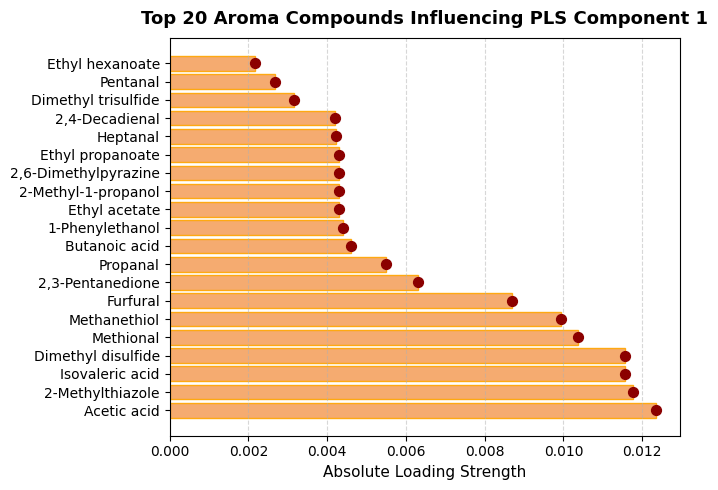

In [6]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_top_aroma_loadings_horizontal
plot_top_aroma_loadings_horizontal(top_aromas)


# 3.HCA (Ward, Euclidean) on SNP-linked aroma profiles (EDA)

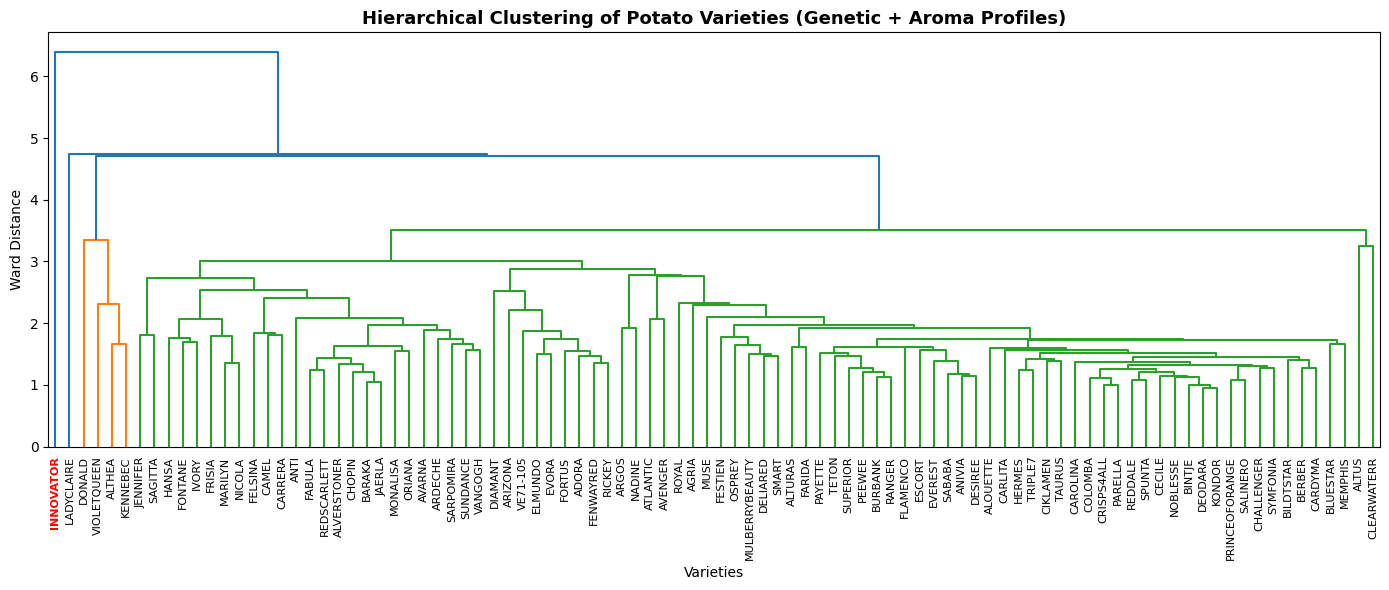

In [7]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_balanced_dendrogram_snp_aroma

Z = plot_balanced_dendrogram_snp_aroma(
    merged_snp_aroma,
    highlight_varieties=("Lady Claire", "Innovator"),
    title="Hierarchical Clustering of Potato Varieties (Genetic + Aroma Profiles)"
)


# 1. PCA of  Genetic–Sensory dataset

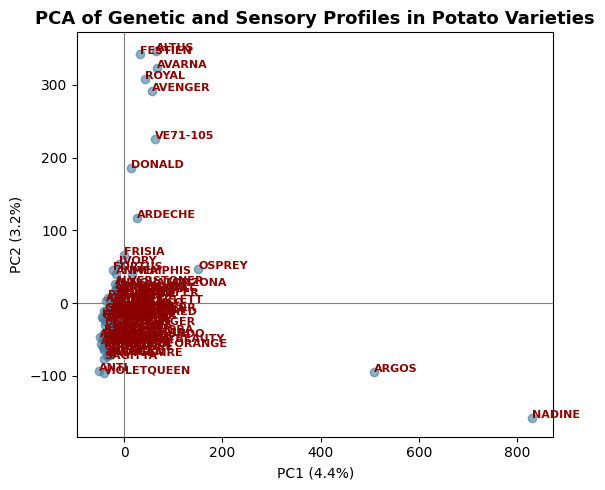

 PCA completed with 2 components.
Explained variance ratio (PC1+PC2): 7.61%
Outliers detected (94): ['ADORA', 'AGRIA', 'ALOUETTE', 'ALTHEA', 'ALTURAS', 'ALTUS', 'ALVERSTONER', 'ANIVIA', 'ANTI', 'ARDECHE', 'ARGOS', 'ARIZONA', 'ATLANTIC', 'AVARNA', 'AVENGER', 'BARAKA', 'BERBER', 'BILDTSTAR', 'BINTJE', 'BLUESTAR', 'BURBANK', 'CAMEL', 'CARDYMA', 'CARLITA', 'CAROLINA', 'CARRERA', 'CECILE', 'CHALLENGER', 'CHOPIN', 'CIKLAMEN', 'CLEARWATERR', 'COLOMBA', 'CRISPS4ALL', 'DELIARED', 'DEODARA', 'DESIREE', 'DIAMANT', 'DONALD', 'ELMUNDO', 'ESCORT', 'EVEREST', 'EVORA', 'FABULA', 'FARIDA', 'FELSINA', 'FENWAYRED', 'FESTIEN', 'FLAMENCO', 'FONTANE', 'FORTUS', 'FRISIA', 'HANSA', 'HERMES', 'INNOVATOR', 'IVORY', 'JAERLA', 'JENNIFER', 'KENNEBEC', 'KONDOR', 'LADYCLAIRE', 'MARILYN', 'MEMPHIS', 'MONALISA', 'MULBERRYBEAUTY', 'MUSE', 'NADINE', 'NICOLA', 'NOBLESSE', 'ORIANA', 'OSPREY', 'PARELLA', 'PAYETTE', 'PEEWEE', 'PRINCEOFORANGE', 'RANGER', 'REDDALE', 'REDSCARLETT', 'RICKEY', 'ROYAL', 'SABABA', 'SAGITTA', 'SALI

In [8]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import perform_pca_gene_sensory

pca_df, pca_model, outliers = perform_pca_gene_sensory(
    merged_snp_sensory,
    n_components=2,
    outlier_threshold_pc1=4,
    outlier_threshold_pc2=3,
    title="PCA of Genetic and Sensory Profiles in Potato Varieties"
)


# 2.PLSR on Genetic–Sensory Dataset

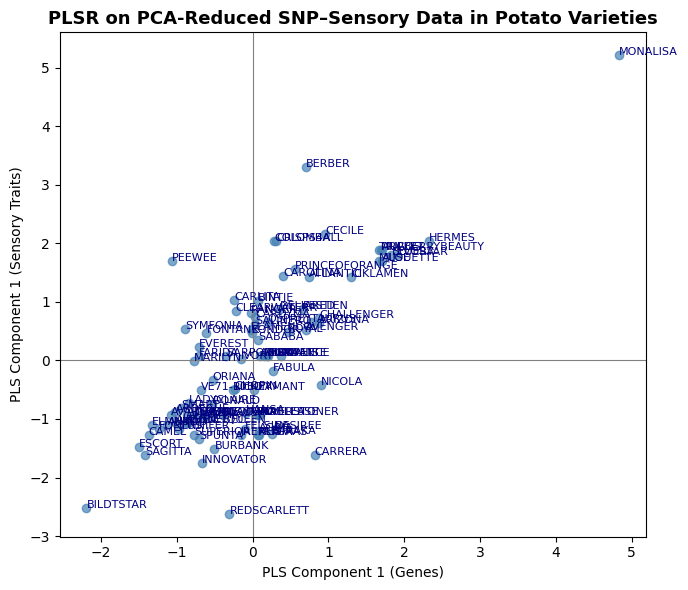

 PCA reduced SNPs to 50 components.
 PLSR computed 2 components.
Explained variance in PCA (first 3 comps): [0.04358077 0.03251347 0.02907683]
Samples plotted: 94 varieties.


In [9]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import perform_pca_plsr_gene_sensory


pca_model, pls_model, pls_scores_df = perform_pca_plsr_gene_sensory(
    merged_snp_sensory,
    n_pca_components=50,
    n_pls_components=2,
    title="PLSR on PCA-Reduced SNP–Sensory Data in Potato Varieties"
)


# 3.Hierarchical Clustering of Potato Varieties Based on Combined SNP and Sensory Profiles

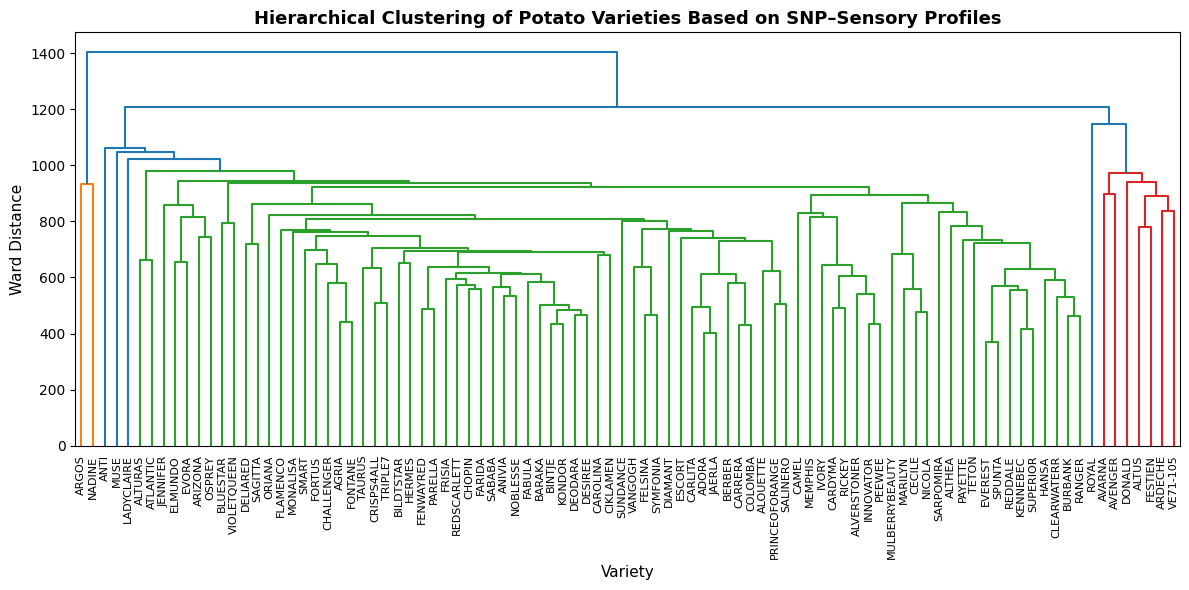

 HCA completed using ward linkage and euclidean distance.
Samples clustered: 94, Features used: 261113


In [10]:
import importlib   
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import perform_hca_gene_sensory

Z = perform_hca_gene_sensory(
    merged_snp_sensory,
    metric="euclidean",
    method="ward",
    color_threshold_ratio=0.7,
    title="Hierarchical Clustering of Potato Varieties Based on SNP–Sensory Profiles"
)


# Feature selection

# Genome-Wide Association Study (GWAS) with FDR Correction and LD Pruning on Genetic–aroma Data

In [44]:

import yaml
import importlib
from scipy.stats import f
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import perform_gwas_for_traits

# --- Load config ---
with open("config_biorep1.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- Define path from config ---
gwas_gene_aroma_output = config["data"]["gwas_output_gene_aroma"]

# --- Run GWAS (this creates the CSV file) ---
all_gwas_gene_aroma_df = perform_gwas_for_traits(
    merged_df=merged_snp_aroma,
    snp_prefix="GEN__",
    output_path=gwas_gene_aroma_output,
    ld_threshold=0.95,
    top_n_snps=500
)

print(f"\n GWAS for Gene–Aroma completed successfully.")
print(f"Results saved to: {gwas_gene_aroma_output}")





Detected 262434 SNP columns and 47 numeric traits.



Running GWAS per trait:   0%|          | 0/47 [00:00<?, ?it/s]


Processing trait: 1-Heptanol
  - Initial SNPs: 262434
  - After selecting top 500: 500 SNPs


Running GWAS per trait:   2%|▏         | 1/47 [03:16<2:30:57, 196.90s/it]

  - After LD pruning (r² < 0.95): 1 SNPs retained

Processing trait: 1-Nonanol
  - Initial SNPs: 262434


...

Running GWAS per trait:  98%|█████████▊| 46/47 [2:25:59<03:09, 189.38s/it]

  - After selecting top 500: 500 SNPs
  - After LD pruning (r² < 0.95): 1 SNPs retained

Processing trait: Tetramethylpyrazine
  - Initial SNPs: 262434


Running GWAS per trait: 100%|██████████| 47/47 [2:29:06<00:00, 190.34s/it]

  - After selecting top 500: 500 SNPs
  - After LD pruning (r² < 0.95): 1 SNPs retained



All GWAS results saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv


The genomic dataset initially contained 262,434 SNP markers.
After applying quality control filters based on Minor Allele Frequency (MAF)
and missingness thresholds, a high-confidence subset of SNPs was retained.
To minimize redundancy among highly correlated markers, linkage disequilibrium (LD)
pruning was performed using an r² threshold of 0.95, resulting in
an independent SNP set suitable for association analysis.

For each of the 47 traits, genome-wide associations were calculated
by correlating SNP genotypes with trait values, followed by false discovery rate (FDR)
correction using the 'fdr_bh' method to control for multiple testing.
The top 500 SNPs per trait (with the lowest adjusted p-values)
were selected and subjected to a second LD pruning step (r² < 0.95)
to remove redundant variants.

This analysis produced a total of 12,272

In [12]:
import yaml
import yaml
import importlib
import os
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import perform_multitrait_gwas

# --- Load config ---
with open("config_biorep1.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- Define paths from config or manually ---
os.makedirs("results", exist_ok=True)  
gwas_multitrait_output = "results/gwas_gene_aroma_multitrait.csv"

# --- Run multi-trait GWAS ---
all_multitrait_gwas_df = perform_multitrait_gwas(
    merged_df=merged_snp_aroma,
    snp_prefix="GEN__",
    output_path=gwas_multitrait_output,
    ld_threshold=0.95,
    top_n_snps=500
)

print("\n Multi-trait GWAS completed successfully.")
print(f"Results saved to: {gwas_multitrait_output}")


Detected 262434 SNP columns and 47 numeric traits.



Running Multi-trait GWAS per SNP: 100%|██████████| 262434/262434 [31:39<00:00, 138.13it/s] 



 Multi-trait GWAS results saved to: results/gwas_gene_aroma_multitrait.csv

 Multi-trait GWAS completed successfully.
Results saved to: results/gwas_gene_aroma_multitrait.csv


Detected traits: ['1-Heptanol', '1-Nonanol', '1-Octen-3-ol', '1-Phenylethanol', '2,3-Pentanedione', '2,4-Decadienal', '2,6-Dimethylpyrazine', '2-Isopropyl-3-methoxypyrazine', '2-Methyl-1-propanol', '2-Methylthiazole', '2-Nonanone', '2-Propanone, 1-methoxy-', '3-Heptanone', '3-Octanone', 'Acetic acid', 'Acetophenone', 'Benzaldehyde', 'Benzeneacetaldehyde', 'Benzyl alcohol', 'Butanal, 3-methyl-', 'Butanoic acid', 'Decanal', 'Dimethyl disulfide', 'Dimethyl trisulfide', 'Ethanol', 'Ethyl acetate', 'Ethyl hexanoate', 'Ethyl pentanoate', 'Ethyl propanoate', 'Furfural', 'Heptanal', 'Hexanal', 'Hexanoic acid', 'Hexanol', 'Isoamyl acetate', 'Isovaleric acid', 'Methanethiol', 'Methional', 'Methyl butanoate', 'Nonanal', 'Octanal', 'Octanoic acid', 'Pentanal', 'Phenylacetaldehyde', 'Propanal', 'Propanoic acid', 'Tetramethylpyrazine']
Selected top 128 SNPs for multitrait modeling.
128 SNPs retained after LD pruning.
Best α = 1.6298, γ = 28.4804

Average Performance Across Traits:
  R2: 0.498
  MSE:

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2376: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="R2", y="Trait", data=results_df.sort_values("R2", ascending=False), palette="viridis")


 Plot saved → results/krr_multitrait\multitrait_krr_plot_gene_aroma.png


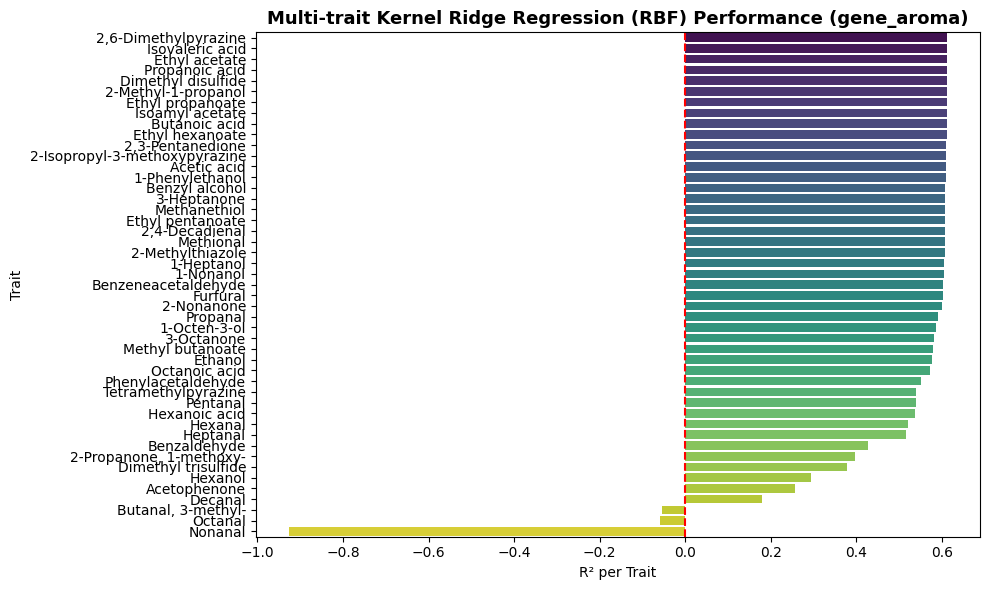

In [13]:
import yaml
import importlib
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_multitrait_krr_model
trait_columns = [
    c for c in merged_snp_aroma.columns
    if not c.startswith("GEN__") and np.issubdtype(merged_snp_aroma[c].dtype, np.number)
]
print("Detected traits:", trait_columns)

results_df, preds = run_multitrait_krr_model(
    gwas_file="results/gwas_gene_aroma_multitrait.csv",
    snp_df=merged_snp_aroma,
    trait_columns= trait_columns,
    top_n_snps=6000,
    prune_threshold=0.95,
    save_dir="results/krr_multitrait",
    tag="gene_aroma"
)

In [14]:
import yaml
import importlib
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_nonlinear_models_multitrait

trait_columns= [c for c in merged_snp_aroma.columns if c.startswith("Aroma_")]



multi_gwas_file = "results/gwas_gene_aroma_multitrait.csv"
gwas_df = pd.read_csv(multi_gwas_file)

print("Multi-trait GWAS shape:", gwas_df.shape)
print(gwas_df.head())  # optional, to inspect first few rows

results_multi_df = run_nonlinear_models_multitrait(
    gwas_file="results/gwas_gene_aroma_multitrait.csv",
    snp_df=merged_snp_aroma,
    trait_columns= trait_columns,
    top_n_snps=500,
    prune_threshold=0.95,
    save_dir="results",
    tag="aroma_multitrait"
)




Multi-trait GWAS shape: (128, 4)
       SNP   F_value  p_value  p_fdr
0  GEN__10  0.000934      1.0    1.0
1  GEN__13  0.010717      1.0    1.0
2  GEN__17  0.001326      1.0    1.0
3  GEN__21  0.002679      1.0    1.0
4  GEN__22  0.001456      1.0    1.0
 Results saved → results\nonlinear_models_multitrait_aroma_multitrait.csv


# GWas results

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:980: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


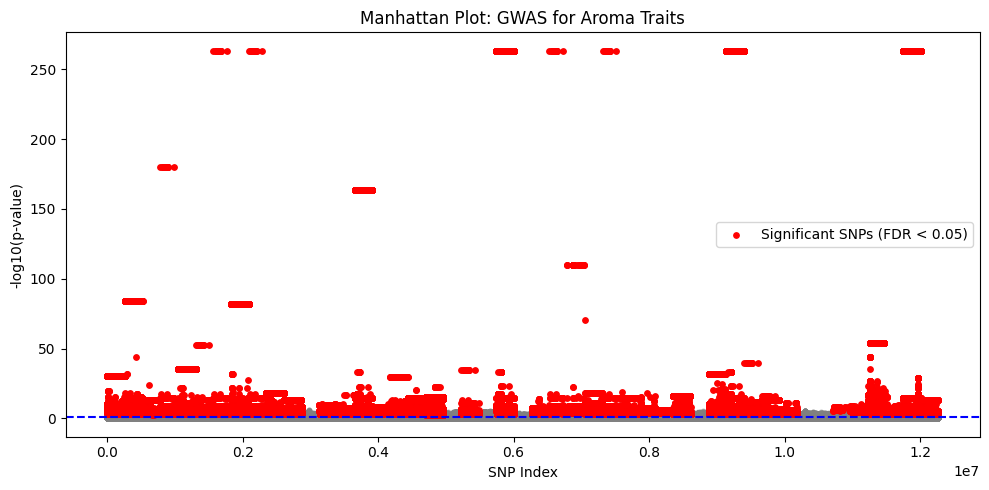

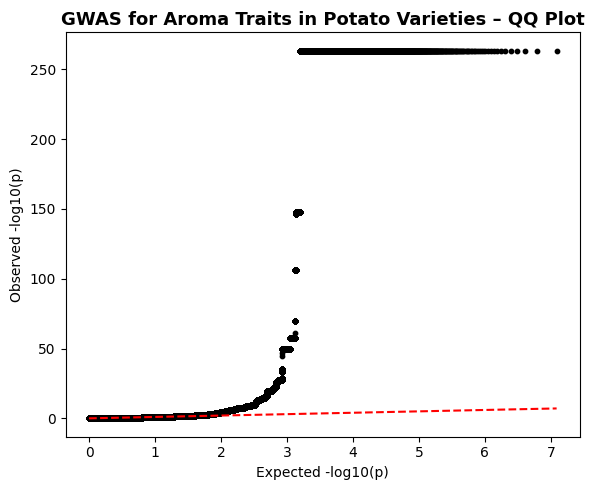

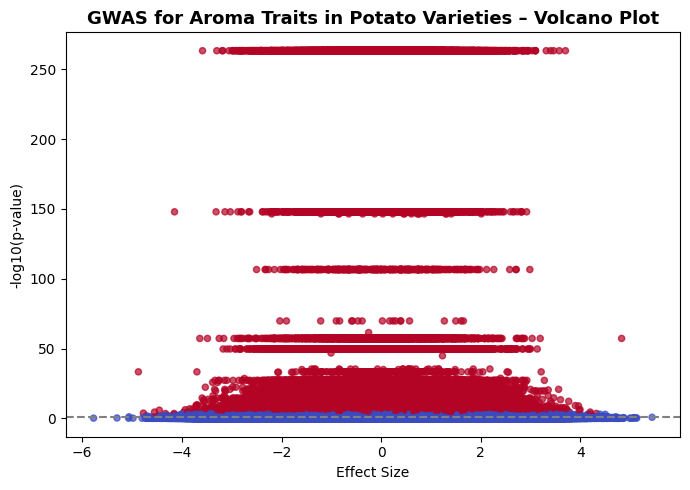

In [15]:
import importlib
import yaml
import pandas as pd
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_gwas_full_report

# Load configuration
with open("config_biorep1.yaml", "r") as f:
    config = yaml.safe_load(f)


# Get GWAS file path
gwas_gene_aroma_output = config["data"]["gwas_output_gene_aroma"]

#  Read file into DataFrame
gwas_df = pd.read_csv(gwas_gene_aroma_output)

# Call plotting function with the DataFrame
plot_gwas_full_report(
    gwas_df,
    title_prefix="GWAS for Aroma Traits in Potato Varieties"
)



# Multivariate Analysis of GWAS-Selected Features Using PCA, PLSR, and HCA

 Selected 66696 SNPs below FDR < 0.05


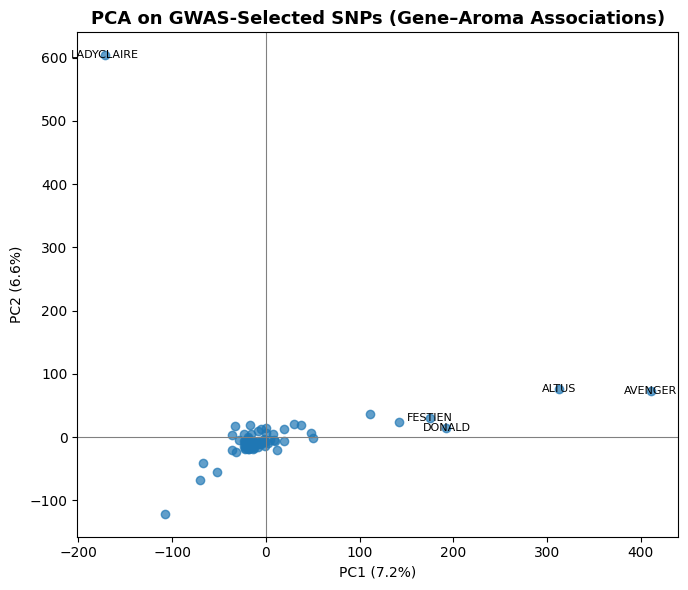

Explained variance: PC1 = 7.19%, PC2 = 6.61%


In [16]:
import importlib
import yaml
import pandas as pd
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import pca_after_gwas_feature_selection_gene_aroma

# Run PCA after feature selection
pca_model, scores = pca_after_gwas_feature_selection_gene_aroma(
    merged_snp_aroma=merged_snp_aroma,
    gwas_df=gwas_df,
    fdr_threshold=0.05,
    n_components=2,
    title="PCA on GWAS-Selected SNPs (Gene–Aroma Associations)"
)

 Selected 66696 SNPs below FDR < 0.05


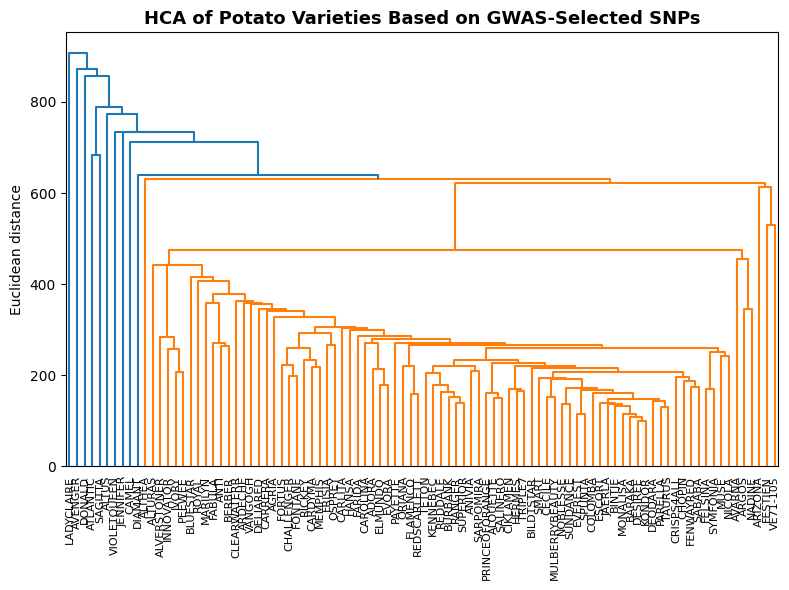

In [43]:
import importlib
import yaml
import pandas as pd
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import hca_after_gwas_feature_selection_gene_aroma
Z = hca_after_gwas_feature_selection_gene_aroma(
    merged_snp_aroma,
    gwas_df=gwas_df,
    highlight_varieties=("Lady Claire", "Innovator"),
    title="HCA of Potato Varieties Based on GWAS-Selected SNPs"
)


 Selected 66696 SNPs after GWAS feature selection (FDR < 0.05).


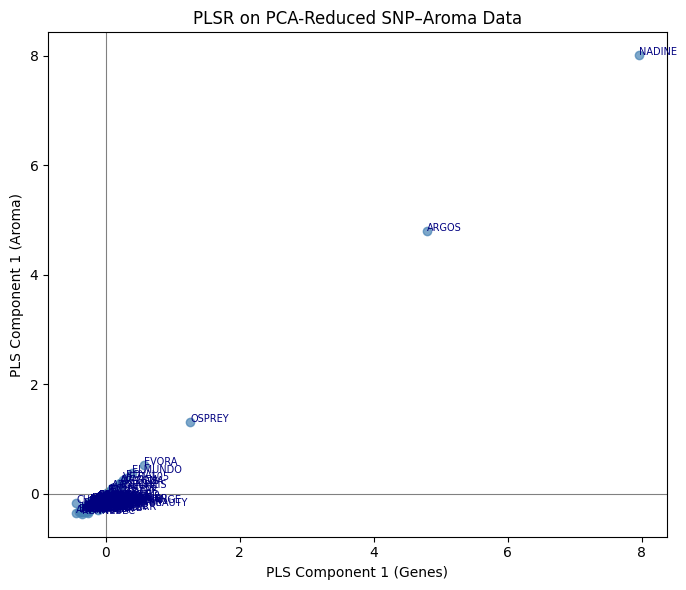

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
import matplotlib.pyplot as plt

def plsr_after_gwas_selection(
    merged_snp_aroma,
    gwas_file,
    fdr_col='p_fdr',
    snp_col='SNP',
    fdr_threshold=0.05,
    n_pca_components=50,
    n_pls_components=2,
    title="PLSR on PCA-Reduced SNP–Aroma Data"
):
    """
    Run PCA on GWAS-selected SNPs and perform PLSR with aroma traits.

    Parameters
    ----------
    merged_snp_aroma : pd.DataFrame
        Combined dataset of SNPs (GEN__ prefix) and aroma traits.
    gwas_file : str
        Path to the GWAS results CSV file.
    fdr_col : str, default='p_fdr'
        Column name for FDR-corrected p-values in the GWAS file.
    snp_col : str, default='SNP'
        Column name for SNP identifiers.
    fdr_threshold : float, default=0.05
        FDR threshold for selecting significant SNPs.
    n_pca_components : int, default=50
        Number of PCA components to retain.
    n_pls_components : int, default=2
        Number of PLS components.
    title : str, default="PLSR on PCA-Reduced SNP–Aroma Data"
        Title for the plot.

    Returns
    -------
    pca : PCA object
        Fitted PCA model.
    pls : PLSRegression object
        Fitted PLS model.
    X_scores, Y_scores : np.ndarray
        PLS component scores for SNP and aroma data.
    """

    # --- Load GWAS results ---
    gwas_df = pd.read_csv(gwas_file)

    # --- Select top SNPs based on FDR threshold ---
    top_snps = gwas_df.loc[gwas_df[fdr_col] < fdr_threshold, snp_col].unique().tolist()
    print(f" Selected {len(top_snps)} SNPs after GWAS feature selection (FDR < {fdr_threshold}).")

    if len(top_snps) == 0:
        print(" No SNPs passed the FDR threshold. Exiting.")
        return None, None, None, None

    # --- Prepare X (SNPs) and Y (aroma traits) ---
    X = merged_snp_aroma[top_snps].fillna(0).astype(float)
    Y = merged_snp_aroma[[c for c in merged_snp_aroma.columns if c not in top_snps]].select_dtypes(include=[np.number]).fillna(0)

    # --- Standardize ---
    X_scaled = StandardScaler().fit_transform(X)
    Y_scaled = StandardScaler().fit_transform(Y)

    # --- PCA reduction on SNPs ---
    pca = PCA(n_components=n_pca_components)
    X_reduced = pca.fit_transform(X_scaled)

    # --- PLS regression ---
    pls = PLSRegression(n_components=n_pls_components)
    pls.fit(X_reduced, Y_scaled)

    # --- Extract scores ---
    X_scores = pls.x_scores_
    Y_scores = pls.y_scores_

    # --- Plot (same as your version) ---
    plt.figure(figsize=(7, 6))
    plt.scatter(X_scores[:, 0], Y_scores[:, 0], alpha=0.7, color='steelblue')

    for i, name in enumerate(merged_snp_aroma.index):
        plt.text(X_scores[i, 0], Y_scores[i, 0], name, fontsize=7, color='navy')

    plt.axhline(0, color='gray', lw=0.8)
    plt.axvline(0, color='gray', lw=0.8)
    plt.xlabel("PLS Component 1 (Genes)")
    plt.ylabel("PLS Component 1 (Aroma)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return pca, pls, X_scores, Y_scores
pca_model, pls_model, X_scores, Y_scores = plsr_after_gwas_selection(
    merged_snp_aroma=merged_snp_aroma,
    gwas_file="C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
    fdr_threshold=0.05,
    n_pca_components=50,
    n_pls_components=2
)


 Selected 66696 SNPs after GWAS feature selection (FDR < 0.05).

 PLSR model fitted successfully.

 Found 3 key varieties: ['NADINE', 'ARGOS', 'OSPREY']

 Top 10 differentiating aroma compounds for NADINE:


Hexanol                    0.915024
Nonanal                    0.879514
Butanal, 3-methyl-         0.845016
2-Propanone, 1-methoxy-    0.836134
Benzaldehyde               0.696223
Acetophenone               0.540147
Heptanal                   0.511797
Hexanoic acid              0.454328
Pentanal                   0.448897
Phenylacetaldehyde         0.413339
Name: NADINE, dtype: float64


 Top 10 differentiating aroma compounds for ARGOS:


Nonanal                    1.884182
Acetophenone               1.748633
Octanal                    1.325691
Butanal, 3-methyl-         1.321233
Decanal                    1.066436
Hexanol                    0.915024
Dimethyl trisulfide        0.787600
2-Propanone, 1-methoxy-    0.757087
Benzaldehyde               0.700332
Heptanal                   0.511797
Name: ARGOS, dtype: float64


 Top 10 differentiating aroma compounds for OSPREY:


Nonanal                    1.825815
Butanal, 3-methyl-         1.321233
Octanal                    1.000635
Hexanol                    0.915024
Acetophenone               0.848302
Decanal                    0.791932
Dimethyl trisulfide        0.787600
2-Propanone, 1-methoxy-    0.757087
Benzaldehyde               0.697083
Heptanal                   0.511797
Name: OSPREY, dtype: float64

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:1380: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


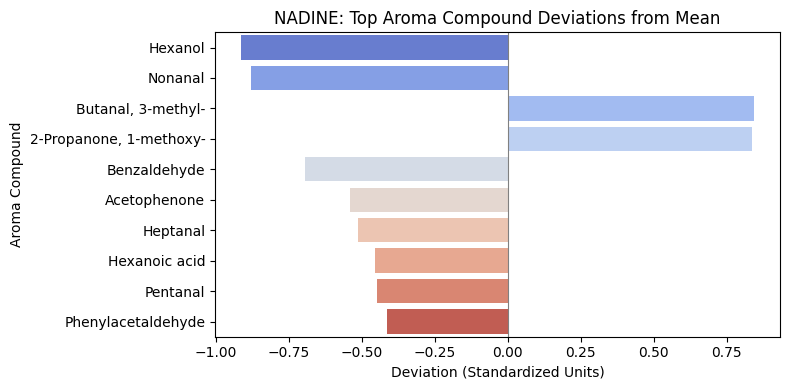

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:1380: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


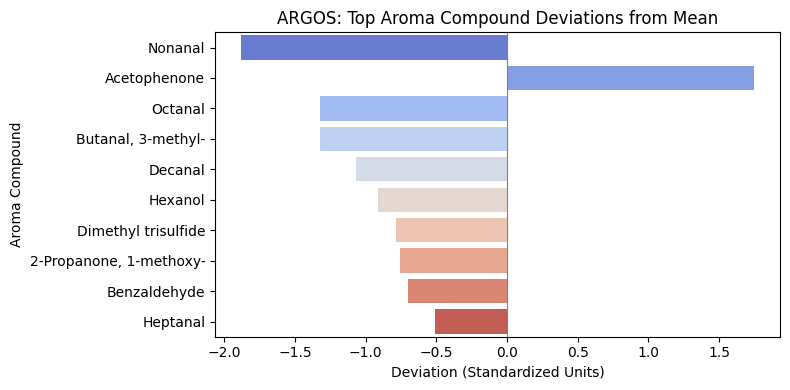

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:1380: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


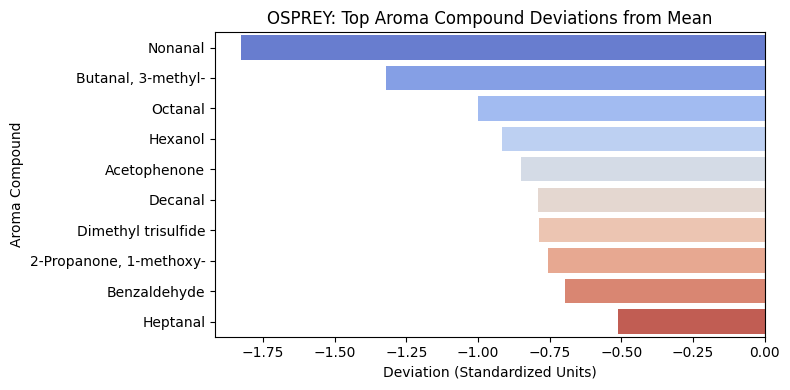


 Results saved as: key_variety_top_aroma_compounds.csv


In [18]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import analyze_key_variety_aroma_profiles

summary_df = analyze_key_variety_aroma_profiles(
    merged_snp_aroma=merged_snp_aroma,
    gwas_path=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
    key_varieties=["NADINE", "ARGOS", "OSPREY"],
    top_n_compounds=10,
    save_path="key_variety_top_aroma_compounds.csv"
)


# Genome-Wide Association Study (GWAS) with FDR Correction and LD Pruning on Genetic–Sensory Data

In [19]:

import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_gwas_for_sensory_pcs

# --- Load configuration file ---
with open("config_biorep1.yaml", "r") as f:
    config = yaml.safe_load(f)

# --- Extract GWAS output path from config ---
gwas_output_sensory = config["data"]["gwas_output_sensory"]

# --- Run GWAS using parameters from config ---
all_gwas_df_sensory = run_gwas_for_sensory_pcs(
    merged_snp_sensory=merged_snp_sensory,
    snp_prefix="GEN__",
    traits=["PC1", "PC2", "PC3"],
    ld_threshold=0.95,
    output_path=gwas_output_sensory
)

print(f"\n GWAS results for sensory PCs saved to:\n{gwas_output_sensory}")



🔹 Running GWAS for PC1...

🔹 Running GWAS for PC2...

🔹 Running GWAS for PC3...

 All GWAS results saved to C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep1/gwas_sensory_PCs.csv

 GWAS results for sensory PCs saved to:
C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep1/gwas_sensory_PCs.csv


 Significant SNPs found: 257


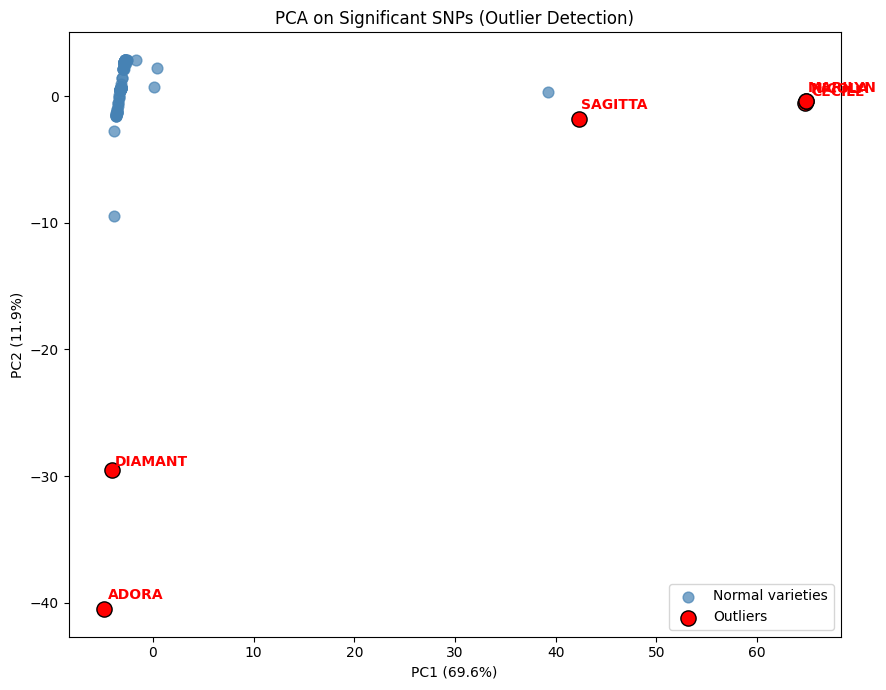


 PCA completed with 2 components.
Explained variance ratio (PC1+PC2): 81.55%
Detected outliers: ['ADORA', 'CECILE', 'DIAMANT', 'MARILYN', 'NICOLA', 'SAGITTA']

 PCA Outlier Detection Summary:
Significant SNPs used: 257
Outlier varieties detected: ['ADORA', 'CECILE', 'DIAMANT', 'MARILYN', 'NICOLA', 'SAGITTA']


In [20]:
# --- Imports ---
import importlib
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f, zscore
from statsmodels.stats.multitest import multipletests
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_gwas_for_sensory_pcs





# =====================================================
#  DEFINE PCA-BASED OUTLIER DETECTION FUNCTION
# =====================================================
def analyze_gwas_snps_pca(
    gwas_path,
    merged_snp_sensory,
    fdr_threshold=0.05,
    top_n_fallback=500,
    outlier_z_pca=(3, 2.5)
):
    """
    Analyze GWAS results: select significant SNPs and perform PCA with outlier detection.

    Parameters
    ----------
    gwas_path : str
        Path to the GWAS results CSV file.
    merged_snp_sensory : pd.DataFrame
        Merged SNP × sensory PCs data.
    fdr_threshold : float
        FDR cutoff for selecting significant SNPs.
    top_n_fallback : int
        If no SNPs meet FDR threshold, take top N SNPs by p-value.
    outlier_z_pca : tuple
        Z-score thresholds for detecting outliers on PC1 and PC2.

    Returns
    -------
    dict
        {
            "significant_snps": list,
            "pca_model": PCA(),
            "pca_outliers": list
        }
    """

    # =====================================================
    # 1. Load GWAS results and extract significant SNPs
    # =====================================================
    gwas_df = pd.read_csv(gwas_path)

    significant_snps = gwas_df[gwas_df["p_fdr"] < fdr_threshold]["SNP"].unique().tolist()
    if len(significant_snps) == 0:
        print(f" No SNPs with FDR < {fdr_threshold}. Using top {top_n_fallback} by p-value.")
        significant_snps = (
            gwas_df.sort_values("p_fdr")
            .head(top_n_fallback)["SNP"]
            .unique()
            .tolist()
        )
    else:
        print(f" Significant SNPs found: {len(significant_snps)}")

    # =====================================================
    # 2. Subset SNP and sensory PC data
    # =====================================================
    snp_cols = [col for col in merged_snp_sensory.columns if col.startswith("GEN__")]
    snp_subset = merged_snp_sensory.loc[:, [s for s in significant_snps if s in snp_cols]].fillna(0).astype(float)

    if snp_subset.empty:
        raise ValueError(" No matching SNPs found in merged_snp_sensory.")

    # =====================================================
    # 3. PCA with Outlier Detection
    # =====================================================
    X_scaled = StandardScaler().fit_transform(snp_subset)
    pca = PCA(n_components=2, random_state=0)
    X_pca = pca.fit_transform(X_scaled)

    Z = np.abs(zscore(X_pca))
    outlier_mask = (Z[:, 0] > outlier_z_pca[0]) | (Z[:, 1] > outlier_z_pca[1])
    normal_mask = ~outlier_mask

    # =====================================================
    # 4. Plot PCA
    # =====================================================
    plt.figure(figsize=(9, 7))
    plt.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
                color="steelblue", alpha=0.7, s=60, label="Normal varieties")
    plt.scatter(X_pca[outlier_mask, 0], X_pca[outlier_mask, 1],
                color="red", s=120, edgecolor="black", label="Outliers")

    np.random.seed(42)
    for i in np.where(outlier_mask)[0]:
        name = snp_subset.index[i]
        dx, dy = np.random.uniform(0.2, 0.8), np.random.uniform(0.2, 0.8)
        plt.text(X_pca[i, 0] + dx, X_pca[i, 1] + dy, name,
                 fontsize=10, color="red", fontweight="bold")

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.title("PCA on Significant SNPs (Outlier Detection)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =====================================================
    # 5. Return results
    # =====================================================
    pca_outliers = snp_subset.index[outlier_mask].tolist()

    print(f"\n PCA completed with 2 components.")
    print(f"Explained variance ratio (PC1+PC2): {pca.explained_variance_ratio_[:2].sum():.2%}")
    print(f"Detected outliers: {pca_outliers}")

    return {
        "significant_snps": significant_snps,
        "pca_model": pca,
        "pca_outliers": pca_outliers
    }


# =====================================================
# 3️  RUN PCA OUTLIER DETECTION
# =====================================================
results_snp_pca = analyze_gwas_snps_pca(
    gwas_path=gwas_output_sensory,
    merged_snp_sensory=merged_snp_sensory,
    fdr_threshold=0.05,
    top_n_fallback=500,
    outlier_z_pca=(3, 2.5)
)

print("\n PCA Outlier Detection Summary:")
print(f"Significant SNPs used: {len(results_snp_pca['significant_snps'])}")
print(f"Outlier varieties detected: {results_snp_pca['pca_outliers']}")


# PCA Outlier Detection on GWAS-Selected SNPs

 Significant SNPs found: 257


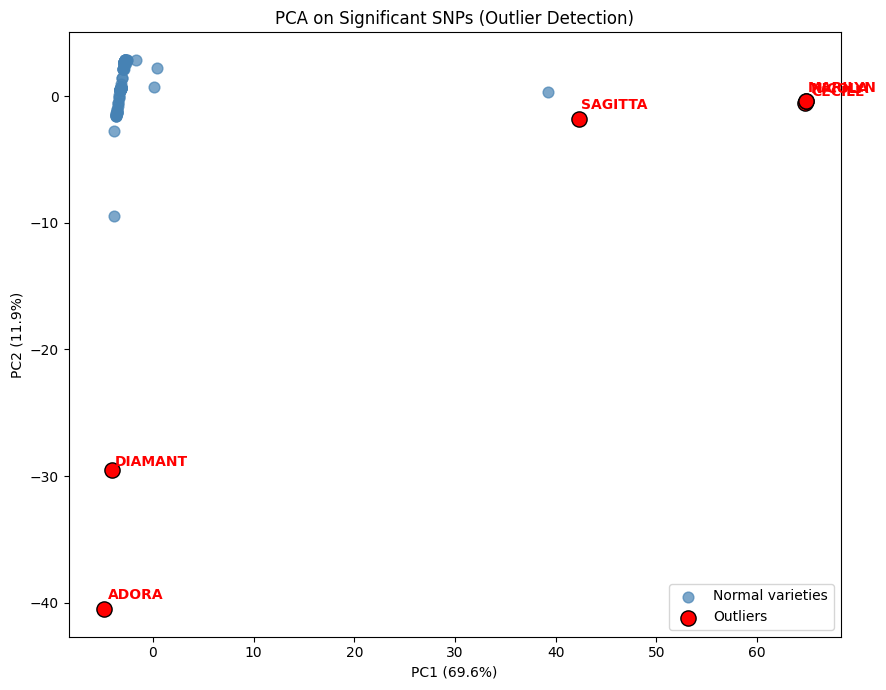


 PCA Outlier Detection Summary:
Significant SNPs used: 257
Outlier varieties detected: ['ADORA', 'CECILE', 'DIAMANT', 'MARILYN', 'NICOLA', 'SAGITTA']


In [21]:

import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import  analyze_gwas_snps_pca


# with open("config_biorep1.yaml", "r") as f:
#     config = yaml.safe_load(f)

# results_pca = analyze_gwas_snps_pca(
#     gwas_path=gwas_output_sensory,
#     merged_snp_sensory=merged_snp_sensory
# )

# print("Detected PCA Outliers:", results_pca["pca_outliers"])




def analyze_gwas_snps_pca(
    gwas_path: gwas_output_sensory,
    merged_snp_sensory: merged_snp_sensory,
    fdr_threshold:  0.05,
    top_n_fallback:500,
    outlier_z_pca=(3, 2.5)
):
    """
    Analyze GWAS results: select significant SNPs and perform PCA with outlier detection.

    Parameters
    ----------
    gwas_path : str
        Path to the GWAS results CSV file.
    merged_snp_sensory : pd.DataFrame
        Merged SNP × sensory PCs data.
    fdr_threshold : float, optional
        Significance threshold for FDR (default: 0.05).
    top_n_fallback : int, optional
        Number of top SNPs to use if no FDR-significant SNPs are found (default: 500).
    outlier_z_pca : tuple, optional
        Z-score thresholds for (PC1, PC2) outlier detection in PCA.

    Returns
    -------
    dict
        Dictionary with PCA and outlier detection results:
        {
            "significant_snps": list,
            "pca_model": PCA(),
            "pca_outliers": list
        }
    """

    # =====================================================
    # 1. Load GWAS results and extract significant SNPs
    # =====================================================
    gwas_df = pd.read_csv(gwas_path)

    significant_snps = gwas_df[gwas_df["p_fdr"] < fdr_threshold]["SNP"].unique().tolist()
    if len(significant_snps) == 0:
        print(f" No SNPs with FDR < {fdr_threshold}. Using top {top_n_fallback} by p-value.")
        significant_snps = (
            gwas_df.sort_values("p_fdr")
            .head(top_n_fallback)["SNP"]
            .unique()
            .tolist()
        )
    else:
        print(f" Significant SNPs found: {len(significant_snps)}")

    # =====================================================
    # 2. Subset SNP and sensory PC data
    # =====================================================
    snp_cols = [col for col in merged_snp_sensory.columns if col.startswith("GEN__")]
    snp_subset = merged_snp_sensory.loc[:, [s for s in significant_snps if s in snp_cols]].fillna(0).astype(float)

    if snp_subset.empty:
        raise ValueError("No matching SNPs found in merged_snp_sensory.")

    # =====================================================
    # 3. PCA with Outlier Detection
    # =====================================================
    X_scaled = StandardScaler().fit_transform(snp_subset)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    Z = np.abs(zscore(X_pca))
    outlier_mask = (Z[:, 0] > outlier_z_pca[0]) | (Z[:, 1] > outlier_z_pca[1])
    normal_mask = ~outlier_mask

    # --- PCA Plot ---
    plt.figure(figsize=(9, 7))
    plt.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
                color="steelblue", alpha=0.7, s=60, label="Normal varieties")
    plt.scatter(X_pca[outlier_mask, 0], X_pca[outlier_mask, 1],
                color="red", s=120, edgecolor="black", label="Outliers")

    np.random.seed(42)
    for i in np.where(outlier_mask)[0]:
        name = snp_subset.index[i]
        dx, dy = np.random.uniform(0.2, 0.8), np.random.uniform(0.2, 0.8)
        plt.text(X_pca[i, 0] + dx, X_pca[i, 1] + dy, name,
                 fontsize=10, color="red", fontweight="bold")

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.title("PCA on Significant SNPs (Outlier Detection)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =====================================================
    # 4. Return Results
    # =====================================================
    pca_outliers = snp_subset.index[outlier_mask].tolist()

    return {
        "significant_snps": significant_snps,
        "pca_model": pca,
        "pca_outliers": pca_outliers
    }

# --- Run PCA-based outlier detection on GWAS SNPs ---
from scipy.stats import zscore

results_snp_pca = analyze_gwas_snps_pca(
    gwas_path=gwas_output_sensory,  # path to your GWAS results file
    merged_snp_sensory=merged_snp_sensory,  
    fdr_threshold=0.05,
    top_n_fallback=500,
    outlier_z_pca=(3, 2.5)  # z-thresholds for PC1 and PC2
)

# --- Print results ---
print("\n PCA Outlier Detection Summary:")
print(f"Significant SNPs used: {len(results_snp_pca['significant_snps'])}")
print(f"Outlier varieties detected: {results_snp_pca['pca_outliers']}")


# Sensory Profile Comparison of Outlier Varieties

 Reconstructed sensory traits using 3 PCs:


,METALLIC FLAVOUR,BITTER FLAVOUR,EARTHY FLAVOUR,SOUR FLAVOUR,FRESH FLAVOUR,SWEET FLAVOUR,ROOT/ VEGETABLE FLAVOUR,FARMYARD (GRASS/HAY) FLAVOUR,BITTER AFTERTASTE,SOUR AFTERTASTE,SWEET AFTERTASTE,EARTHY AROMA,FARMYARD,SWEET,STARCHY,DAMP,BUTTERY,FRESH,POTATO STARCH,METALIC
Variety,,,,,,,,,,,,,,,,,,,,
ADORA,2.777227,3.021468,2.221376,2.850300,-1.066084,-0.847148,2.373826,2.495142,2.784747,3.016634,-1.006645,0.899148,1.878034,-0.157331,0.828773,1.786741,-0.069789,-0.149353,-0.225817,2.325663
AGRIA,-0.229637,-0.448615,0.509891,-0.827166,-0.731611,-1.171877,0.083648,0.310391,-0.388611,-1.042706,-1.130200,1.387898,-0.340720,-0.651435,1.694207,-0.093582,-0.849283,-1.680008,2.088016,0.320938
BERBER,-0.354242,-0.459819,0.098332,-0.640353,0.861787,0.459095,0.873152,0.428063,-0.596838,-0.754492,0.370748,-0.125063,-0.278329,1.418112,1.733750,-1.048533,1.192578,-0.023029,1.404938,-0.173067
BILDTSTAR,-0.143122,-0.293976,0.317844,-0.535582,-0.939388,-1.155316,-0.367521,0.003764,-0.178766,-0.677375,-1.078262,1.199855,-0.238350,-1.130382,0.698996,0.290940,-1.208747,-1.412395,1.204038,0.265307
BINTJE,-0.896907,-1.004481,-0.571348,-1.026723,0.614686,0.401464,-0.323025,-0.523106,-0.990835,-1.116110,0.412158,-0.289270,-0.621746,0.574778,0.430797,-0.885742,0.465161,0.026589,0.598025,-0.702797


 Saved reconstructed sensory traits → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\reconstructed_sensory.csv
Detected PCA outliers for radar plot: ['ADORA', 'CECILE', 'DIAMANT', 'MARILYN', 'NICOLA', 'SAGITTA']


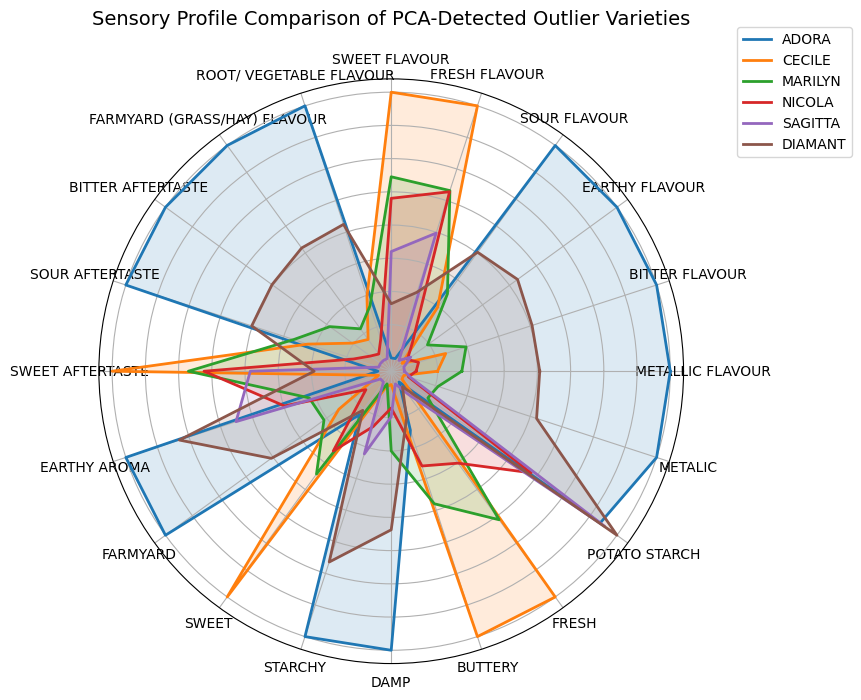

In [22]:

import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import reconstruct_sensory_traits_from_pca, plot_sensory_profiles_of_pca_outliers


sensory_reconstructed_df = reconstruct_sensory_traits_from_pca(
    projection_path=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\biorep1\results\sensory_pca_projection_knn.csv",
    loadings_path=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\biorep1\results\sensory_pca_loadings.csv",
    save_path=r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\reconstructed_sensory.csv',  
    n_components=3
)


plot_sensory_profiles_of_pca_outliers(results_snp_pca, sensory_reconstructed_df)

# Manhattan-Like Visualization of Sensory GWAS Results

Columns: ['SNP', 'p_value', 'p_fdr', 'Trait']


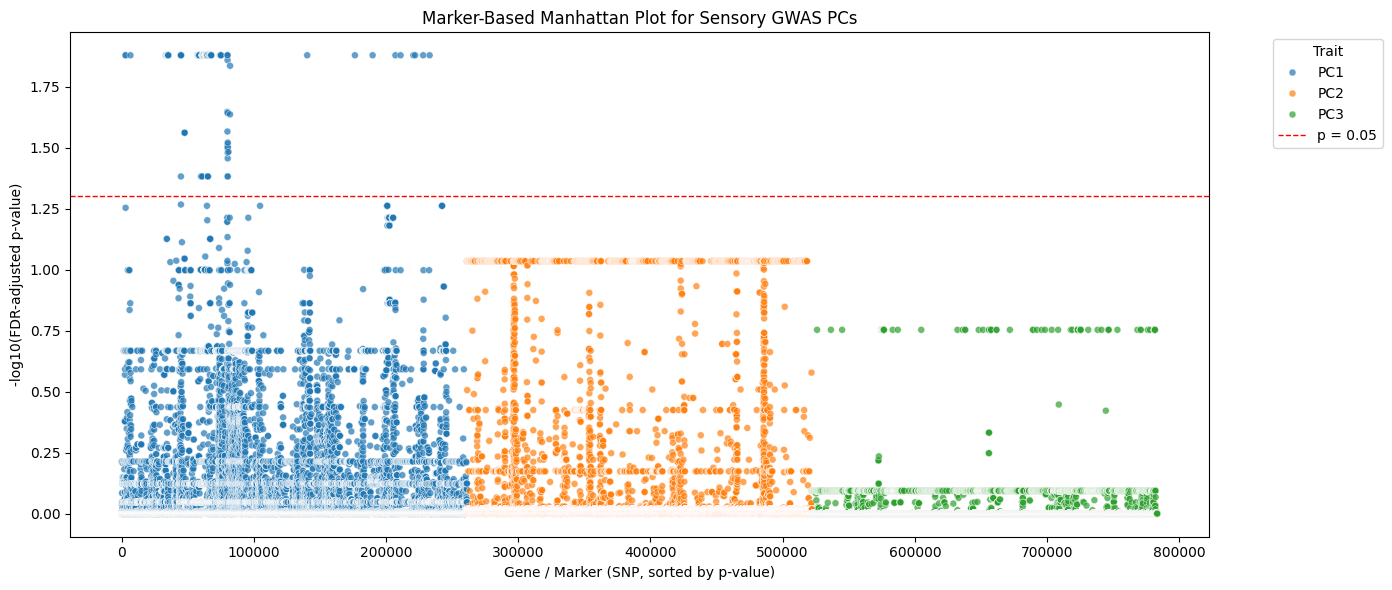

Min raw p-value: 7.201174411823227e-07
Min FDR-adjusted p-value: 0.0131922442523718
Trait
PC1    261110
PC2    261110
PC3    261110
Name: count, dtype: int64
257 SNPs are FDR-significant


In [23]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_manhattan_like_gwas

all_gwas_sensory = pd.read_csv(gwas_output_sensory)

# Check columns
print("Columns:", all_gwas_sensory.columns.tolist())

# --- Manhattan-like plot without chromosome info ---
plt.figure(figsize=(14, 6))
sns.scatterplot(
    data=all_gwas_sensory.sort_values("p_fdr"),
    x=range(len(all_gwas_sensory)),
    y=-np.log10(all_gwas_sensory["p_fdr"]),
    hue="Trait",
    palette="tab10",
    s=25,
    alpha=0.7
)

# Significance threshold line (p = 0.05)
plt.axhline(-np.log10(0.05), color="red", linestyle="--", linewidth=1, label="p = 0.05")

# Titles and labels
plt.title("Marker-Based Manhattan Plot for Sensory GWAS PCs")
plt.xlabel("Gene / Marker (SNP, sorted by p-value)")
plt.ylabel("-log10(FDR-adjusted p-value)")
plt.legend(title="Trait", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Summary stats
print("Min raw p-value:", all_gwas_sensory["p_value"].min())
print("Min FDR-adjusted p-value:", all_gwas_sensory["p_fdr"].min())
print(all_gwas_sensory["Trait"].value_counts())
print((all_gwas_sensory["p_fdr"] < 0.05).sum(), "SNPs are FDR-significant")


# Volcano Plot Visualization of GWAS Results for Sensory Principal Components

 'effect_size' column not found — generated random values for visualization.


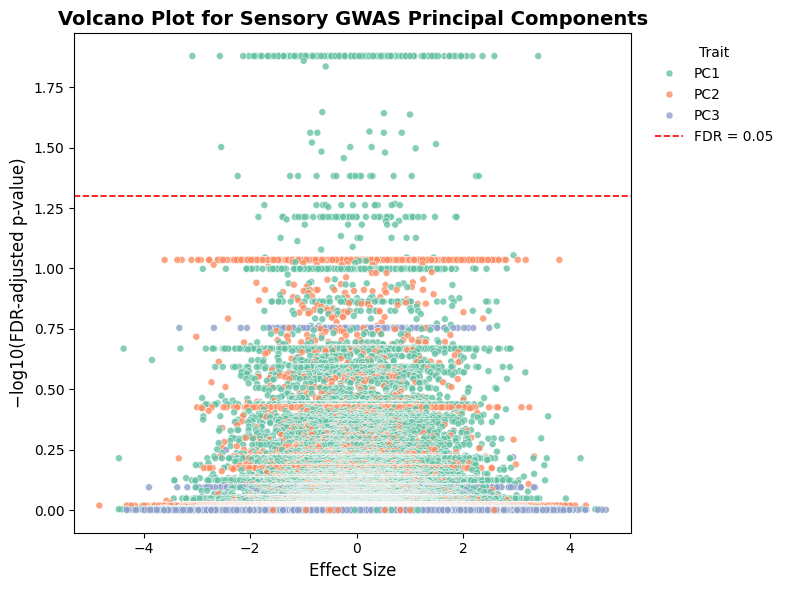

In [24]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_gwas_volcano

# --- Import and call the function ---
plot_gwas_volcano(
     "C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep1/gwas_sensory_PCs.csv",
    fdr_threshold=0.05
)



# QQ Plot for GWAS p-Value Distribution (Sensory Principal Components)

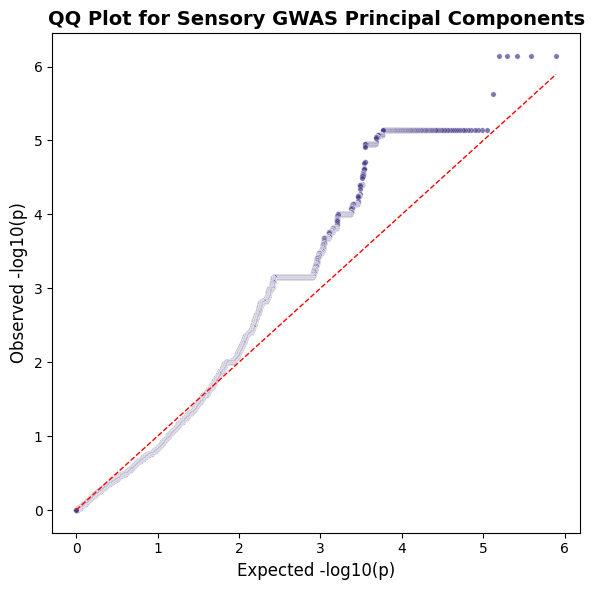

In [25]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import plot_gwas_qq
import pandas as pd
all_gwas_df_sensory= pd.read_csv('C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep1/gwas_sensory_PCs.csv')
plot_gwas_qq(all_gwas_df_sensory, pval_col="p_value")


# Comparison of Linear and Regularized Regression Models for GWAS Trait Prediction


[Linear Models — full] Trait: 1-Heptanol

[Linear Models — full] Trait: 1-Nonanol

[Linear Models — full] Trait: 1-Octen-3-ol

[Linear Models — full] Trait: 1-Phenylethanol

[Linear Models — full] Trait: 2,3-Pentanedione

[Linear Models — full] Trait: 2,4-Decadienal

[Linear Models — full] Trait: 2,6-Dimethylpyrazine

[Linear Models — full] Trait: 2-Isopropyl-3-methoxypyrazine

[Linear Models — full] Trait: 2-Methyl-1-propanol

[Linear Models — full] Trait: 2-Methylthiazole

[Linear Models — full] Trait: 2-Nonanone

[Linear Models — full] Trait: 2-Propanone, 1-methoxy-

[Linear Models — full] Trait: 3-Heptanone

[Linear Models — full] Trait: 3-Octanone

[Linear Models — full] Trait: Acetic acid

[Linear Models — full] Trait: Acetophenone

[Linear Models — full] Trait: Benzaldehyde

[Linear Models — full] Trait: Benzeneacetaldehyde

[Linear Models — full] Trait: Benzyl alcohol

[Linear Models — full] Trait: Butanal, 3-methyl-

[Linear Models — full] Trait: Butanoic acid

[Linear Models

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2085: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\linear_plot_full.png


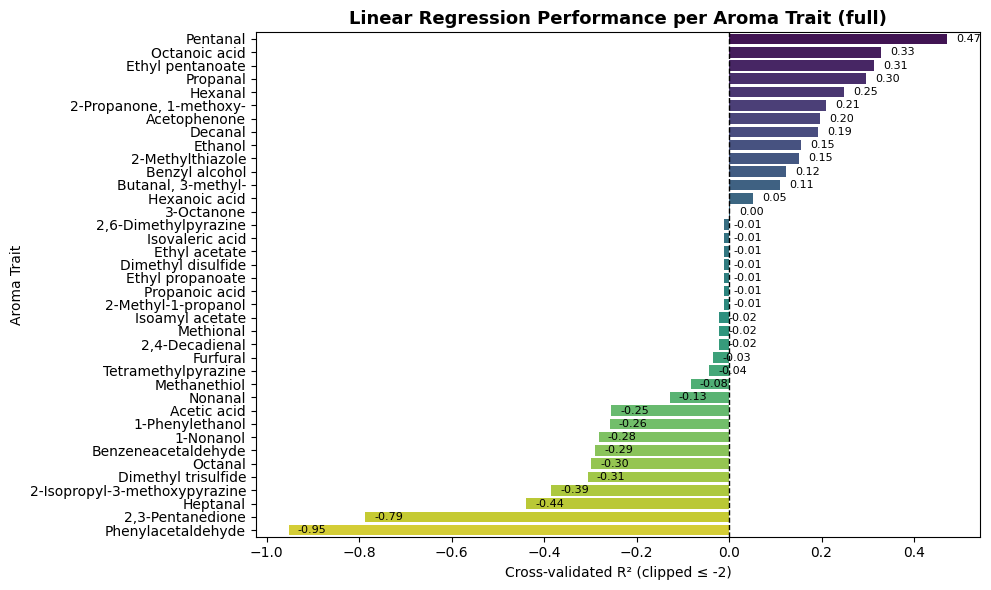

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2085: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\ridge_plot_full.png


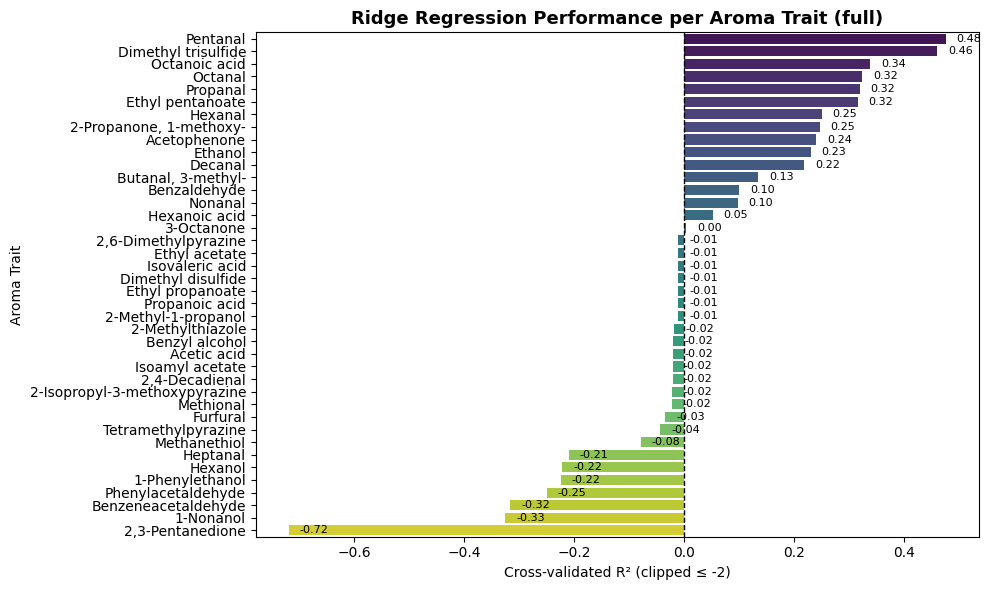

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2085: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\lasso_plot_full.png


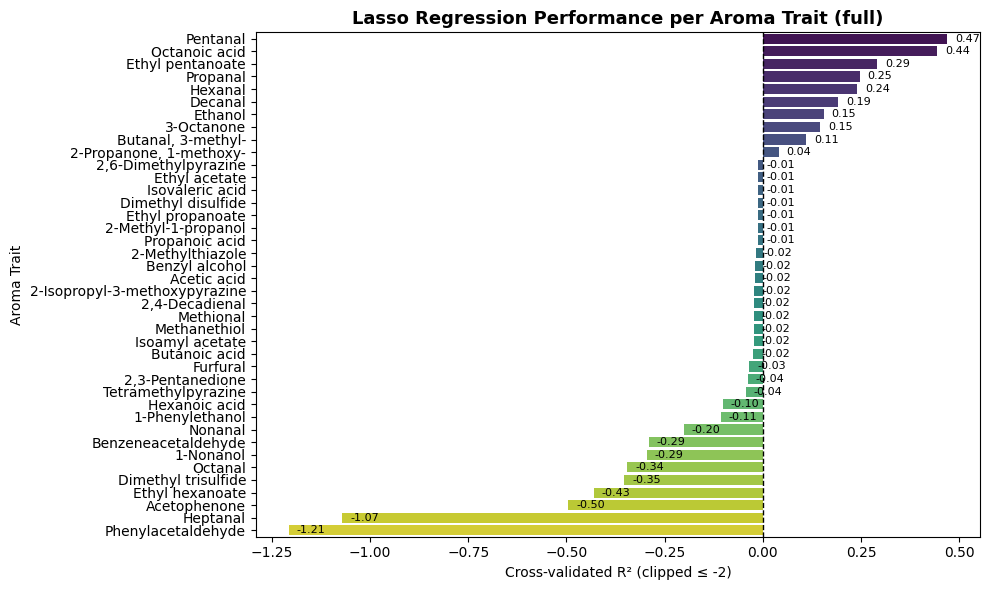

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2085: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\elasticnet_plot_full.png


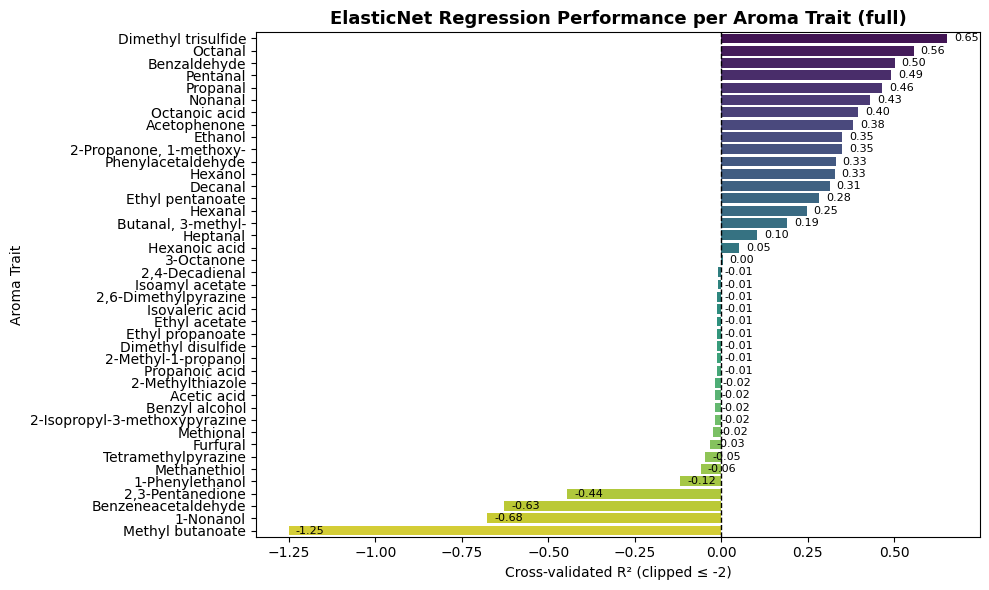

,Trait,Model,n_SNPs,CV_Best_R2,R2,MSE,MAE
0,1-Heptanol,Linear,1,-3.011470,0.533621,5.226723e+10,5.887280e+04
1,1-Heptanol,Ridge,1,-2.382221,0.533561,5.227386e+10,5.938394e+04
2,1-Heptanol,Lasso,1,-2.338414,0.533621,5.226723e+10,5.887286e+04
3,1-Heptanol,ElasticNet,1,-2.802362,0.524542,5.328468e+10,6.520653e+04
4,1-Nonanol,Linear,2,-0.282092,0.950251,1.103902e+10,2.555684e+04
...,...,...,...,...,...,...,...
183,Propanoic acid,ElasticNet,1,-0.011111,0.982985,1.176612e+07,7.038178e+02
184,Tetramethylpyrazine,Linear,1,-0.043041,0.628529,1.878566e+12,1.042620e+06
185,Tetramethylpyrazine,Ridge,1,-0.043360,0.628459,1.878918e+12,1.045312e+06
186,Tetramethylpyrazine,Lasso,1,-0.043041,0.628529,1.878566e+12,1.042620e+06


In [26]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_linear_models_gene_aroma


run_linear_models_gene_aroma(
    gwas_file= r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
    snp_df=merged_snp_aroma,
    top_n_snps=500,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1",
    tag="full"
)



# Linear model after outlier removal

Detected 2 outliers (Z > 3): ['ARGOS', 'NADINE']
Remaining samples after outlier removal: 92
Remaining samples after outlier removal: 92

[Linear Models — outlier removed] Trait: 1-Heptanol

[Linear Models — outlier removed] Trait: 1-Nonanol

[Linear Models — outlier removed] Trait: 1-Octen-3-ol

[Linear Models — outlier removed] Trait: 1-Phenylethanol

[Linear Models — outlier removed] Trait: 2,3-Pentanedione

[Linear Models — outlier removed] Trait: 2,4-Decadienal

[Linear Models — outlier removed] Trait: 2,6-Dimethylpyrazine

[Linear Models — outlier removed] Trait: 2-Isopropyl-3-methoxypyrazine

[Linear Models — outlier removed] Trait: 2-Methyl-1-propanol

[Linear Models — outlier removed] Trait: 2-Methylthiazole

[Linear Models — outlier removed] Trait: 2-Nonanone

[Linear Models — outlier removed] Trait: 2-Propanone, 1-methoxy-

[Linear Models — outlier removed] Trait: 3-Heptanone

[Linear Models — outlier removed] Trait: 3-Octanone

[Linear Models — outlier removed] Trait: Aceti

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2085: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\linear_plot_outlier_removed.png


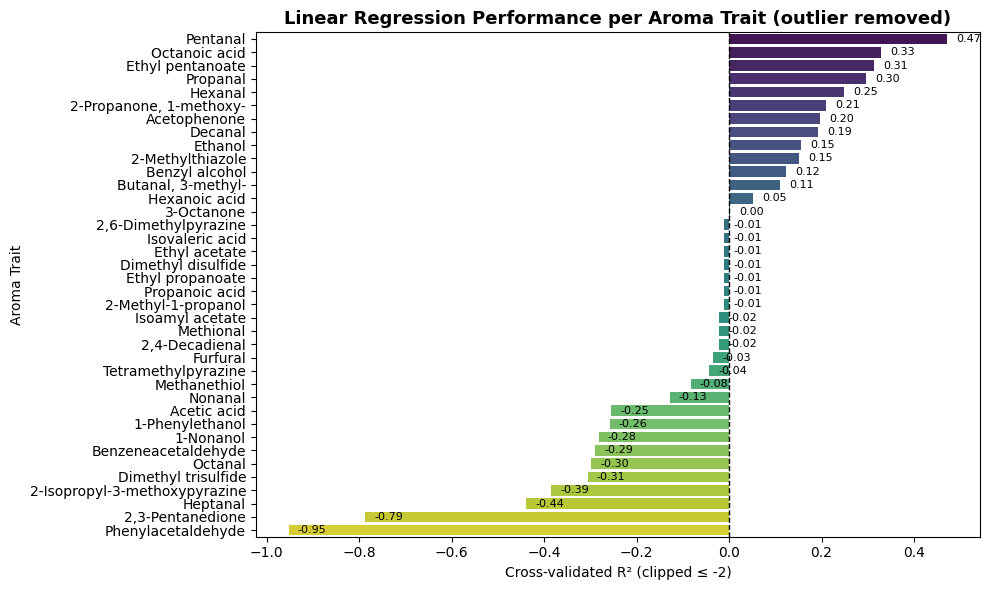

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2085: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\ridge_plot_outlier_removed.png


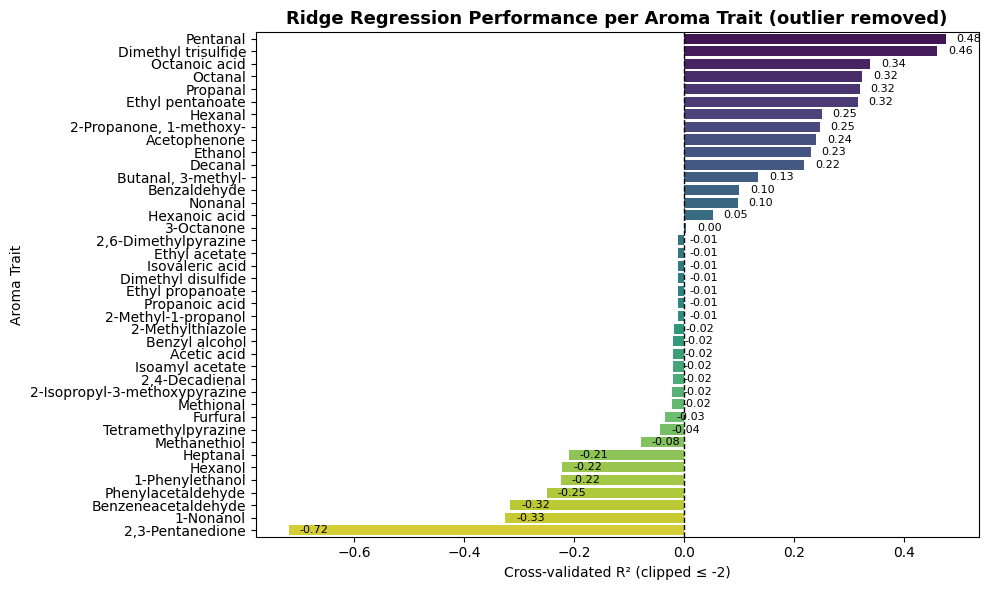

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2085: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\lasso_plot_outlier_removed.png


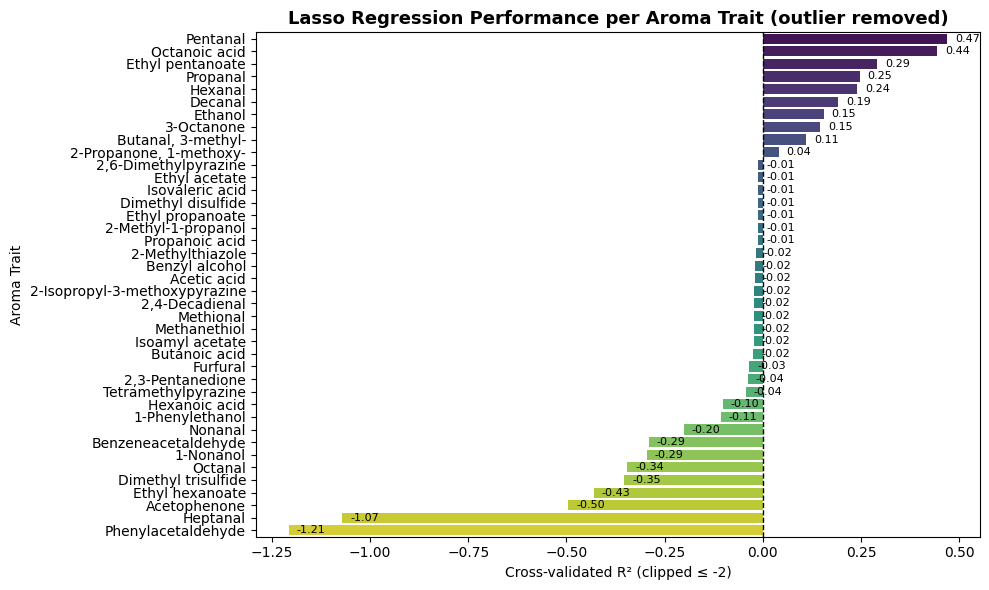

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2085: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\elasticnet_plot_outlier_removed.png


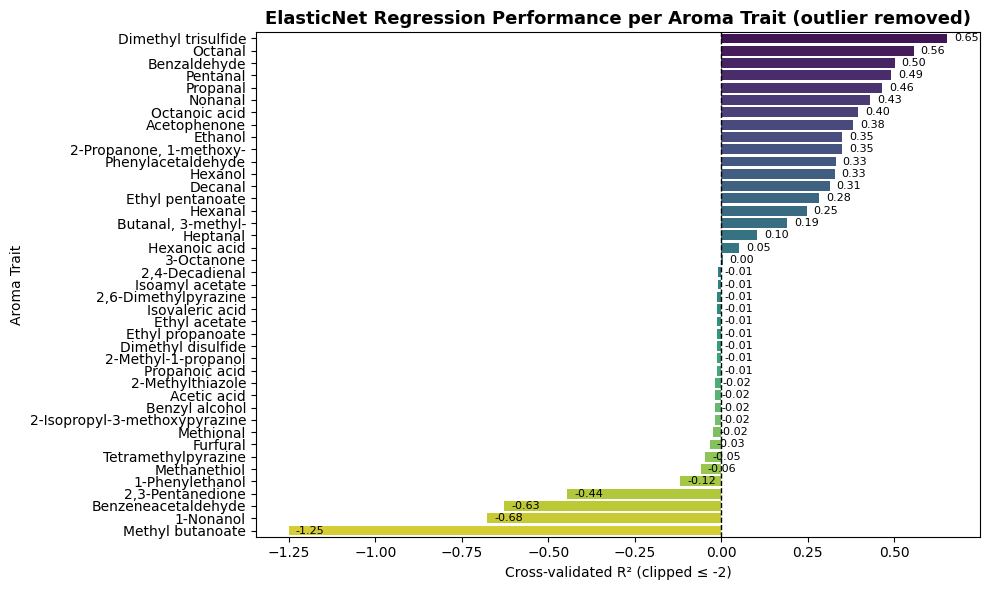

,Trait,Model,n_SNPs,CV_Best_R2,R2,MSE,MAE
0,1-Heptanol,Linear,1,-3.011470,0.533621,5.226723e+10,5.887280e+04
1,1-Heptanol,Ridge,1,-2.382221,0.533561,5.227386e+10,5.938394e+04
2,1-Heptanol,Lasso,1,-2.338414,0.533621,5.226723e+10,5.887286e+04
3,1-Heptanol,ElasticNet,1,-2.802362,0.524542,5.328468e+10,6.520653e+04
4,1-Nonanol,Linear,2,-0.282092,0.950251,1.103902e+10,2.555684e+04
...,...,...,...,...,...,...,...
183,Propanoic acid,ElasticNet,1,-0.011111,0.982985,1.176612e+07,7.038178e+02
184,Tetramethylpyrazine,Linear,1,-0.043041,0.628529,1.878566e+12,1.042620e+06
185,Tetramethylpyrazine,Ridge,1,-0.043360,0.628459,1.878918e+12,1.045312e+06
186,Tetramethylpyrazine,Lasso,1,-0.043041,0.628529,1.878566e+12,1.042620e+06


In [27]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import detect_outliers_aroma_genefrom_plsr , run_linear_models_gene_aroma

# Detect outliers
outlier_samples = detect_outliers_aroma_genefrom_plsr(
    X_scores, Y_scores, merged_snp_aroma.index, z_threshold=3
)

cleaned_data_gene_aroma = merged_snp_aroma.drop(index=outlier_samples)
print(f"Remaining samples after outlier removal: {len(cleaned_data_gene_aroma)}")


# Remove them
cleaned_data_gene_aroma = merged_snp_aroma.drop(index=outlier_samples)
print(f"Remaining samples after outlier removal: {len(cleaned_data_gene_aroma)}")



run_linear_models_gene_aroma(
    gwas_file= r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
    top_n_snps=500,
    snp_df=merged_snp_aroma,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1",
    tag="outlier removed"
)




# Nonlinear Modeling of GWAS-Selected SNPs for Aroma Trait Prediction


[Nonlinear Models — full] Trait: 1-Heptanol

[Nonlinear Models — full] Trait: 1-Nonanol

[Nonlinear Models — full] Trait: 1-Octen-3-ol

[Nonlinear Models — full] Trait: 1-Phenylethanol

[Nonlinear Models — full] Trait: 2,3-Pentanedione

[Nonlinear Models — full] Trait: 2,4-Decadienal

[Nonlinear Models — full] Trait: 2,6-Dimethylpyrazine

[Nonlinear Models — full] Trait: 2-Isopropyl-3-methoxypyrazine

[Nonlinear Models — full] Trait: 2-Methyl-1-propanol

[Nonlinear Models — full] Trait: 2-Methylthiazole

[Nonlinear Models — full] Trait: 2-Nonanone

[Nonlinear Models — full] Trait: 2-Propanone, 1-methoxy-

[Nonlinear Models — full] Trait: 3-Heptanone

[Nonlinear Models — full] Trait: 3-Octanone

[Nonlinear Models — full] Trait: Acetic acid

[Nonlinear Models — full] Trait: Acetophenone

[Nonlinear Models — full] Trait: Benzaldehyde

[Nonlinear Models — full] Trait: Benzeneacetaldehyde

[Nonlinear Models — full] Trait: Benzyl alcohol

[Nonlinear Models — full] Trait: Butanal, 3-methyl-


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\svr_plot_full.png


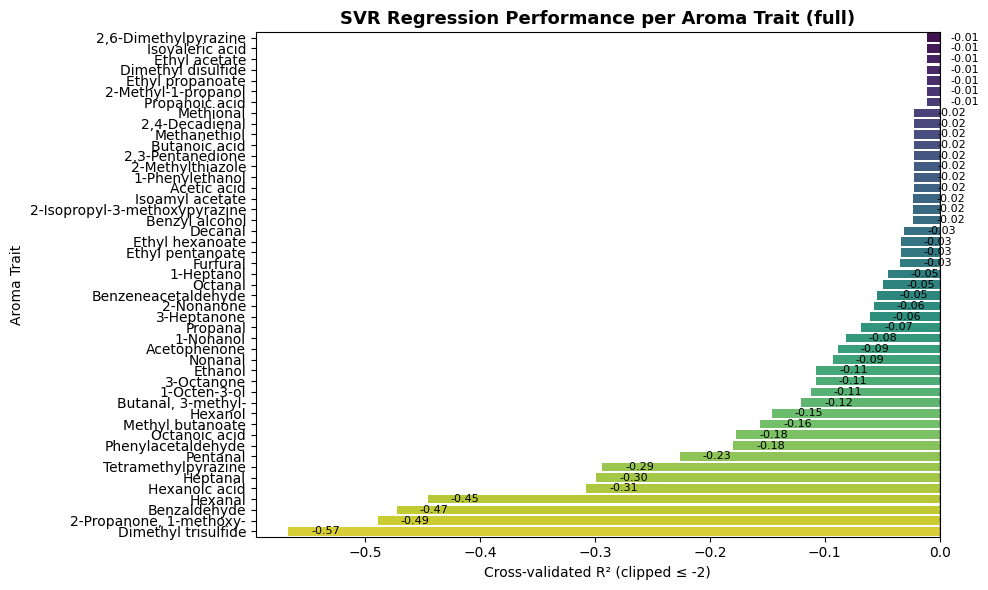

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\randomforest_plot_full.png


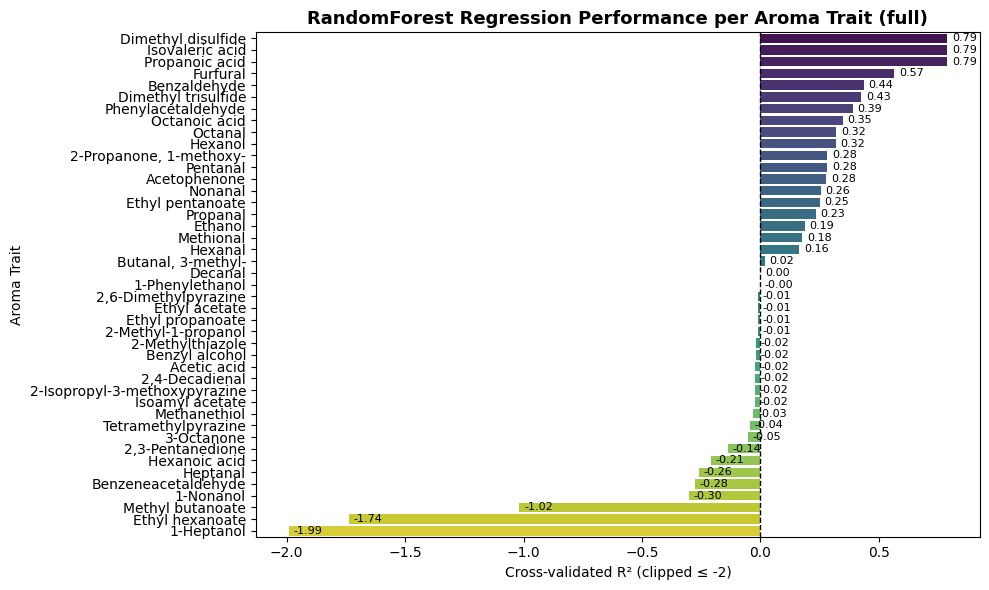

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\xgboost_plot_full.png


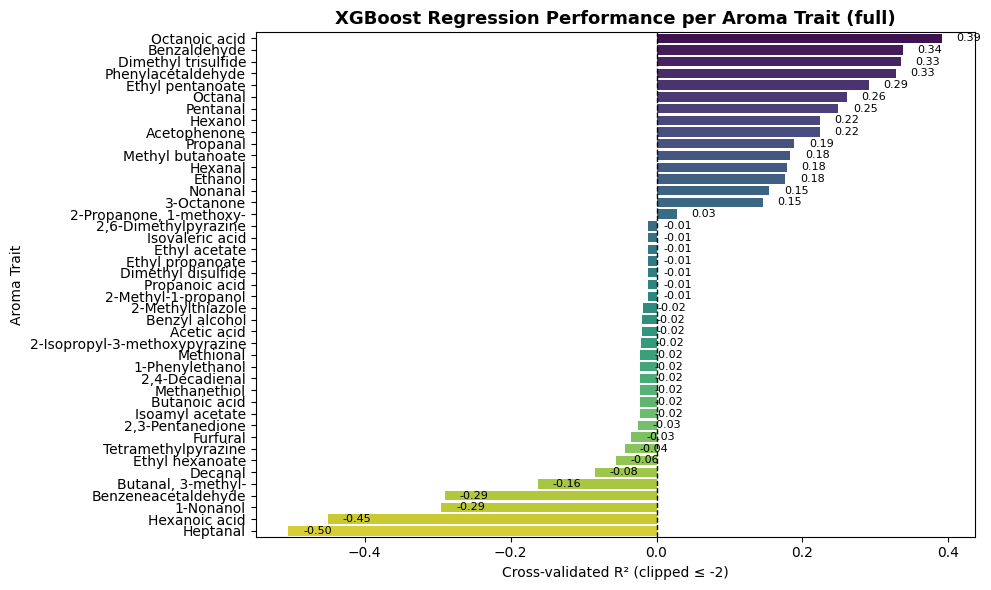

In [28]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_nonlinear_models_gene_aroma


results_nonlinear_outlier_removed = run_nonlinear_models_gene_aroma(
    gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
    snp_df=merged_snp_aroma,
    top_n_snps=500,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1",
    tag="full"
)


# Nonlinear Modeling After Outlier Removal


[Nonlinear Models — outlier removed] Trait: 1-Heptanol

[Nonlinear Models — outlier removed] Trait: 1-Nonanol

[Nonlinear Models — outlier removed] Trait: 1-Octen-3-ol

[Nonlinear Models — outlier removed] Trait: 1-Phenylethanol

[Nonlinear Models — outlier removed] Trait: 2,3-Pentanedione

[Nonlinear Models — outlier removed] Trait: 2,4-Decadienal

[Nonlinear Models — outlier removed] Trait: 2,6-Dimethylpyrazine

[Nonlinear Models — outlier removed] Trait: 2-Isopropyl-3-methoxypyrazine

[Nonlinear Models — outlier removed] Trait: 2-Methyl-1-propanol

[Nonlinear Models — outlier removed] Trait: 2-Methylthiazole

[Nonlinear Models — outlier removed] Trait: 2-Nonanone

[Nonlinear Models — outlier removed] Trait: 2-Propanone, 1-methoxy-

[Nonlinear Models — outlier removed] Trait: 3-Heptanone

[Nonlinear Models — outlier removed] Trait: 3-Octanone

[Nonlinear Models — outlier removed] Trait: Acetic acid

[Nonlinear Models — outlier removed] Trait: Acetophenone


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[Nonlinear Models — outlier removed] Trait: Benzaldehyde

[Nonlinear Models — outlier removed] Trait: Benzeneacetaldehyde

[Nonlinear Models — outlier removed] Trait: Benzyl alcohol

[Nonlinear Models — outlier removed] Trait: Butanal, 3-methyl-

[Nonlinear Models — outlier removed] Trait: Butanoic acid

[Nonlinear Models — outlier removed] Trait: Decanal

[Nonlinear Models — outlier removed] Trait: Dimethyl disulfide

[Nonlinear Models — outlier removed] Trait: Dimethyl trisulfide

[Nonlinear Models — outlier removed] Trait: Ethanol

[Nonlinear Models — outlier removed] Trait: Ethyl acetate

[Nonlinear Models — outlier removed] Trait: Ethyl hexanoate

[Nonlinear Models — outlier removed] Trait: Ethyl pentanoate

[Nonlinear Models — outlier removed] Trait: Ethyl propanoate

[Nonlinear Models — outlier removed] Trait: Furfural

[Nonlinear Models — outlier removed] Trait: Heptanal

[Nonlinear Models — outlier removed] Trait: Hexanal

[Nonlinear Models — outlier removed] Trait: Hexanoic 

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\svr_plot_outlier_removed.png


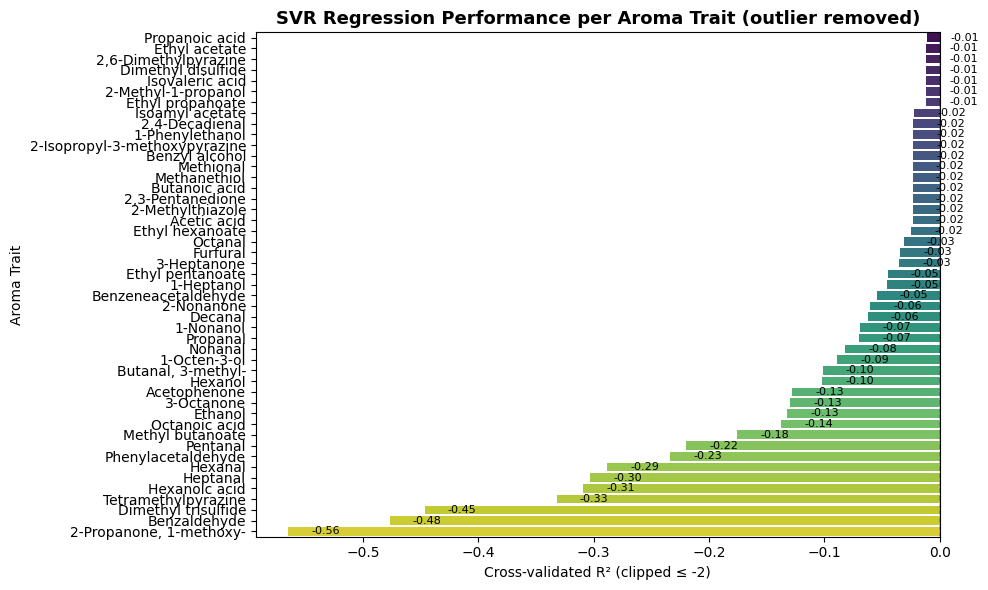

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\randomforest_plot_outlier_removed.png


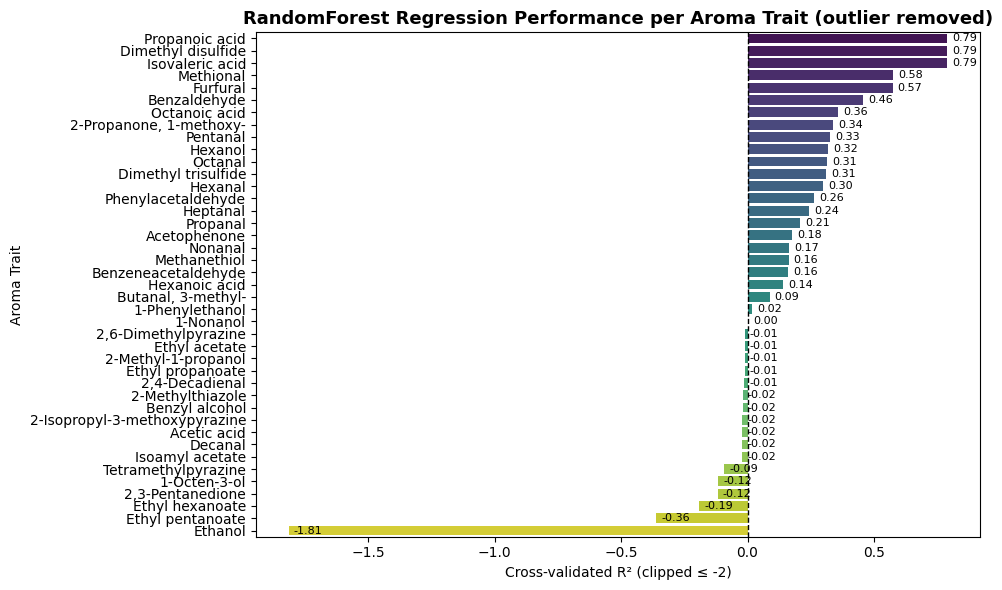

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_df, y="Trait", x="CV_Best_R2_clipped", palette="viridis")


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\xgboost_plot_outlier_removed.png


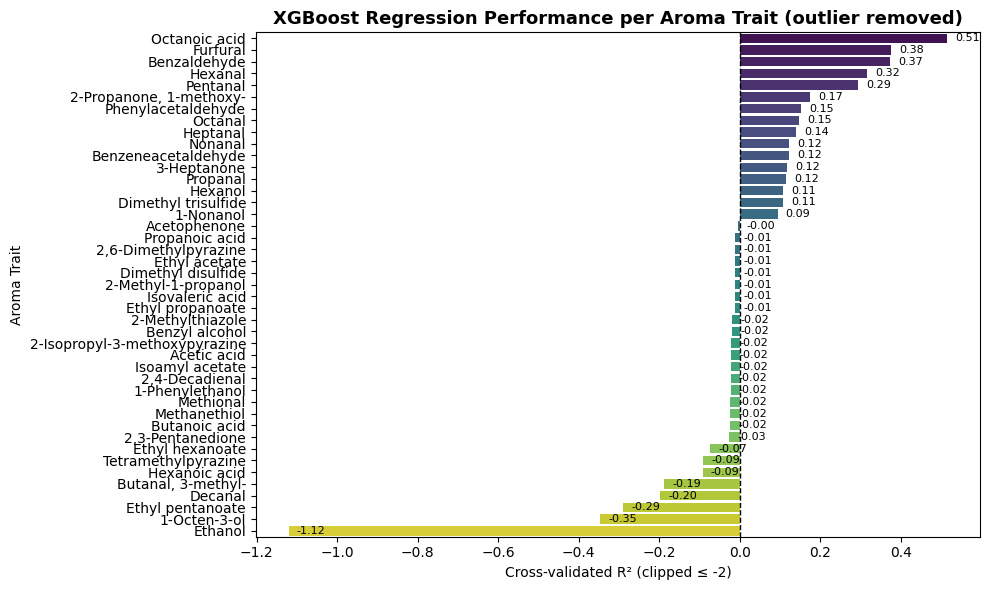

In [29]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_nonlinear_models_gene_aroma



results_nonlinear_outlier_removed = run_nonlinear_models_gene_aroma(
    gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
    snp_df=cleaned_data_gene_aroma,
    top_n_snps=500,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1",
    tag="outlier removed"
)

# Cross-Validated Kernel Ridge Regression Framework for GWAS Trait Modeling”


 Running KRR with top_n_snps = 100

[KRR — top100] Trait: 1-Heptanol

[KRR — top100] Trait: 1-Nonanol

[KRR — top100] Trait: 1-Octen-3-ol

[KRR — top100] Trait: 1-Phenylethanol

[KRR — top100] Trait: 2,3-Pentanedione

[KRR — top100] Trait: 2,4-Decadienal

[KRR — top100] Trait: 2,6-Dimethylpyrazine

[KRR — top100] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — top100] Trait: 2-Methyl-1-propanol

[KRR — top100] Trait: 2-Methylthiazole

[KRR — top100] Trait: 2-Nonanone

[KRR — top100] Trait: 2-Propanone, 1-methoxy-

[KRR — top100] Trait: 3-Heptanone

[KRR — top100] Trait: 3-Octanone

[KRR — top100] Trait: Acetic acid

[KRR — top100] Trait: Acetophenone

[KRR — top100] Trait: Benzaldehyde

[KRR — top100] Trait: Benzeneacetaldehyde

[KRR — top100] Trait: Benzyl alcohol

[KRR — top100] Trait: Butanal, 3-methyl-

[KRR — top100] Trait: Butanoic acid

[KRR — top100] Trait: Decanal

[KRR — top100] Trait: Dimethyl disulfide

[KRR — top100] Trait: Dimethyl trisulfide

[KRR — top100] Trait: Ethanol


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_plot_top100.png


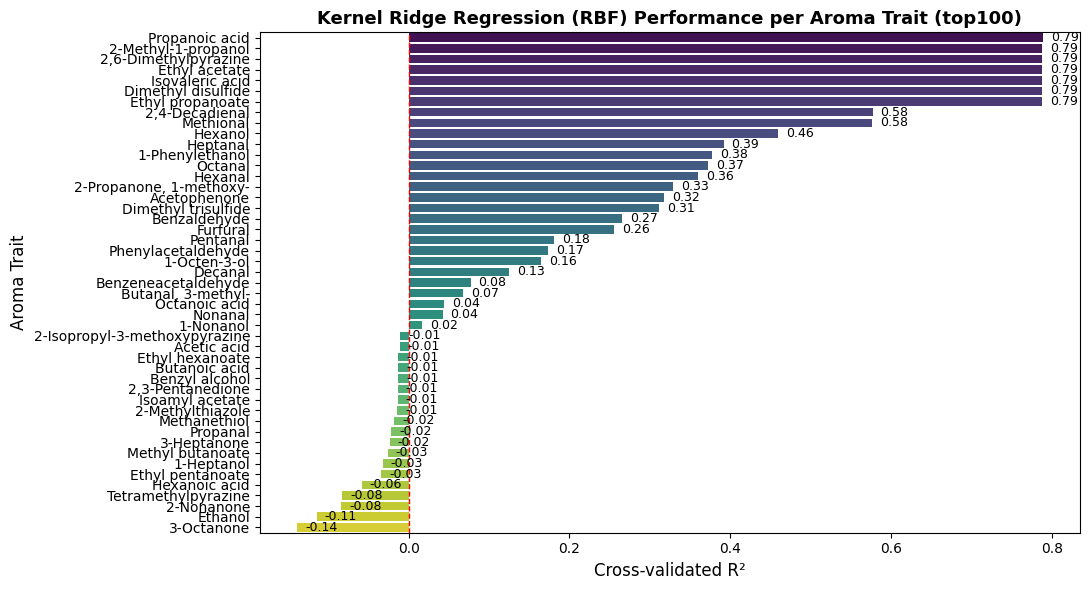

→ Mean CV R² for top_n_snps = 100: 0.2185

 Running KRR with top_n_snps = 200

[KRR — top200] Trait: 1-Heptanol

[KRR — top200] Trait: 1-Nonanol

[KRR — top200] Trait: 1-Octen-3-ol

[KRR — top200] Trait: 1-Phenylethanol

[KRR — top200] Trait: 2,3-Pentanedione

[KRR — top200] Trait: 2,4-Decadienal

[KRR — top200] Trait: 2,6-Dimethylpyrazine

[KRR — top200] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — top200] Trait: 2-Methyl-1-propanol

[KRR — top200] Trait: 2-Methylthiazole

[KRR — top200] Trait: 2-Nonanone

[KRR — top200] Trait: 2-Propanone, 1-methoxy-

[KRR — top200] Trait: 3-Heptanone

[KRR — top200] Trait: 3-Octanone

[KRR — top200] Trait: Acetic acid

[KRR — top200] Trait: Acetophenone

[KRR — top200] Trait: Benzaldehyde

[KRR — top200] Trait: Benzeneacetaldehyde

[KRR — top200] Trait: Benzyl alcohol

[KRR — top200] Trait: Butanal, 3-methyl-

[KRR — top200] Trait: Butanoic acid

[KRR — top200] Trait: Decanal

[KRR — top200] Trait: Dimethyl disulfide

[KRR — top200] Trait: Dimethyl 

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_plot_top200.png


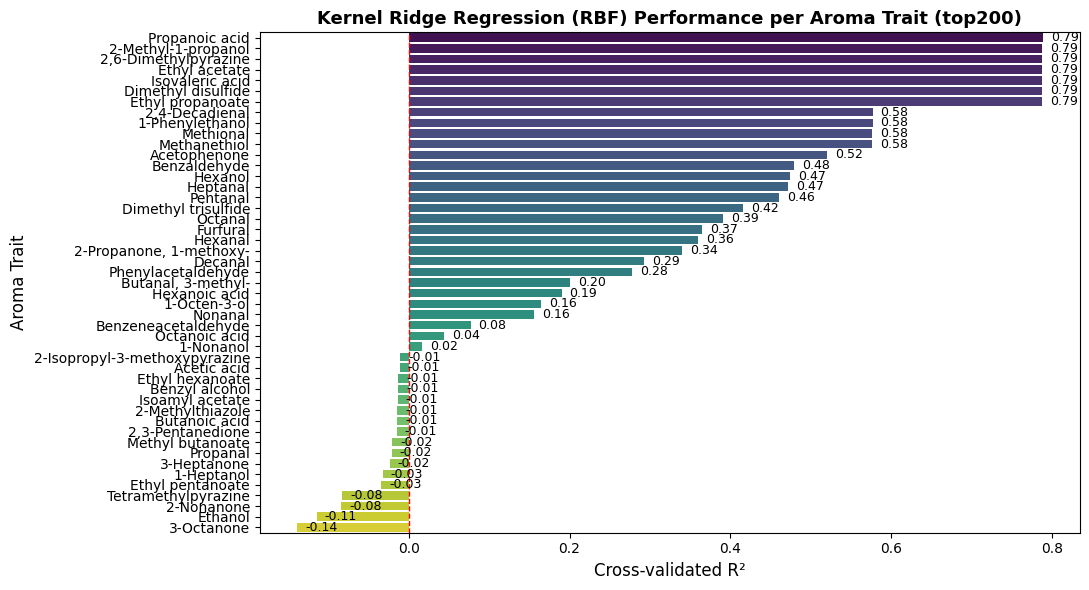

→ Mean CV R² for top_n_snps = 200: 0.2738

 Running KRR with top_n_snps = 500

[KRR — top500] Trait: 1-Heptanol

[KRR — top500] Trait: 1-Nonanol

[KRR — top500] Trait: 1-Octen-3-ol

[KRR — top500] Trait: 1-Phenylethanol

[KRR — top500] Trait: 2,3-Pentanedione

[KRR — top500] Trait: 2,4-Decadienal

[KRR — top500] Trait: 2,6-Dimethylpyrazine

[KRR — top500] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — top500] Trait: 2-Methyl-1-propanol

[KRR — top500] Trait: 2-Methylthiazole

[KRR — top500] Trait: 2-Nonanone

[KRR — top500] Trait: 2-Propanone, 1-methoxy-

[KRR — top500] Trait: 3-Heptanone

[KRR — top500] Trait: 3-Octanone

[KRR — top500] Trait: Acetic acid

[KRR — top500] Trait: Acetophenone


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top500] Trait: Benzaldehyde

[KRR — top500] Trait: Benzeneacetaldehyde

[KRR — top500] Trait: Benzyl alcohol

[KRR — top500] Trait: Butanal, 3-methyl-

[KRR — top500] Trait: Butanoic acid

[KRR — top500] Trait: Decanal

[KRR — top500] Trait: Dimethyl disulfide

[KRR — top500] Trait: Dimethyl trisulfide

[KRR — top500] Trait: Ethanol

[KRR — top500] Trait: Ethyl acetate

[KRR — top500] Trait: Ethyl hexanoate

[KRR — top500] Trait: Ethyl pentanoate

[KRR — top500] Trait: Ethyl propanoate

[KRR — top500] Trait: Furfural

[KRR — top500] Trait: Heptanal

[KRR — top500] Trait: Hexanal

[KRR — top500] Trait: Hexanoic acid

[KRR — top500] Trait: Hexanol

[KRR — top500] Trait: Isoamyl acetate

[KRR — top500] Trait: Isovaleric acid

[KRR — top500] Trait: Methanethiol

[KRR — top500] Trait: Methional

[KRR — top500] Trait: Methyl butanoate

[KRR — top500] Trait: Nonanal

[KRR — top500] Trait: Octanal

[KRR — top500] Trait: Octanoic acid

[KRR — top500] Trait: Pentanal

[KRR — top500] Trai

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_plot_top500.png


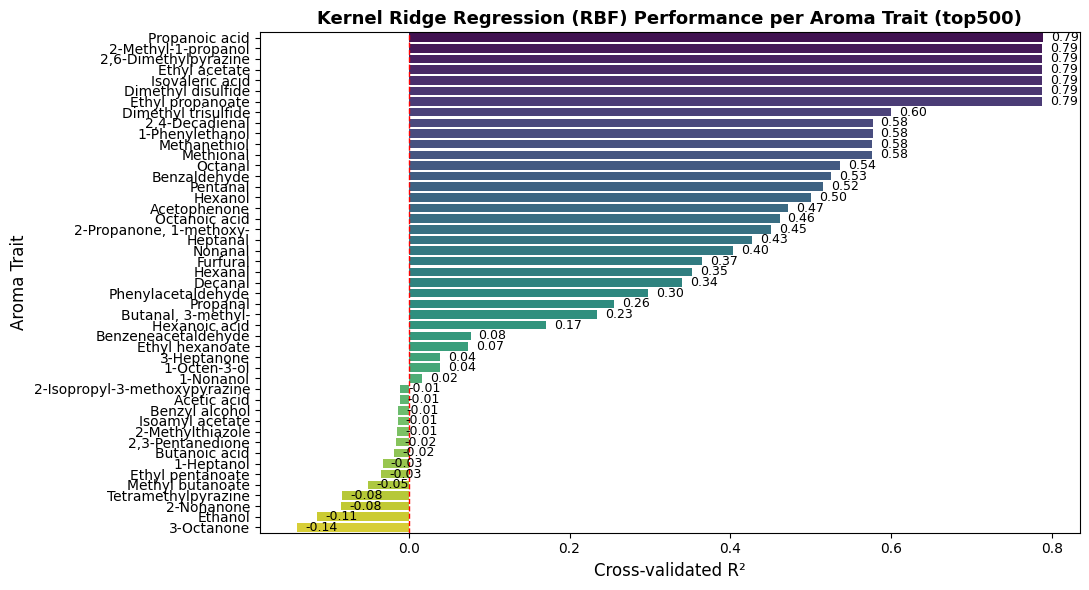

→ Mean CV R² for top_n_snps = 500: 0.3052

 Running KRR with top_n_snps = 1000

[KRR — top1000] Trait: 1-Heptanol

[KRR — top1000] Trait: 1-Nonanol

[KRR — top1000] Trait: 1-Octen-3-ol

[KRR — top1000] Trait: 1-Phenylethanol

[KRR — top1000] Trait: 2,3-Pentanedione

[KRR — top1000] Trait: 2,4-Decadienal

[KRR — top1000] Trait: 2,6-Dimethylpyrazine

[KRR — top1000] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — top1000] Trait: 2-Methyl-1-propanol

[KRR — top1000] Trait: 2-Methylthiazole

[KRR — top1000] Trait: 2-Nonanone

[KRR — top1000] Trait: 2-Propanone, 1-methoxy-

[KRR — top1000] Trait: 3-Heptanone

[KRR — top1000] Trait: 3-Octanone

[KRR — top1000] Trait: Acetic acid

[KRR — top1000] Trait: Acetophenone


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top1000] Trait: Benzaldehyde

[KRR — top1000] Trait: Benzeneacetaldehyde

[KRR — top1000] Trait: Benzyl alcohol

[KRR — top1000] Trait: Butanal, 3-methyl-

[KRR — top1000] Trait: Butanoic acid

[KRR — top1000] Trait: Decanal


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top1000] Trait: Dimethyl disulfide

[KRR — top1000] Trait: Dimethyl trisulfide

[KRR — top1000] Trait: Ethanol

[KRR — top1000] Trait: Ethyl acetate

[KRR — top1000] Trait: Ethyl hexanoate

[KRR — top1000] Trait: Ethyl pentanoate

[KRR — top1000] Trait: Ethyl propanoate

[KRR — top1000] Trait: Furfural

[KRR — top1000] Trait: Heptanal


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top1000] Trait: Hexanal

[KRR — top1000] Trait: Hexanoic acid

[KRR — top1000] Trait: Hexanol

[KRR — top1000] Trait: Isoamyl acetate

[KRR — top1000] Trait: Isovaleric acid

[KRR — top1000] Trait: Methanethiol

[KRR — top1000] Trait: Methional

[KRR — top1000] Trait: Methyl butanoate

[KRR — top1000] Trait: Nonanal

[KRR — top1000] Trait: Octanal

[KRR — top1000] Trait: Octanoic acid

[KRR — top1000] Trait: Pentanal

[KRR — top1000] Trait: Phenylacetaldehyde

[KRR — top1000] Trait: Propanal

[KRR — top1000] Trait: Propanoic acid

[KRR — top1000] Trait: Tetramethylpyrazine
✅ Results saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_top1000.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_plot_top1000.png


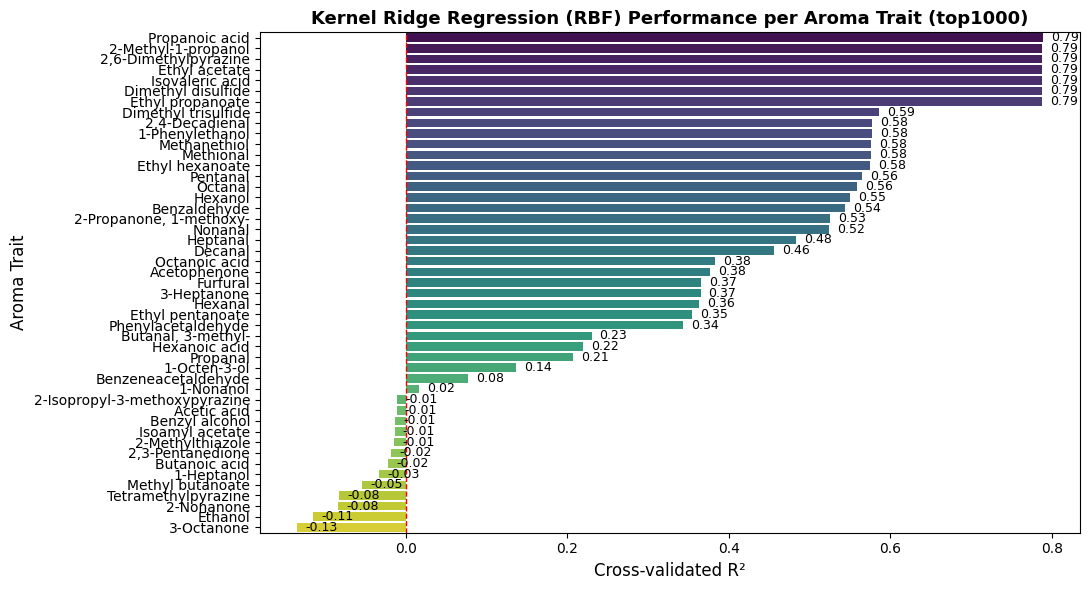

→ Mean CV R² for top_n_snps = 1000: 0.3410

 Running KRR with top_n_snps = 2000

[KRR — top2000] Trait: 1-Heptanol

[KRR — top2000] Trait: 1-Nonanol

[KRR — top2000] Trait: 1-Octen-3-ol

[KRR — top2000] Trait: 1-Phenylethanol

[KRR — top2000] Trait: 2,3-Pentanedione

[KRR — top2000] Trait: 2,4-Decadienal

[KRR — top2000] Trait: 2,6-Dimethylpyrazine

[KRR — top2000] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — top2000] Trait: 2-Methyl-1-propanol

[KRR — top2000] Trait: 2-Methylthiazole

[KRR — top2000] Trait: 2-Nonanone

[KRR — top2000] Trait: 2-Propanone, 1-methoxy-

[KRR — top2000] Trait: 3-Heptanone

[KRR — top2000] Trait: 3-Octanone

[KRR — top2000] Trait: Acetic acid

[KRR — top2000] Trait: Acetophenone


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top2000] Trait: Benzaldehyde


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top2000] Trait: Benzeneacetaldehyde

[KRR — top2000] Trait: Benzyl alcohol

[KRR — top2000] Trait: Butanal, 3-methyl-

[KRR — top2000] Trait: Butanoic acid

[KRR — top2000] Trait: Decanal


...


[KRR — top2000] Trait: Dimethyl disulfide

[KRR — top2000] Trait: Dimethyl trisulfide

[KRR — top2000] Trait: Ethanol

[KRR — top2000] Trait: Ethyl acetate

[KRR — top2000] Trait: Ethyl hexanoate

[KRR — top2000] Trait: Ethyl pentanoate

[KRR — top2000] Trait: Ethyl propanoate

[KRR — top2000] Trait: Furfural

[KRR — top2000] Trait: Heptanal


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top2000] Trait: Hexanal

[KRR — top2000] Trait: Hexanoic acid

[KRR — top2000] Trait: Hexanol

[KRR — top2000] Trait: Isoamyl acetate

[KRR — top2000] Trait: Isovaleric acid

[KRR — top2000] Trait: Methanethiol

[KRR — top2000] Trait: Methional

[KRR — top2000] Trait: Methyl butanoate

[KRR — top2000] Trait: Nonanal

[KRR — top2000] Trait: Octanal

[KRR — top2000] Trait: Octanoic acid

[KRR — top2000] Trait: Pentanal

[KRR — top2000] Trait: Phenylacetaldehyde

[KRR — top2000] Trait: Propanal

[KRR — top2000] Trait: Propanoic acid

[KRR — top2000] Trait: Tetramethylpyrazine
✅ Results saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_top2000.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_plot_top2000.png


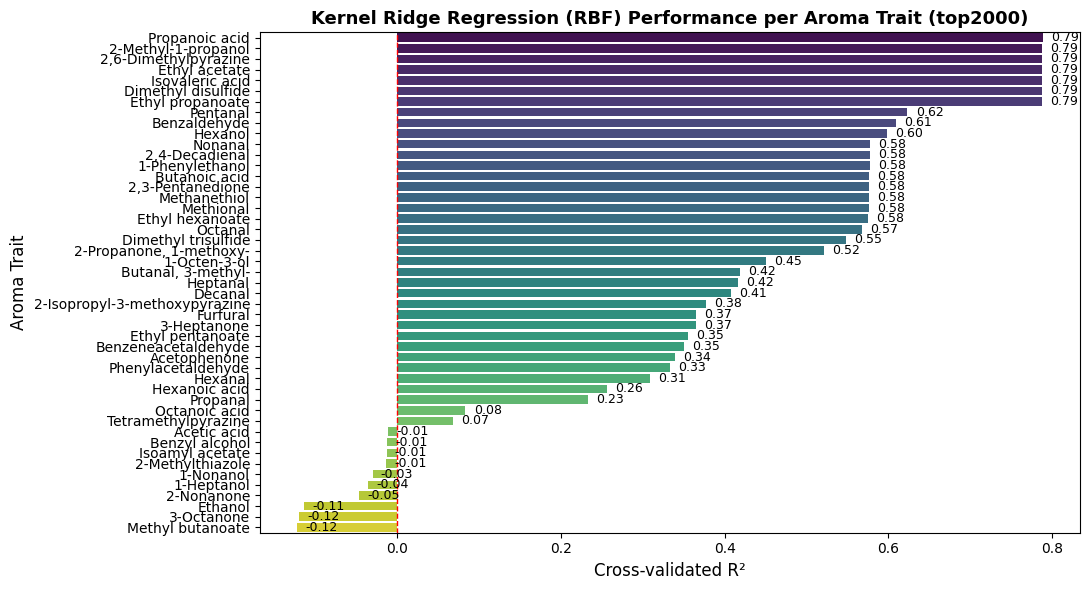

→ Mean CV R² for top_n_snps = 2000: 0.3874

 Running KRR with top_n_snps = 3000

[KRR — top3000] Trait: 1-Heptanol

[KRR — top3000] Trait: 1-Nonanol

[KRR — top3000] Trait: 1-Octen-3-ol

[KRR — top3000] Trait: 1-Phenylethanol

[KRR — top3000] Trait: 2,3-Pentanedione

[KRR — top3000] Trait: 2,4-Decadienal

[KRR — top3000] Trait: 2,6-Dimethylpyrazine

[KRR — top3000] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — top3000] Trait: 2-Methyl-1-propanol

[KRR — top3000] Trait: 2-Methylthiazole

[KRR — top3000] Trait: 2-Nonanone

[KRR — top3000] Trait: 2-Propanone, 1-methoxy-

[KRR — top3000] Trait: 3-Heptanone

[KRR — top3000] Trait: 3-Octanone

[KRR — top3000] Trait: Acetic acid

[KRR — top3000] Trait: Acetophenone


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top3000] Trait: Benzaldehyde


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top3000] Trait: Benzeneacetaldehyde

[KRR — top3000] Trait: Benzyl alcohol

[KRR — top3000] Trait: Butanal, 3-methyl-

[KRR — top3000] Trait: Butanoic acid

[KRR — top3000] Trait: Decanal


...


[KRR — top3000] Trait: Hexanal

[KRR — top3000] Trait: Hexanoic acid

[KRR — top3000] Trait: Hexanol

[KRR — top3000] Trait: Isoamyl acetate

[KRR — top3000] Trait: Isovaleric acid

[KRR — top3000] Trait: Methanethiol

[KRR — top3000] Trait: Methional

[KRR — top3000] Trait: Methyl butanoate

[KRR — top3000] Trait: Nonanal

[KRR — top3000] Trait: Octanal


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top3000] Trait: Octanoic acid

[KRR — top3000] Trait: Pentanal

[KRR — top3000] Trait: Phenylacetaldehyde

[KRR — top3000] Trait: Propanal

[KRR — top3000] Trait: Propanoic acid

[KRR — top3000] Trait: Tetramethylpyrazine
✅ Results saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_top3000.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_plot_top3000.png


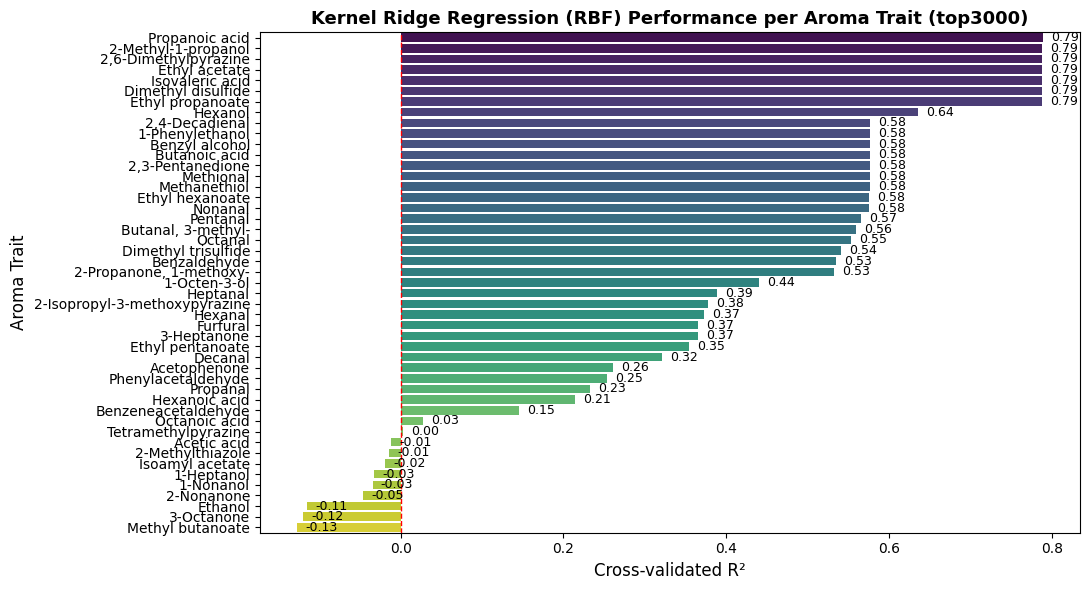

→ Mean CV R² for top_n_snps = 3000: 0.3879

 Running KRR with top_n_snps = 4000

[KRR — top4000] Trait: 1-Heptanol

[KRR — top4000] Trait: 1-Nonanol

[KRR — top4000] Trait: 1-Octen-3-ol

[KRR — top4000] Trait: 1-Phenylethanol

[KRR — top4000] Trait: 2,3-Pentanedione

[KRR — top4000] Trait: 2,4-Decadienal

[KRR — top4000] Trait: 2,6-Dimethylpyrazine

[KRR — top4000] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — top4000] Trait: 2-Methyl-1-propanol

[KRR — top4000] Trait: 2-Methylthiazole

[KRR — top4000] Trait: 2-Nonanone

[KRR — top4000] Trait: 2-Propanone, 1-methoxy-

[KRR — top4000] Trait: 3-Heptanone

[KRR — top4000] Trait: 3-Octanone

[KRR — top4000] Trait: Acetic acid

[KRR — top4000] Trait: Acetophenone


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top4000] Trait: Benzaldehyde


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top4000] Trait: Benzeneacetaldehyde

[KRR — top4000] Trait: Benzyl alcohol

[KRR — top4000] Trait: Butanal, 3-methyl-

[KRR — top4000] Trait: Butanoic acid

[KRR — top4000] Trait: Decanal


...


[KRR — top4000] Trait: Octanal


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top4000] Trait: Octanoic acid

[KRR — top4000] Trait: Pentanal

[KRR — top4000] Trait: Phenylacetaldehyde

[KRR — top4000] Trait: Propanal

[KRR — top4000] Trait: Propanoic acid

[KRR — top4000] Trait: Tetramethylpyrazine
✅ Results saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_top4000.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_plot_top4000.png


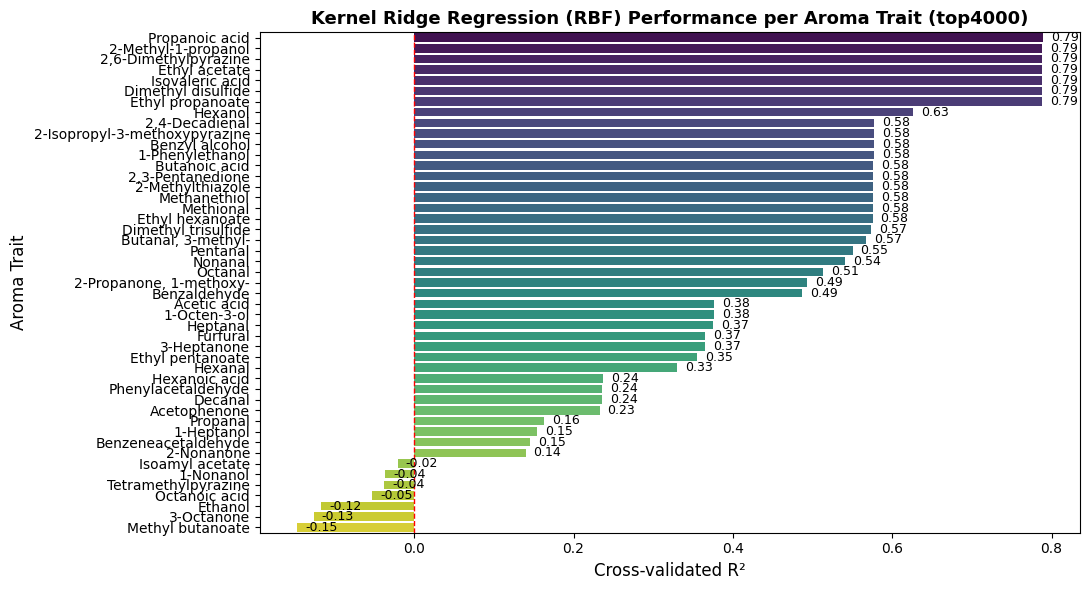

→ Mean CV R² for top_n_snps = 4000: 0.4082


In [30]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_krr_models_gene_aroma

snps_to_test = [100, 200, 500, 1000, 2000,3000,4000]
mean_r2_results = {}

for n in snps_to_test:
    print(f"\n Running KRR with top_n_snps = {n}")
    results_df, _ = run_krr_models_gene_aroma(
        gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
        snp_df=cleaned_data_gene_aroma,
        top_n_snps=n,
        prune_threshold=0.95,
        save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1",
        tag=f"top{n}"
    )

    mean_r2 = results_df["CV_Best_R2"].mean()
    mean_r2_results[n] = mean_r2
    print(f"→ Mean CV R² for top_n_snps = {n}: {mean_r2:.4f}")




 Running KRR with top_n_snps = 5000

[KRR — top5000] Trait: 1-Heptanol

[KRR — top5000] Trait: 1-Nonanol

[KRR — top5000] Trait: 1-Octen-3-ol

[KRR — top5000] Trait: 1-Phenylethanol

[KRR — top5000] Trait: 2,3-Pentanedione

[KRR — top5000] Trait: 2,4-Decadienal

[KRR — top5000] Trait: 2,6-Dimethylpyrazine

[KRR — top5000] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — top5000] Trait: 2-Methyl-1-propanol

[KRR — top5000] Trait: 2-Methylthiazole

[KRR — top5000] Trait: 2-Nonanone

[KRR — top5000] Trait: 2-Propanone, 1-methoxy-

[KRR — top5000] Trait: 3-Heptanone


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top5000] Trait: 3-Octanone

[KRR — top5000] Trait: Acetic acid

[KRR — top5000] Trait: Acetophenone


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top5000] Trait: Benzaldehyde


...


[KRR — top5000] Trait: Octanal


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top5000] Trait: Octanoic acid

[KRR — top5000] Trait: Pentanal

[KRR — top5000] Trait: Phenylacetaldehyde

[KRR — top5000] Trait: Propanal

[KRR — top5000] Trait: Propanoic acid

[KRR — top5000] Trait: Tetramethylpyrazine
✅ Results saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_top5000.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_plot_top5000.png


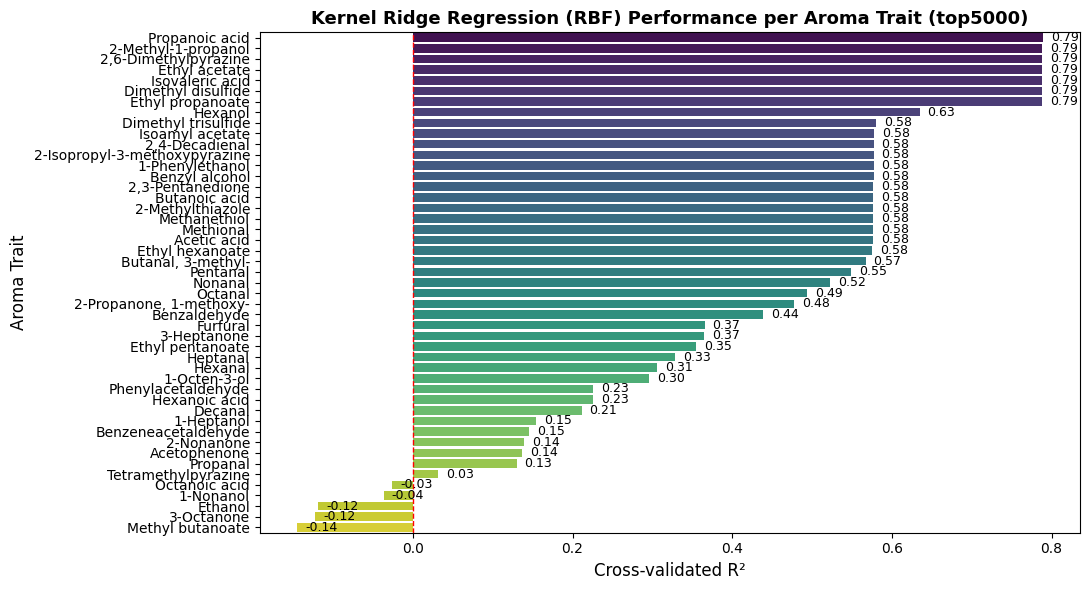

→ Mean CV R² for top_n_snps = 5000: 0.4185

 Running KRR with top_n_snps = 6000

[KRR — top6000] Trait: 1-Heptanol

[KRR — top6000] Trait: 1-Nonanol

[KRR — top6000] Trait: 1-Octen-3-ol

[KRR — top6000] Trait: 1-Phenylethanol

[KRR — top6000] Trait: 2,3-Pentanedione

[KRR — top6000] Trait: 2,4-Decadienal

[KRR — top6000] Trait: 2,6-Dimethylpyrazine

[KRR — top6000] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — top6000] Trait: 2-Methyl-1-propanol

[KRR — top6000] Trait: 2-Methylthiazole

[KRR — top6000] Trait: 2-Nonanone

[KRR — top6000] Trait: 2-Propanone, 1-methoxy-

[KRR — top6000] Trait: 3-Heptanone


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top6000] Trait: 3-Octanone

[KRR — top6000] Trait: Acetic acid

[KRR — top6000] Trait: Acetophenone


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top6000] Trait: Benzaldehyde


...


[KRR — top6000] Trait: Octanal


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top6000] Trait: Octanoic acid

[KRR — top6000] Trait: Pentanal

[KRR — top6000] Trait: Phenylacetaldehyde

[KRR — top6000] Trait: Propanal

[KRR — top6000] Trait: Propanoic acid

[KRR — top6000] Trait: Tetramethylpyrazine
✅ Results saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_top6000.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_plot_top6000.png


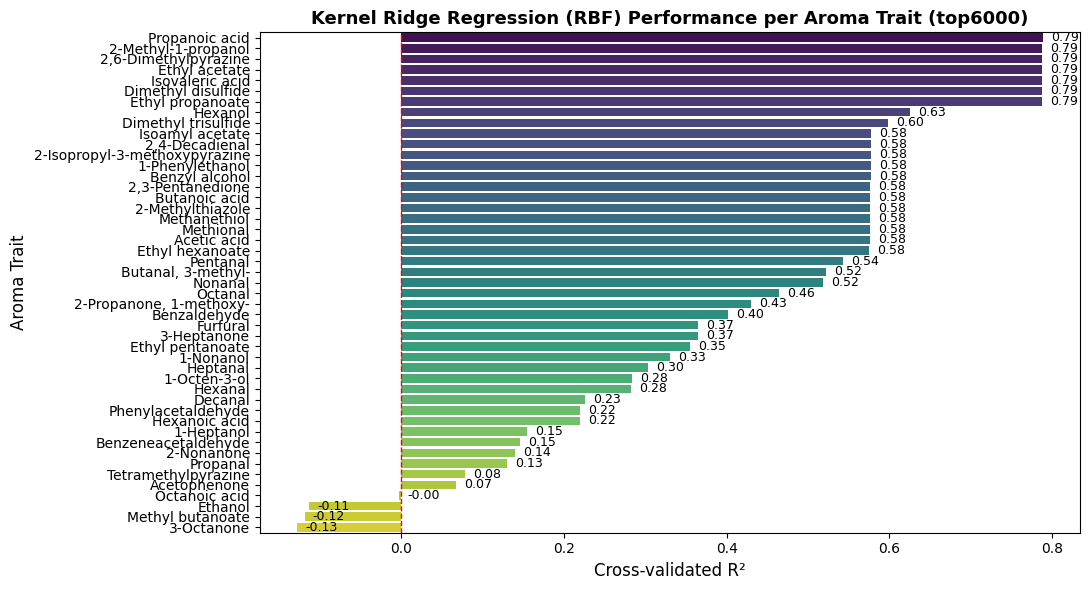

→ Mean CV R² for top_n_snps = 6000: 0.4222

 Running KRR with top_n_snps = 7000

[KRR — top7000] Trait: 1-Heptanol

[KRR — top7000] Trait: 1-Nonanol

[KRR — top7000] Trait: 1-Octen-3-ol

[KRR — top7000] Trait: 1-Phenylethanol

[KRR — top7000] Trait: 2,3-Pentanedione


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top7000] Trait: 2,4-Decadienal

[KRR — top7000] Trait: 2,6-Dimethylpyrazine


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top7000] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — top7000] Trait: 2-Methyl-1-propanol


...


[KRR — top7000] Trait: Octanal


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top7000] Trait: Octanoic acid

[KRR — top7000] Trait: Pentanal

[KRR — top7000] Trait: Phenylacetaldehyde

[KRR — top7000] Trait: Propanal

[KRR — top7000] Trait: Propanoic acid

[KRR — top7000] Trait: Tetramethylpyrazine
✅ Results saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_top7000.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_plot_top7000.png


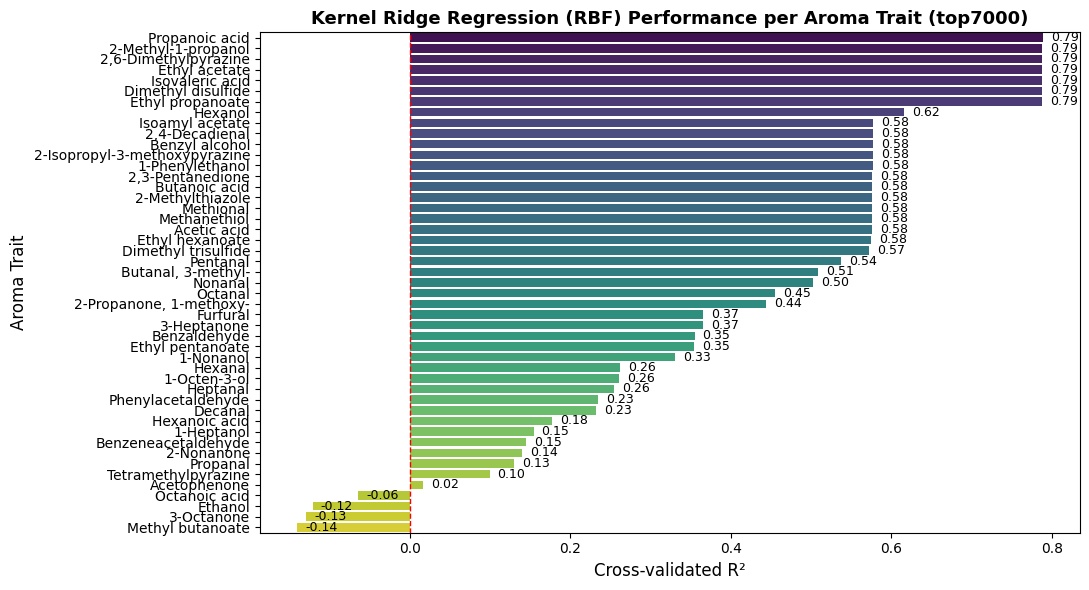

→ Mean CV R² for top_n_snps = 7000: 0.4148

 Running KRR with top_n_snps = 8000

[KRR — top8000] Trait: 1-Heptanol

[KRR — top8000] Trait: 1-Nonanol

[KRR — top8000] Trait: 1-Octen-3-ol

[KRR — top8000] Trait: 1-Phenylethanol

[KRR — top8000] Trait: 2,3-Pentanedione


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top8000] Trait: 2,4-Decadienal

[KRR — top8000] Trait: 2,6-Dimethylpyrazine


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top8000] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — top8000] Trait: 2-Methyl-1-propanol


...


[KRR — top8000] Trait: Octanoic acid


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top8000] Trait: Pentanal

[KRR — top8000] Trait: Phenylacetaldehyde

[KRR — top8000] Trait: Propanal

[KRR — top8000] Trait: Propanoic acid

[KRR — top8000] Trait: Tetramethylpyrazine
✅ Results saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_top8000.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_plot_top8000.png


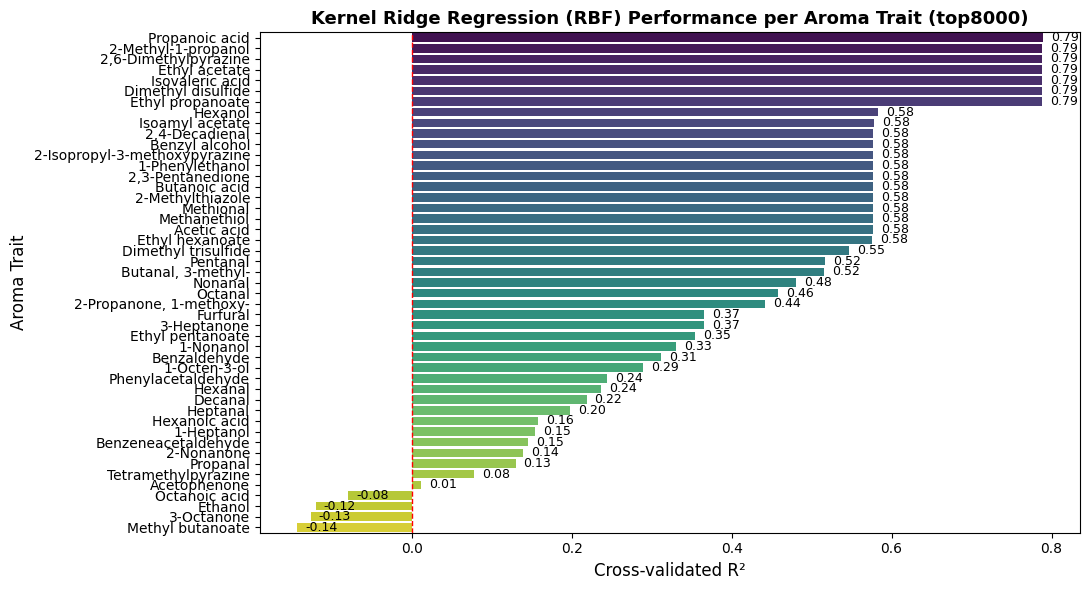

→ Mean CV R² for top_n_snps = 8000: 0.4094

 Running KRR with top_n_snps = 9000

[KRR — top9000] Trait: 1-Heptanol

[KRR — top9000] Trait: 1-Nonanol

[KRR — top9000] Trait: 1-Octen-3-ol

[KRR — top9000] Trait: 1-Phenylethanol

[KRR — top9000] Trait: 2,3-Pentanedione


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top9000] Trait: 2,4-Decadienal

[KRR — top9000] Trait: 2,6-Dimethylpyrazine


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top9000] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — top9000] Trait: 2-Methyl-1-propanol


...


[KRR — top9000] Trait: Tetramethylpyrazine


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


✅ Results saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_top9000.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_plot_top9000.png


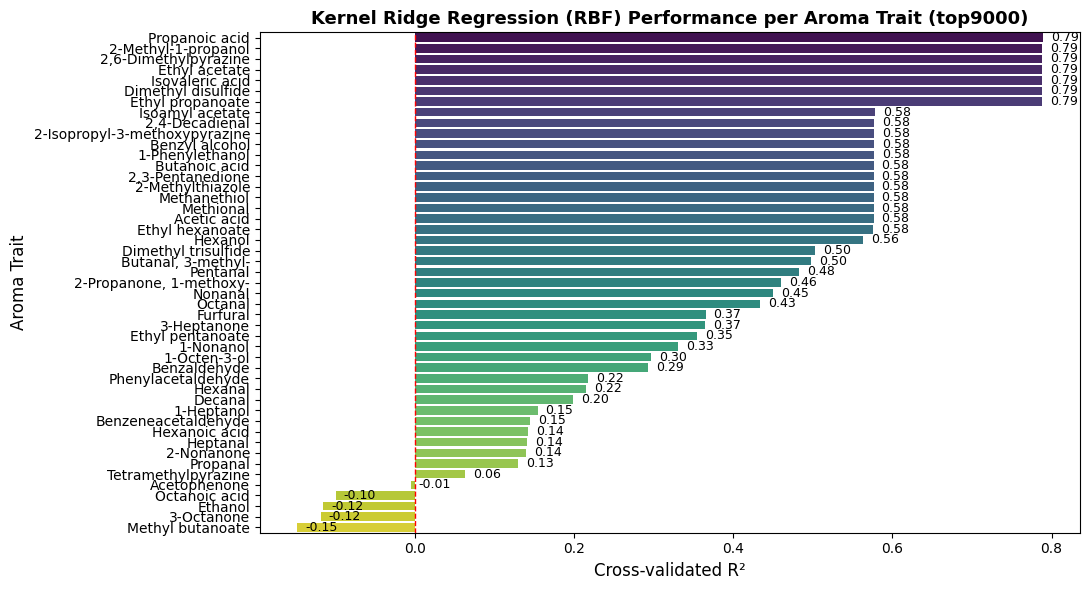

→ Mean CV R² for top_n_snps = 9000: 0.4021

 Running KRR with top_n_snps = 10000

[KRR — top10000] Trait: 1-Heptanol

[KRR — top10000] Trait: 1-Nonanol

[KRR — top10000] Trait: 1-Octen-3-ol

[KRR — top10000] Trait: 1-Phenylethanol

[KRR — top10000] Trait: 2,3-Pentanedione


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top10000] Trait: 2,4-Decadienal

[KRR — top10000] Trait: 2,6-Dimethylpyrazine


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — top10000] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — top10000] Trait: 2-Methyl-1-propanol


...


[KRR — top10000] Trait: Tetramethylpyrazine


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


✅ Results saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_top10000.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_plot_top10000.png


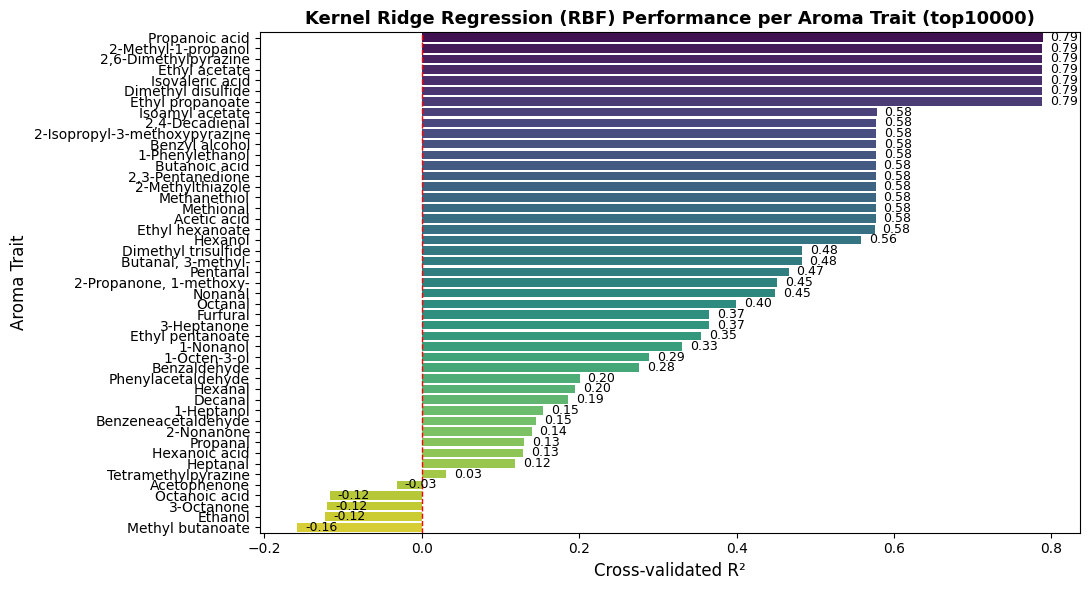

→ Mean CV R² for top_n_snps = 10000: 0.3955


In [31]:
snps_to_test = [5000,6000,7000,8000,9000,10000]
mean_r2_results = {}

for n in snps_to_test:
    print(f"\n Running KRR with top_n_snps = {n}")
    results_df, _ = run_krr_models_gene_aroma(
        gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
        snp_df=cleaned_data_gene_aroma,
        top_n_snps=n,
        prune_threshold=0.95,
        save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1",
        tag=f"top{n}"
    )

    mean_r2 = results_df["CV_Best_R2"].mean()
    mean_r2_results[n] = mean_r2
    print(f"→ Mean CV R² for top_n_snps = {n}: {mean_r2:.4f}")


# KRR Modeling After Outlier Removal


[KRR — outlier removed] Trait: 1-Heptanol

[KRR — outlier removed] Trait: 1-Nonanol

[KRR — outlier removed] Trait: 1-Octen-3-ol

[KRR — outlier removed] Trait: 1-Phenylethanol

[KRR — outlier removed] Trait: 2,3-Pentanedione

[KRR — outlier removed] Trait: 2,4-Decadienal

[KRR — outlier removed] Trait: 2,6-Dimethylpyrazine

[KRR — outlier removed] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — outlier removed] Trait: 2-Methyl-1-propanol

[KRR — outlier removed] Trait: 2-Methylthiazole

[KRR — outlier removed] Trait: 2-Nonanone

[KRR — outlier removed] Trait: 2-Propanone, 1-methoxy-

[KRR — outlier removed] Trait: 3-Heptanone


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — outlier removed] Trait: 3-Octanone

[KRR — outlier removed] Trait: Acetic acid

[KRR — outlier removed] Trait: Acetophenone


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — outlier removed] Trait: Benzaldehyde


...


[KRR — outlier removed] Trait: Octanal


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — outlier removed] Trait: Octanoic acid

[KRR — outlier removed] Trait: Pentanal

[KRR — outlier removed] Trait: Phenylacetaldehyde

[KRR — outlier removed] Trait: Propanal

[KRR — outlier removed] Trait: Propanoic acid

[KRR — outlier removed] Trait: Tetramethylpyrazine
✅ Results saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_outlier_removed.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_plot_outlier_removed.png


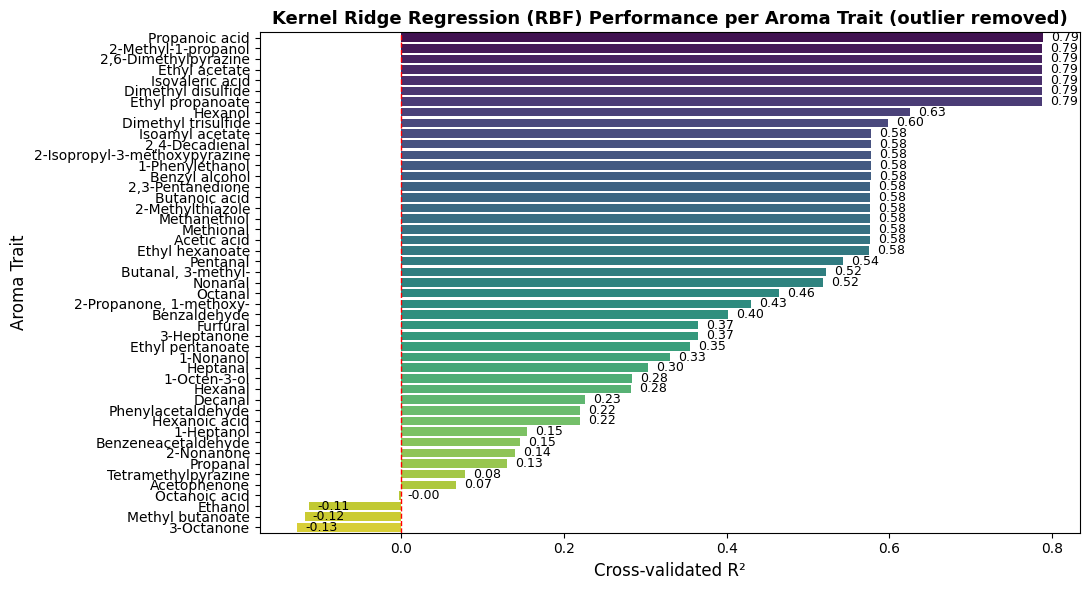

In [32]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import  run_krr_models_gene_aroma

results_krr_outlier_removed = run_krr_models_gene_aroma(
    gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
    snp_df=cleaned_data_gene_aroma,
    top_n_snps=6000,
    prune_threshold=0.95,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1",
    tag="outlier removed"
)


# Linear Modeling of Sensory Principal Components Using GWAS-Derived Genetic Markers in Potato Varieties


[Linear Models] Trait: PC1
  Significant SNPs found: 257

[Linear Models] Trait: PC2
  No SNPs with FDR < 0.05. Using top 4000 by p-value.

[Linear Models] Trait: PC3
  No SNPs with FDR < 0.05. Using top 4000 by p-value.

 Linear model results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\linear_models_sensory_PCs_FDR05.csv


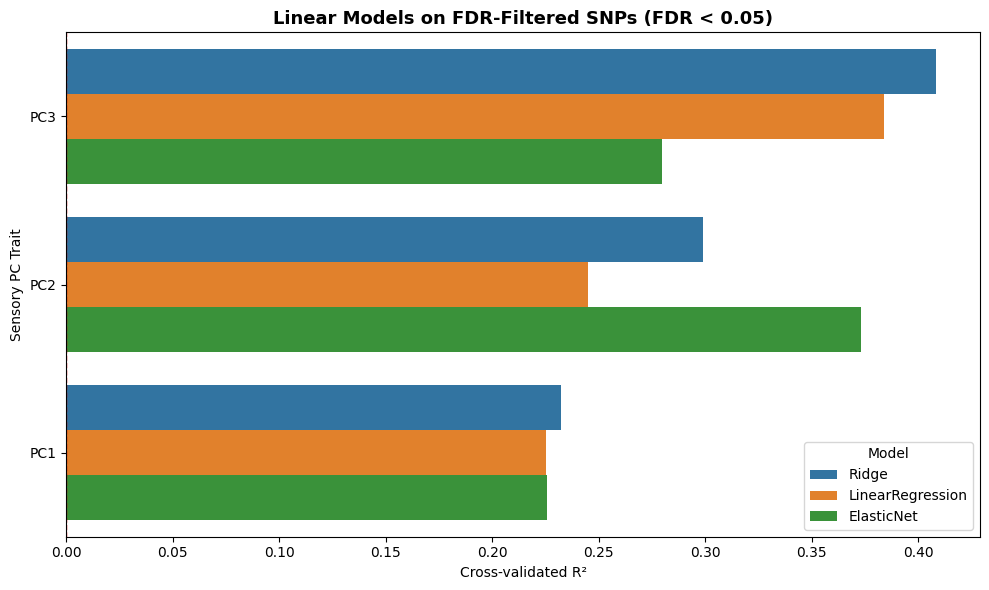

In [33]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import  run_linear_models_sensory



results_sensory = run_linear_models_sensory(
    gwas_file=gwas_output_sensory,
    merged_snp_df=merged_snp_sensory,
    fdr_threshold=0.05,
    top_n_fallback=4000,
    prune_threshold=0.9,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1"
)




# Nonlinear Modeling of Sensory Principal Components Using Kernel Ridge Regression (RBF Kernel)”


🔹 Running KRR–RBF sensory model with top_n_fallback = 100

[Kernel Ridge Regression - Sensory PCs] Trait: PC1
  Significant SNPs found: 257

[Kernel Ridge Regression - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.05. Using top 100 by p-value.

[Kernel Ridge Regression - Sensory PCs] Trait: PC3
  No SNPs with FDR < 0.05. Using top 100 by p-value.

 Results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_sensory_PCs_FDRfiltered.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2831: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_sensory_PCs_plot_FDRfiltered.png


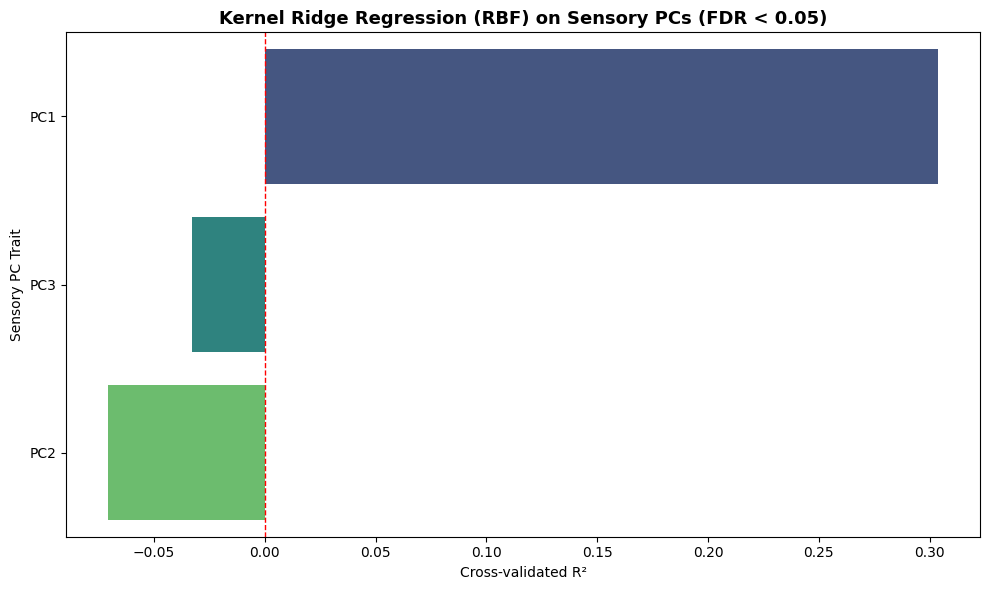

→ Mean CV R² for top_n_fallback = 100: 0.0668

🔹 Running KRR–RBF sensory model with top_n_fallback = 500

[Kernel Ridge Regression - Sensory PCs] Trait: PC1
  Significant SNPs found: 257

[Kernel Ridge Regression - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.05. Using top 500 by p-value.

[Kernel Ridge Regression - Sensory PCs] Trait: PC3
  No SNPs with FDR < 0.05. Using top 500 by p-value.

 Results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_sensory_PCs_FDRfiltered.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2831: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_sensory_PCs_plot_FDRfiltered.png


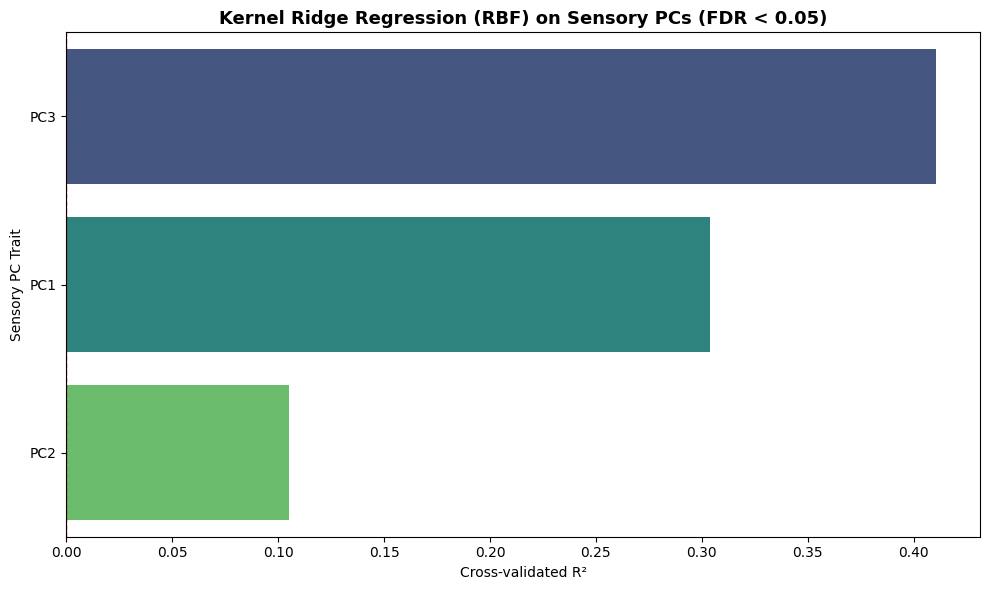

→ Mean CV R² for top_n_fallback = 500: 0.2733

🔹 Running KRR–RBF sensory model with top_n_fallback = 1000

[Kernel Ridge Regression - Sensory PCs] Trait: PC1
  Significant SNPs found: 257

[Kernel Ridge Regression - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.05. Using top 1000 by p-value.

[Kernel Ridge Regression - Sensory PCs] Trait: PC3
  No SNPs with FDR < 0.05. Using top 1000 by p-value.

 Results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_sensory_PCs_FDRfiltered.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2831: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_sensory_PCs_plot_FDRfiltered.png


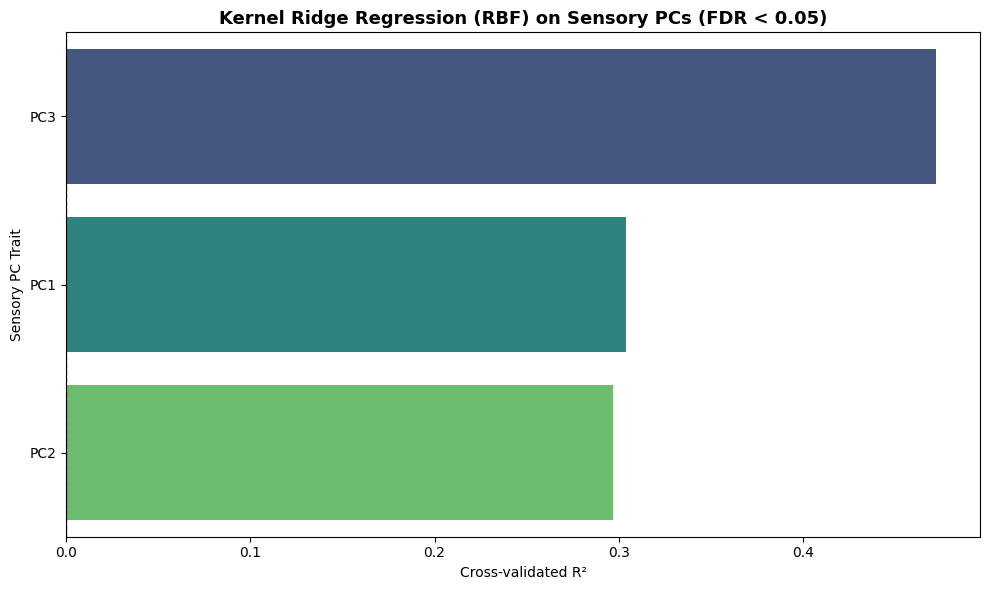

→ Mean CV R² for top_n_fallback = 1000: 0.3579

🔹 Running KRR–RBF sensory model with top_n_fallback = 2000

[Kernel Ridge Regression - Sensory PCs] Trait: PC1
  Significant SNPs found: 257

[Kernel Ridge Regression - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.05. Using top 2000 by p-value.

[Kernel Ridge Regression - Sensory PCs] Trait: PC3
  No SNPs with FDR < 0.05. Using top 2000 by p-value.

 Results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_sensory_PCs_FDRfiltered.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2831: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_sensory_PCs_plot_FDRfiltered.png


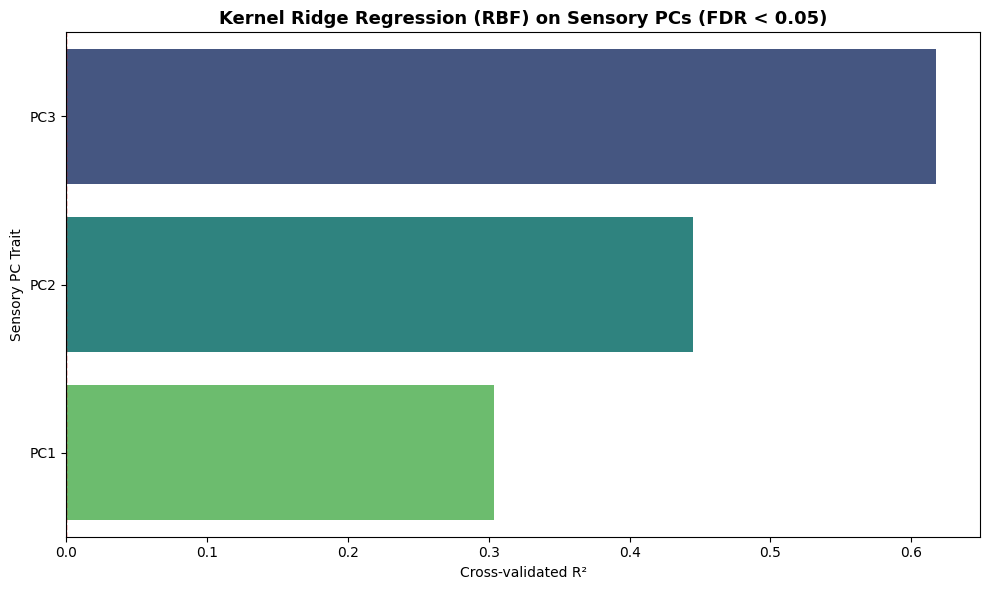

→ Mean CV R² for top_n_fallback = 2000: 0.4555

🔹 Running KRR–RBF sensory model with top_n_fallback = 4000

[Kernel Ridge Regression - Sensory PCs] Trait: PC1
  Significant SNPs found: 257

[Kernel Ridge Regression - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.05. Using top 4000 by p-value.

[Kernel Ridge Regression - Sensory PCs] Trait: PC3
  No SNPs with FDR < 0.05. Using top 4000 by p-value.

 Results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_sensory_PCs_FDRfiltered.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2831: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_sensory_PCs_plot_FDRfiltered.png


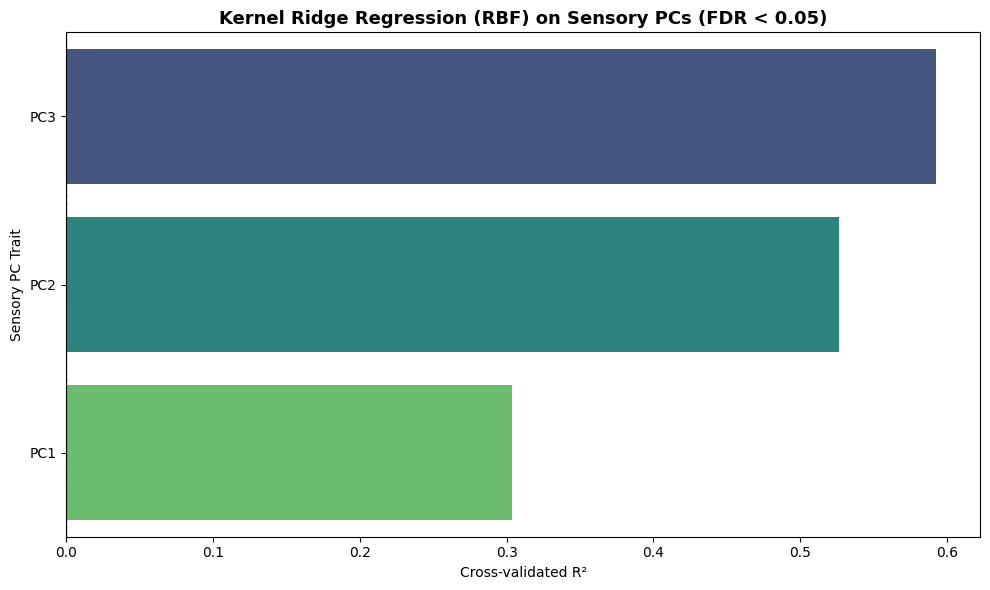

→ Mean CV R² for top_n_fallback = 4000: 0.4744

🔹 Running KRR–RBF sensory model with top_n_fallback = 6000

[Kernel Ridge Regression - Sensory PCs] Trait: PC1
  Significant SNPs found: 257

[Kernel Ridge Regression - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.05. Using top 6000 by p-value.

[Kernel Ridge Regression - Sensory PCs] Trait: PC3
  No SNPs with FDR < 0.05. Using top 6000 by p-value.

 Results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_sensory_PCs_FDRfiltered.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2831: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_sensory_PCs_plot_FDRfiltered.png


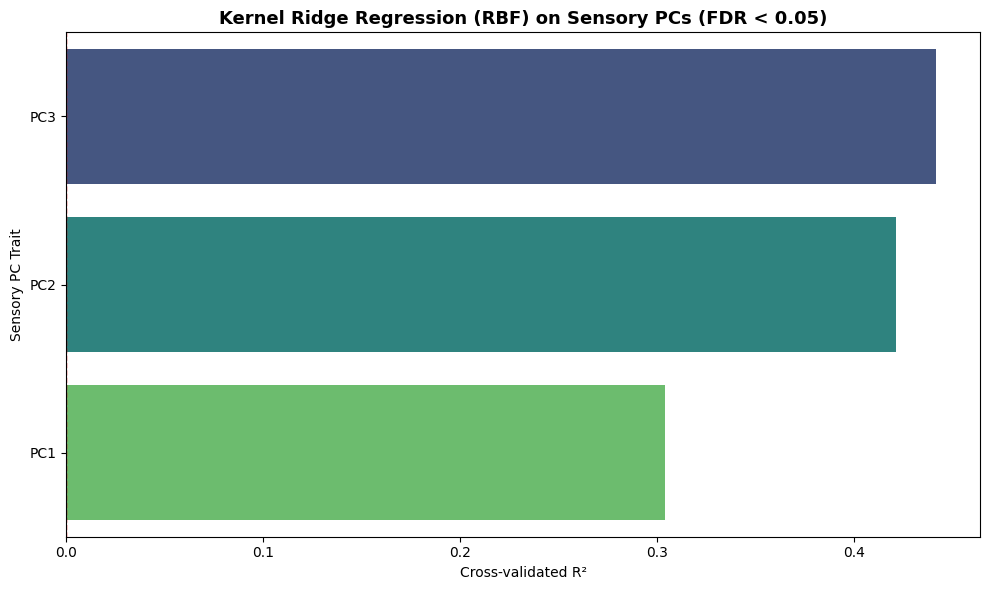

→ Mean CV R² for top_n_fallback = 6000: 0.3890


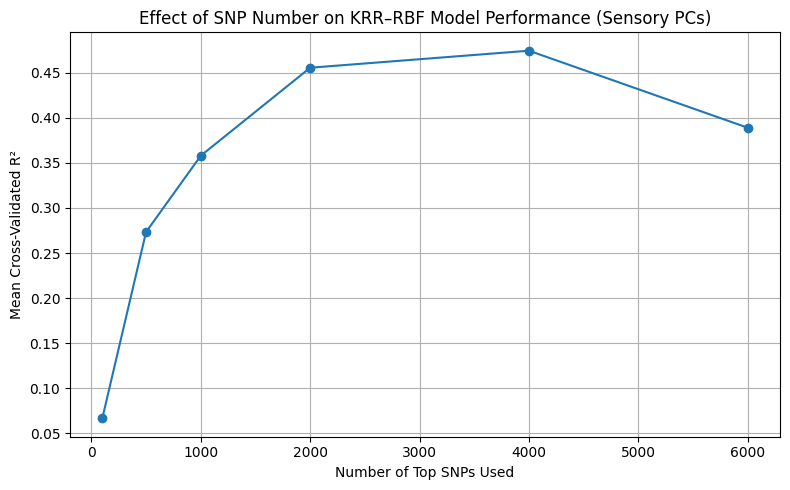


 SNP performance evaluation for KRR–RBF (Sensory PCs) completed.
   Top_N_SNPs  Mean_CV_R2
0         100    0.066752
1         500    0.273347
2        1000    0.357905
3        2000    0.455507
4        4000    0.474372
5        6000    0.388991


In [34]:


import importlib
import pandas as pd
import matplotlib.pyplot as plt
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_krr_sensory_pcs

# Define SNP thresholds to test
snp_thresholds = [100, 500, 1000, 2000, 4000, 6000]

mean_r2_results = {}

# Loop through each SNP threshold
for n in snp_thresholds:
    print(f"\n🔹 Running KRR–RBF sensory model with top_n_fallback = {n}")
    
    results_krr_fdr = run_krr_sensory_pcs(
        gwas_file=gwas_output_sensory,
        merged_snp_df=merged_snp_sensory,
        fdr_threshold=0.05,        # Keep consistent FDR filtering
        top_n_fallback=n,          # Vary SNP count
        prune_threshold=0.95,      # Keep LD pruning to prevent redundancy
        save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1"
    )
    
    # Calculate and store mean R² for this SNP threshold
    if not results_krr_fdr.empty:
        mean_r2 = results_krr_fdr["CV_Best_R2"].mean()
        mean_r2_results[n] = mean_r2
        print(f"→ Mean CV R² for top_n_fallback = {n}: {mean_r2:.4f}")
    else:
        mean_r2_results[n] = None
        print(" No results returned for this SNP threshold.")

# Convert to DataFrame
mean_r2_df = pd.DataFrame(list(mean_r2_results.items()), columns=["Top_N_SNPs", "Mean_CV_R2"])

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(mean_r2_df["Top_N_SNPs"], mean_r2_df["Mean_CV_R2"], marker="o", linestyle="-")
plt.xlabel("Number of Top SNPs Used")
plt.ylabel("Mean Cross-Validated R²")
plt.title("Effect of SNP Number on KRR–RBF Model Performance (Sensory PCs)")
plt.grid(True)
plt.tight_layout()

# Save plot
plot_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_sensory_performance_vs_snps.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print("\n SNP performance evaluation for KRR–RBF (Sensory PCs) completed.")
print(mean_r2_df)

# results_krr_fdr = run_krr_sensory_pcs(
#     gwas_file=gwas_output_sensory,
#     merged_snp_df=merged_snp_sensory,
#     fdr_threshold=0.05,
#     top_n_fallback=1000,
#     prune_threshold=0.95,
#     save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1"
# )


# Nonlinear Modeling of Sensory Principal Components Using SVR, Random Forest, and XGBoost


=== Running nonlinear sensory PCA model with top_n_fallback = 500 ===

[Nonlinear Models - Sensory PCs] Trait: PC1
  Significant SNPs found: 257
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.05. Using top 500 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC3
  No SNPs with FDR < 0.05. Using top 500 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

Mean cross-validated R² across all traits: 0.0016

Results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\nonlinear_models_sensory_PCs_FDRfiltered_top500.csv
Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\nonlinear_sensory_PCs_plot_top500.png


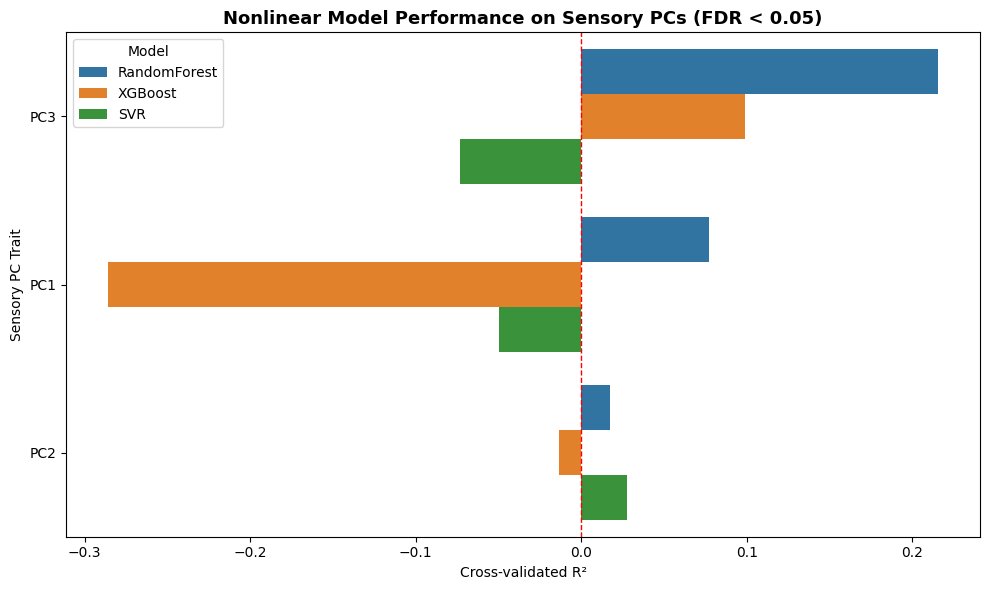


=== Running nonlinear sensory PCA model with top_n_fallback = 1000 ===

[Nonlinear Models - Sensory PCs] Trait: PC1
  Significant SNPs found: 257
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.05. Using top 1000 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC3
  No SNPs with FDR < 0.05. Using top 1000 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

Mean cross-validated R² across all traits: -0.0049

Results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\nonlinear_models_sensory_PCs_FDRfiltered_top1000.csv
Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\nonlinear_sensory_PCs_plot_top1000.png


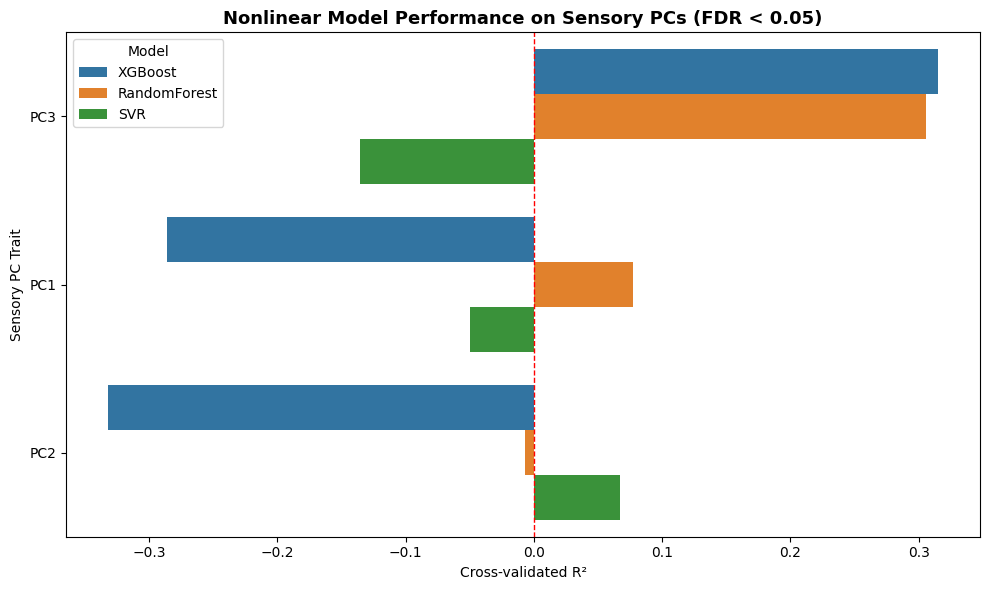


=== Running nonlinear sensory PCA model with top_n_fallback = 2000 ===

[Nonlinear Models - Sensory PCs] Trait: PC1
  Significant SNPs found: 257
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.05. Using top 2000 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC3
  No SNPs with FDR < 0.05. Using top 2000 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

Mean cross-validated R² across all traits: 0.0630

Results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\nonlinear_models_sensory_PCs_FDRfiltered_top2000.csv
Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\nonlinear_sensory_PCs_plot_top2000.png


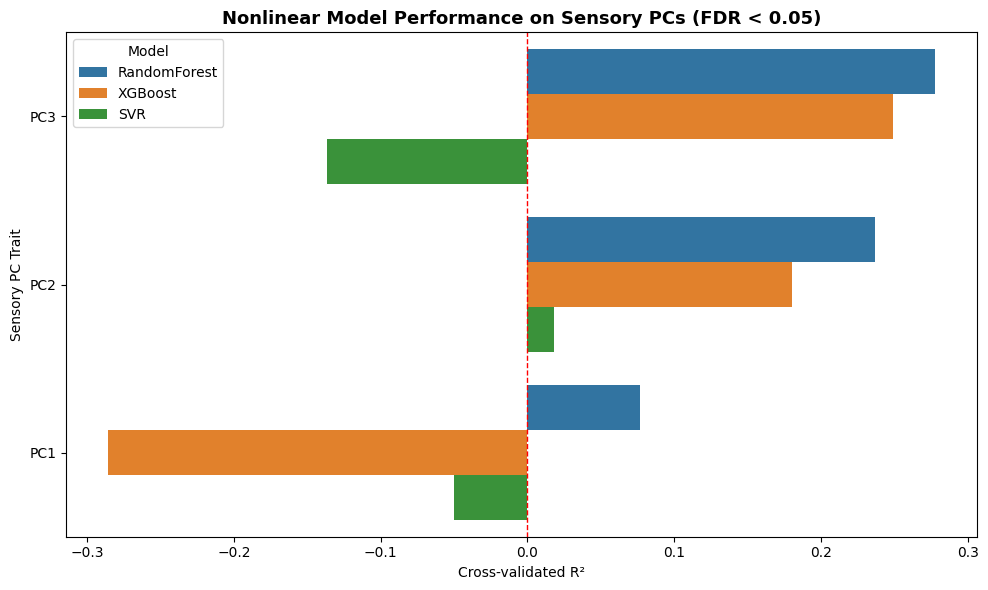


=== Running nonlinear sensory PCA model with top_n_fallback = 4000 ===

[Nonlinear Models - Sensory PCs] Trait: PC1
  Significant SNPs found: 257
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.05. Using top 4000 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC3
  No SNPs with FDR < 0.05. Using top 4000 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

Mean cross-validated R² across all traits: 0.0067

Results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\nonlinear_models_sensory_PCs_FDRfiltered_top4000.csv
Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\nonlinear_sensory_PCs_plot_top4000.png


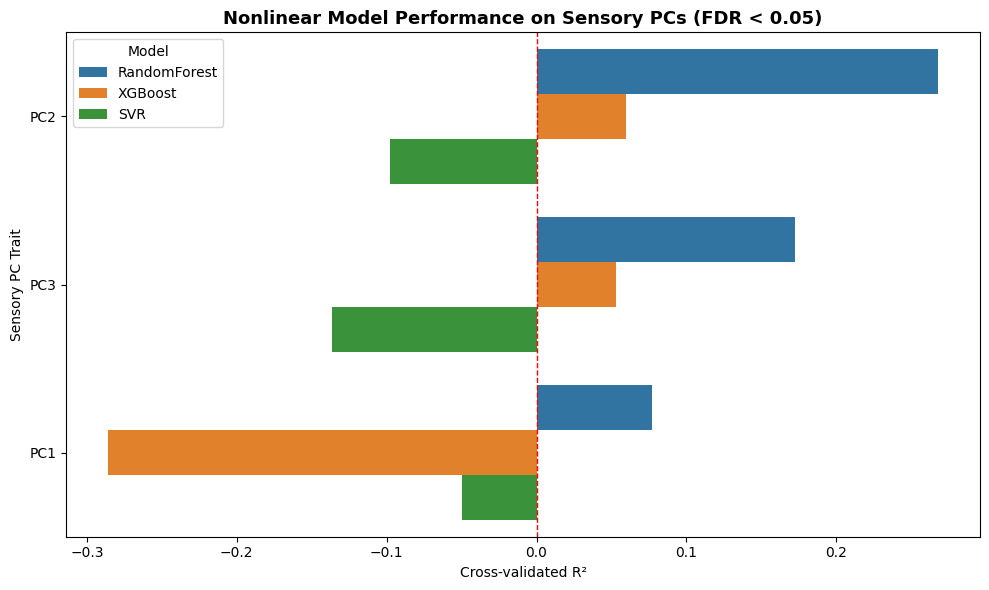


=== Running nonlinear sensory PCA model with top_n_fallback = 6000 ===

[Nonlinear Models - Sensory PCs] Trait: PC1
  Significant SNPs found: 257
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.05. Using top 6000 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC3
  No SNPs with FDR < 0.05. Using top 6000 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

Mean cross-validated R² across all traits: -0.0265

Results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\nonlinear_models_sensory_PCs_FDRfiltered_top6000.csv
Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\nonlinear_sensory_PCs_plot_top6000.png


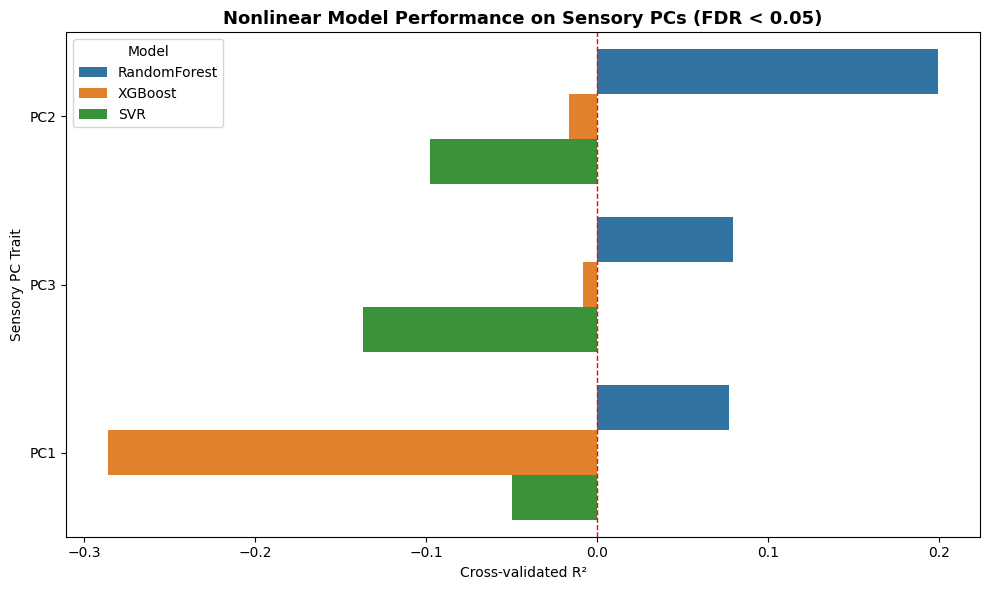


=== Running nonlinear sensory PCA model with top_n_fallback = 7000 ===

[Nonlinear Models - Sensory PCs] Trait: PC1
  Significant SNPs found: 257
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC2
  No SNPs with FDR < 0.05. Using top 7000 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

[Nonlinear Models - Sensory PCs] Trait: PC3
  No SNPs with FDR < 0.05. Using top 7000 by p-value.
   → Fitting SVR ...
   → Fitting RandomForest ...
   → Fitting XGBoost ...

Mean cross-validated R² across all traits: -0.0301

Results saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\nonlinear_models_sensory_PCs_FDRfiltered_top7000.csv
Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\nonlinear_sensory_PCs_plot_top7000.png


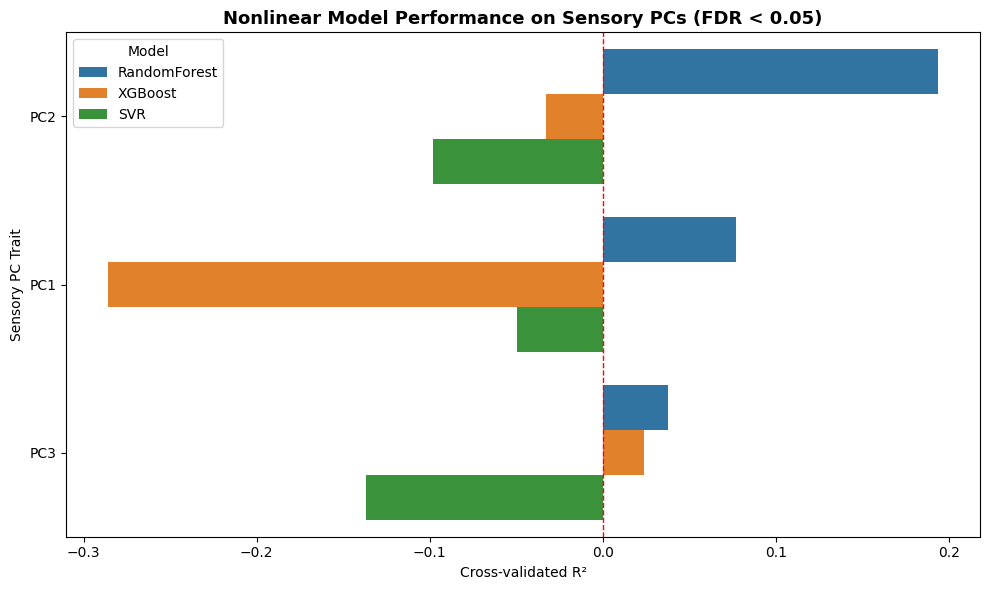


Model performance summary:
Top 500 SNPs → Mean CV R² = 0.0016
Top 1000 SNPs → Mean CV R² = -0.0049
Top 2000 SNPs → Mean CV R² = 0.0630
Top 4000 SNPs → Mean CV R² = 0.0067
Top 6000 SNPs → Mean CV R² = -0.0265
Top 7000 SNPs → Mean CV R² = -0.0301


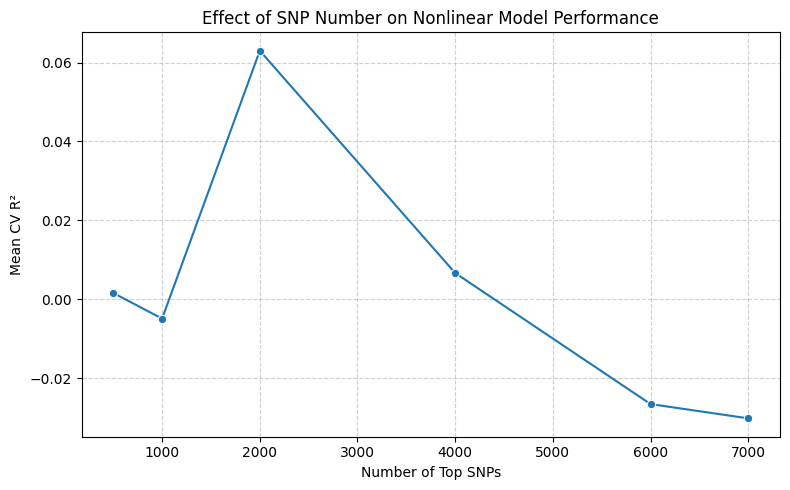

In [35]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_nonlinear_sensory_pcs



# --- Loop Through Different SNP Subsets ---
top_snp_values = [500, 1000, 2000, 4000, 6000, 7000]
results_nonlinear_fdr10_dict = {}

for n in top_snp_values:
    print(f"\n=== Running nonlinear sensory PCA model with top_n_fallback = {n} ===")
    result = run_nonlinear_sensory_pcs(
        gwas_file=gwas_output_sensory,
        merged_snp_df=merged_snp_sensory,
        fdr_threshold=0.05,
        top_n_fallback=n,
        prune_threshold=0.95,
        save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1"
    )
    results_nonlinear_fdr10_dict[n] = result["mean_cv_r2"]

# --- Summary of All Runs ---
print("\nModel performance summary:")
for n, r2 in results_nonlinear_fdr10_dict.items():
    print(f"Top {n} SNPs → Mean CV R² = {r2:.4f}")

# --- Plot R² vs SNP number ---
plt.figure(figsize=(8, 5))
sns.lineplot(x=list(results_nonlinear_fdr10_dict.keys()),
             y=list(results_nonlinear_fdr10_dict.values()),
             marker="o")
plt.xlabel("Number of Top SNPs")
plt.ylabel("Mean CV R²")
plt.title("Effect of SNP Number on Nonlinear Model Performance")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


# Modeling After Outlier Removal

In [36]:


# def analyze_gwas_snps_pca(
#     gwas_path: str,
#     merged_snp_sensory: pd.DataFrame,
#     fdr_threshold: float = 0.05,
#     top_n_fallback: int = 500,
#     outlier_z_pca=(3, 2.5)
# ):
#     """
#     Analyze GWAS results: select significant SNPs and perform PCA with outlier detection.

#     Parameters
#     ----------
#     gwas_path : str
#         Path to the GWAS results CSV file.
#     merged_snp_sensory : pd.DataFrame
#         Merged SNP × sensory PCs data.
#     fdr_threshold : float, optional
#         Significance threshold for FDR (default: 0.05).
#     top_n_fallback : int, optional
#         Number of top SNPs to use if no FDR-significant SNPs are found (default: 500).
#     outlier_z_pca : tuple, optional
#         Z-score thresholds for (PC1, PC2) outlier detection in PCA.

#     Returns
#     -------
#     dict
#         Dictionary with PCA and outlier detection results:
#         {
#             "significant_snps": list,
#             "pca_model": PCA(),
#             "pca_outliers": list
#         }
#     """

#     # =====================================================
#     # 1. Load GWAS results and extract significant SNPs
#     # =====================================================
#     gwas_df = pd.read_csv(gwas_path)

#     significant_snps = gwas_df[gwas_df["p_fdr"] < fdr_threshold]["SNP"].unique().tolist()
#     if len(significant_snps) == 0:
#         print(f" No SNPs with FDR < {fdr_threshold}. Using top {top_n_fallback} by p-value.")
#         significant_snps = (
#             gwas_df.sort_values("p_fdr")
#             .head(top_n_fallback)["SNP"]
#             .unique()
#             .tolist()
#         )
#     else:
#         print(f" Significant SNPs found: {len(significant_snps)}")

#     # =====================================================
#     # 2. Subset SNP and sensory PC data
#     # =====================================================
#     snp_cols = [col for col in merged_snp_sensory.columns if col.startswith("GEN__")]
#     snp_subset = merged_snp_sensory.loc[:, [s for s in significant_snps if s in snp_cols]].fillna(0).astype(float)

#     if snp_subset.empty:
#         raise ValueError("No matching SNPs found in merged_snp_sensory.")

#     # =====================================================
#     # 3. PCA with Outlier Detection
#     # =====================================================
#     X_scaled = StandardScaler().fit_transform(snp_subset)
#     pca = PCA(n_components=2)
#     X_pca = pca.fit_transform(X_scaled)

#     Z = np.abs(zscore(X_pca))
#     outlier_mask = (Z[:, 0] > outlier_z_pca[0]) | (Z[:, 1] > outlier_z_pca[1])
#     normal_mask = ~outlier_mask

#     # --- PCA Plot ---
#     plt.figure(figsize=(9, 7))
#     plt.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
#                 color="steelblue", alpha=0.7, s=60, label="Normal varieties")
#     plt.scatter(X_pca[outlier_mask, 0], X_pca[outlier_mask, 1],
#                 color="red", s=120, edgecolor="black", label="Outliers")

#     np.random.seed(42)
#     for i in np.where(outlier_mask)[0]:
#         name = snp_subset.index[i]
#         dx, dy = np.random.uniform(0.2, 0.8), np.random.uniform(0.2, 0.8)
#         plt.text(X_pca[i, 0] + dx, X_pca[i, 1] + dy, name,
#                  fontsize=10, color="red", fontweight="bold")

#     plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
#     plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
#     plt.title("PCA on Significant SNPs (Outlier Detection)")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # =====================================================
#     # 4. Return Results
#     # =====================================================
#     pca_outliers = snp_subset.index[outlier_mask].tolist()

#     return {
#         "significant_snps": significant_snps,
#         "pca_model": pca,
#         "pca_outliers": pca_outliers
#     }



# # # 1. Run PCA and detect outliers
# # results_pca = analyze_gwas_snps_pca(
# #     gwas_path=gwas_output_sensory,
# #     merged_snp_sensory=merged_snp_sensory
# # )

# # # 2. Extract outliers
# # pca_outliers = results_pca["pca_outliers"]
# # print(f"Detected PCA Outliers: {pca_outliers}")

# # # 3. Remove outliers
# # cleaned_snp_sensory = merged_snp_sensory.drop(
# #     index=[o for o in pca_outliers if o in merged_snp_sensory.index]
# # )
# # print(f" Removed {len(pca_outliers)} outliers. Remaining: {cleaned_snp_sensory.shape[0]} samples.")




# results_sensory = run_linear_models_sensory(
#     gwas_file=gwas_output_sensory,
#     merged_snp_df=cleaned_snp_sensory,
#     fdr_threshold=0.05,
#     top_n_fallback=1000,
#     prune_threshold=0.9,
#     save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep"
# )



# results_krr_fdr10 = run_krr_sensory_pcs(
#     gwas_file=gwas_output_sensory,
#     merged_snp_df=cleaned_snp_sensory,
#     fdr_threshold=0.05,
#     top_n_fallback=2000,
#     prune_threshold=0.95,
#     save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\mixed biorep"
# )

# results_nonlinear_fdr10 = run_nonlinear_sensory_pcs(
#     gwas_file=gwas_output_sensory,
#     merged_snp_df= cleaned_snp_sensory,
#     fdr_threshold=0.05,
#     top_n_fallback=1000,
#     prune_threshold=0.95,
#     save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1"
# )


# Correlation Analysis Between Gene-Predicted Aroma Compounds and Sensory Principal Components


▶ Running KRR models for gene-predicted aroma compounds (outlier_removed)...

[KRR — outlier_removed] Trait: 1-Heptanol

[KRR — outlier_removed] Trait: 1-Nonanol

[KRR — outlier_removed] Trait: 1-Octen-3-ol

[KRR — outlier_removed] Trait: 1-Phenylethanol

[KRR — outlier_removed] Trait: 2,3-Pentanedione

[KRR — outlier_removed] Trait: 2,4-Decadienal

[KRR — outlier_removed] Trait: 2,6-Dimethylpyrazine

[KRR — outlier_removed] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — outlier_removed] Trait: 2-Methyl-1-propanol

[KRR — outlier_removed] Trait: 2-Methylthiazole

[KRR — outlier_removed] Trait: 2-Nonanone

[KRR — outlier_removed] Trait: 2-Propanone, 1-methoxy-

[KRR — outlier_removed] Trait: 3-Heptanone


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — outlier_removed] Trait: 3-Octanone

[KRR — outlier_removed] Trait: Acetic acid

[KRR — outlier_removed] Trait: Acetophenone


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — outlier_removed] Trait: Benzaldehyde


...


[KRR — outlier_removed] Trait: Octanal


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — outlier_removed] Trait: Octanoic acid

[KRR — outlier_removed] Trait: Pentanal

[KRR — outlier_removed] Trait: Phenylacetaldehyde

[KRR — outlier_removed] Trait: Propanal

[KRR — outlier_removed] Trait: Propanoic acid

[KRR — outlier_removed] Trait: Tetramethylpyrazine
✅ Results saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_outlier_removed.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_plot_outlier_removed.png


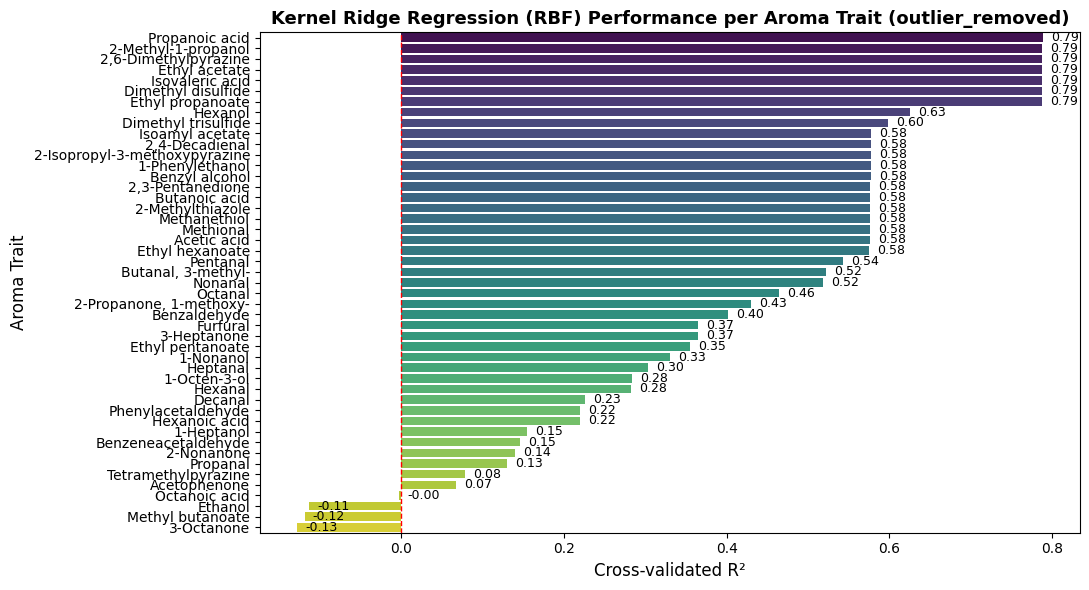


 High-performing traits (CV R² ≥ 0.5): 24
→ ['1-Phenylethanol', '2,3-Pentanedione', '2,4-Decadienal', '2,6-Dimethylpyrazine', '2-Isopropyl-3-methoxypyrazine', '2-Methyl-1-propanol', '2-Methylthiazole', 'Acetic acid', 'Benzyl alcohol', 'Butanal, 3-methyl-', 'Butanoic acid', 'Dimethyl disulfide', 'Dimethyl trisulfide', 'Ethyl acetate', 'Ethyl hexanoate', 'Ethyl propanoate', 'Hexanol', 'Isoamyl acetate', 'Isovaleric acid', 'Methanethiol', 'Methional', 'Nonanal', 'Pentanal', 'Propanoic acid']

 Predictions DataFrame ready: (92, 24)
 Common samples: 92

 Correlation matrix saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\gene_predicted_compound_sensory_corr_outlier_removed.csv


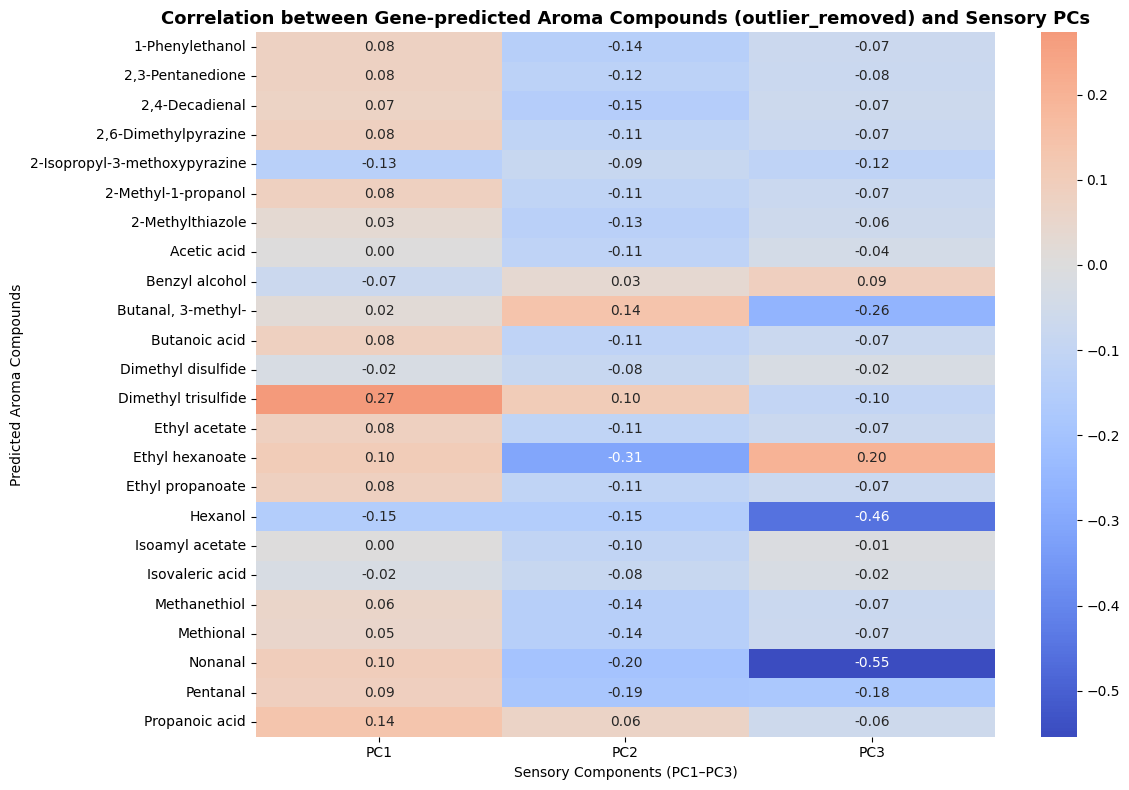


 Top correlations:


PC1  Dimethyl trisulfide     0.273187
PC3  Ethyl hexanoate         0.200782
PC2  Butanal, 3-methyl-      0.139925
PC1  Propanoic acid          0.135401
     Ethyl hexanoate         0.104764
PC2  Dimethyl trisulfide     0.102144
PC1  Nonanal                 0.097359
     Pentanal                0.088023
PC3  Benzyl alcohol          0.087156
PC1  2-Methyl-1-propanol     0.084088
     Ethyl acetate           0.084088
     Ethyl propanoate        0.084088
     2,6-Dimethylpyrazine    0.084088
     Butanoic acid           0.083455
     1-Phenylethanol         0.078800
     2,3-Pentanedione        0.078614
     2,4-Decadienal          0.071797
PC2  Propanoic acid          0.064054
PC1  Methanethiol            0.057936
     Methional               0.053626
dtype: float64

In [37]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import correlate_gene_predictions_with_sensory_pcs




corr_matrix_outlier_removed = correlate_gene_predictions_with_sensory_pcs(
    gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
    snp_df=cleaned_data_gene_aroma,  # 92 samples
    merged_snp_sensory=merged_snp_sensory,  # 94 samples (will auto-align)
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1",
    top_n_snps=6000,
    prune_threshold=0.95,
    r2_threshold=0.5,
    tag="outlier_removed"
)



Top 30 gene-predicted compounds most related to sensory PCs:


Nonanal                          0.284371
Hexanol                          0.253735
Ethyl hexanoate                  0.204213
Dimethyl trisulfide              0.158043
Pentanal                         0.152035
Butanal, 3-methyl-               0.139806
2-Isopropyl-3-methoxypyrazine    0.112366
1-Phenylethanol                  0.097926
2,4-Decadienal                   0.096101
2,3-Pentanedione                 0.092445
Methanethiol                     0.089642
Butanoic acid                    0.089611
Ethyl acetate                    0.088910
2-Methyl-1-propanol              0.088910
Ethyl propanoate                 0.088910
2,6-Dimethylpyrazine             0.088910
Methional                        0.087829
Propanoic acid                   0.086919
2-Methylthiazole                 0.076807
Benzyl alcohol                   0.064544
Acetic acid                      0.052007
Dimethyl disulfide               0.042672
Isovaleric acid                  0.042672
Isoamyl acetate                  0


 Built triangle for 24 compounds × 100 SNPs each.


,Gene (SNP),Compound,Sensory PC,Compound–Sensory Corr
0,GEN__11141,Nonanal,PC3,-0.554058
1,GEN__146182,Nonanal,PC3,-0.554058
2,GEN__145719,Nonanal,PC3,-0.554058
3,GEN__146158,Nonanal,PC3,-0.554058
4,GEN__146076,Nonanal,PC3,-0.554058
5,GEN__145771,Nonanal,PC3,-0.554058
6,GEN__146134,Nonanal,PC3,-0.554058
7,GEN__146093,Nonanal,PC3,-0.554058
8,GEN__146030,Nonanal,PC3,-0.554058
9,GEN__145950,Nonanal,PC3,-0.554058



 SNP Overlap Matrix (top of matrix):


,Nonanal,Hexanol,Ethyl hexanoate,Dimethyl trisulfide,Pentanal,"Butanal, 3-methyl-",2-Isopropyl-3-methoxypyrazine,1-Phenylethanol,"2,4-Decadienal","2,3-Pentanedione",...,Ethyl propanoate,"2,6-Dimethylpyrazine",Methional,Propanoic acid,2-Methylthiazole,Benzyl alcohol,Acetic acid,Dimethyl disulfide,Isovaleric acid,Isoamyl acetate
Nonanal,100,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Hexanol,1,100,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Ethyl hexanoate,0,0,100,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Dimethyl trisulfide,0,0,0,100,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Pentanal,0,0,0,0,100,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


 Overlap heatmap saved to C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\snp_overlap_triangle_heatmap.png


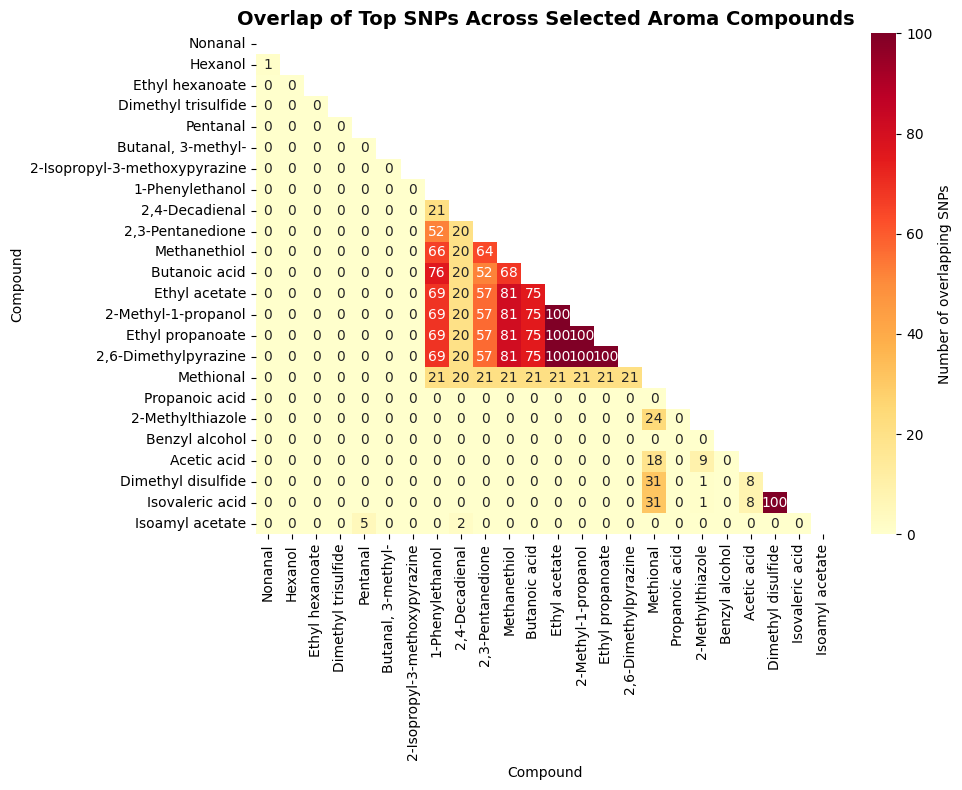

Triangle figure saved to C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\gene_compound_sensory_triangle.png


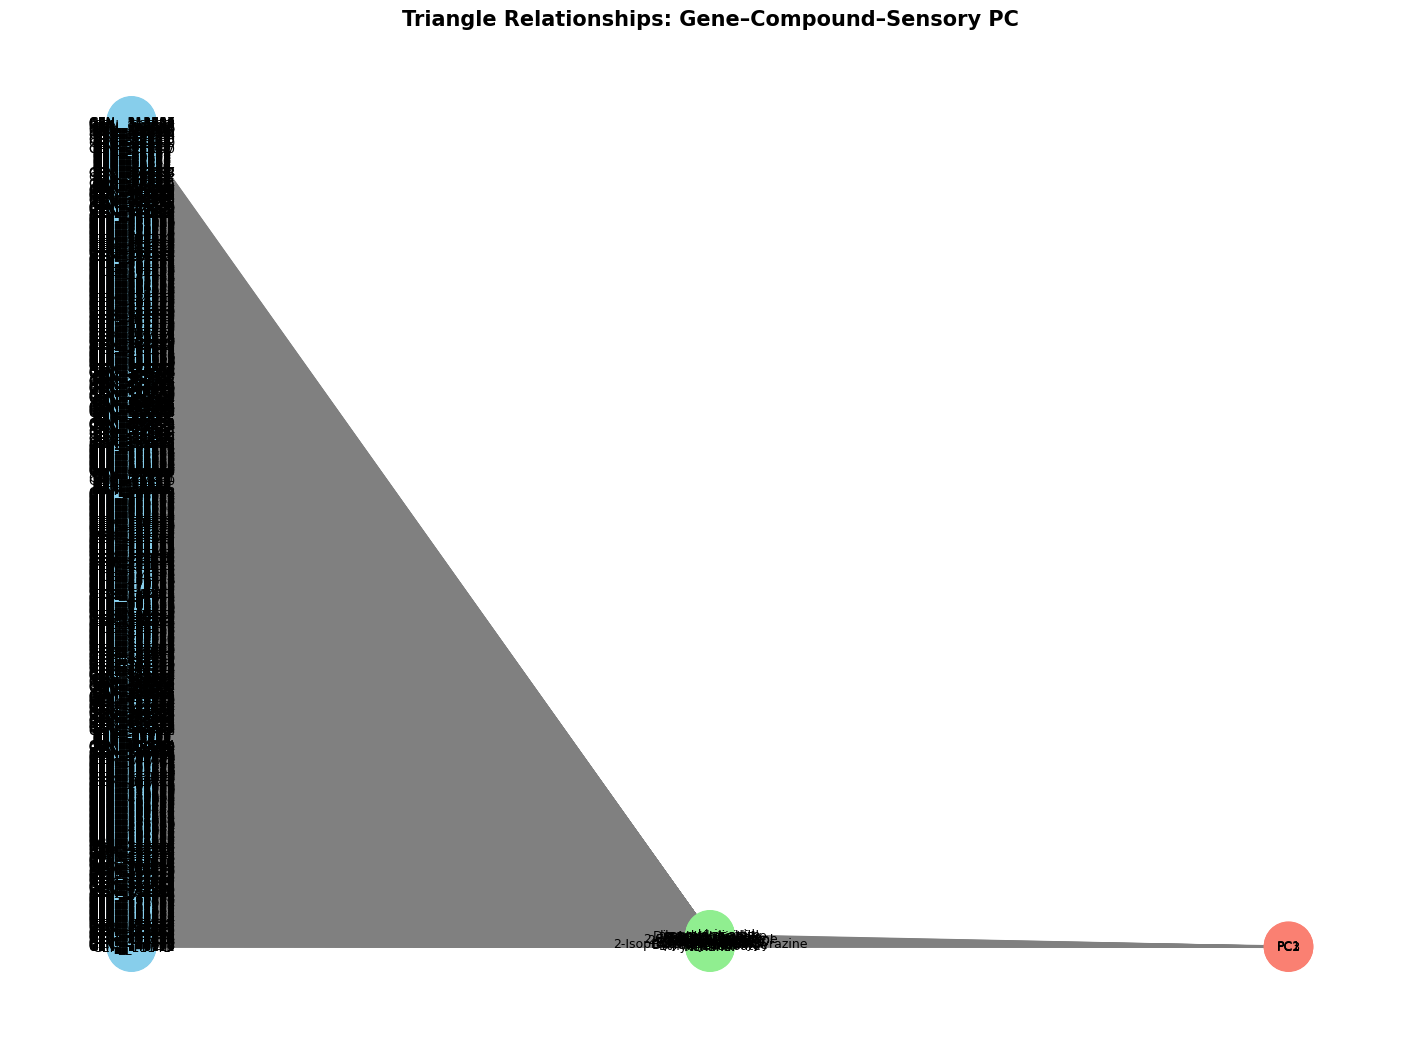

In [38]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import build_gene_compound_sensory_triangle
triangle_df, overlap_matrix = build_gene_compound_sensory_triangle(
    gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
    corr_matrix=corr_matrix_outlier_removed[0],
    corr_threshold=0.1,
    top_compounds=30,
    top_snps_per_compound=100,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1"
)


# Analysis of Gene Marker Effects for Top Correlated Aroma–Sensory Traits


 Found 21 high-correlation compounds (|r| ≥ 0.1):
→ ['Nonanal', 'Hexanol', 'Ethyl hexanoate', 'Dimethyl trisulfide', 'Butanal, 3-methyl-', 'Pentanal', '2,4-Decadienal', '1-Phenylethanol', 'Methional', 'Methanethiol', 'Propanoic acid', '2-Isopropyl-3-methoxypyrazine', '2-Methylthiazole', '2,3-Pentanedione', 'Butanoic acid', 'Acetic acid', 'Ethyl acetate', '2-Methyl-1-propanol', 'Ethyl propanoate', '2,6-Dimethylpyrazine', 'Isoamyl acetate']

 Analyzing 1-Phenylethanol (20 SNPs)...


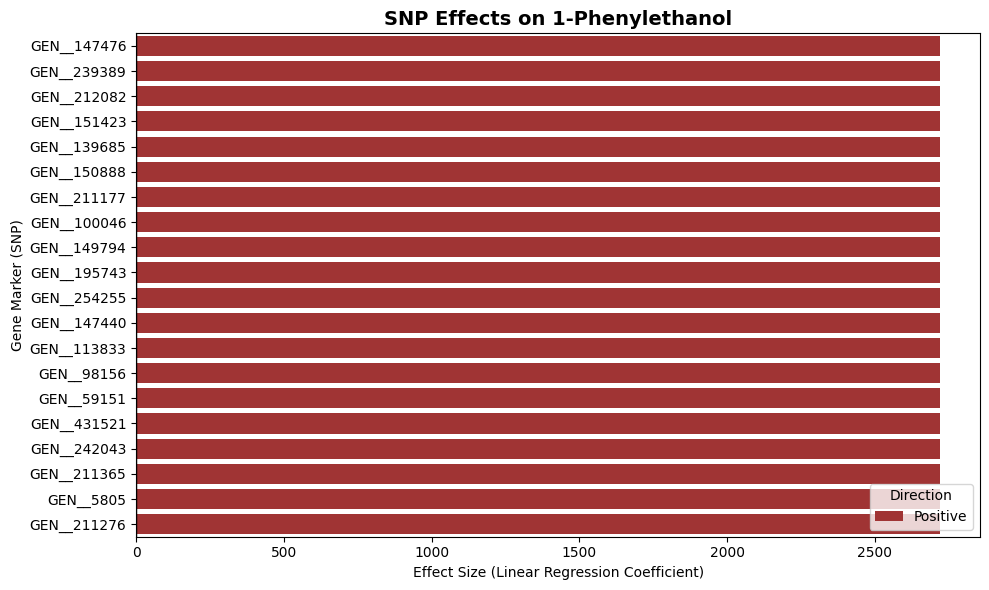


 Analyzing 2,3-Pentanedione (20 SNPs)...


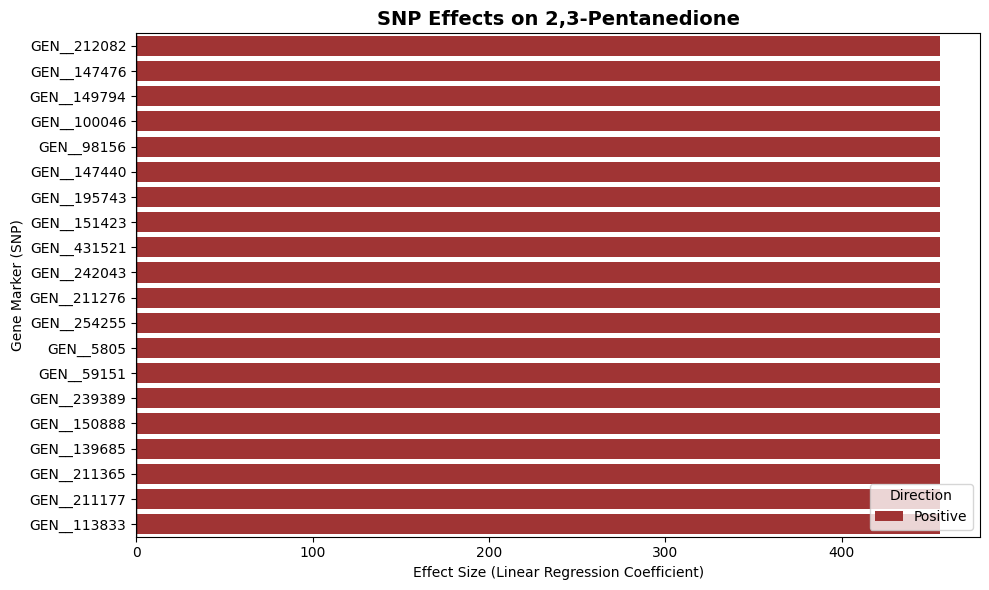


 Analyzing 2,4-Decadienal (20 SNPs)...


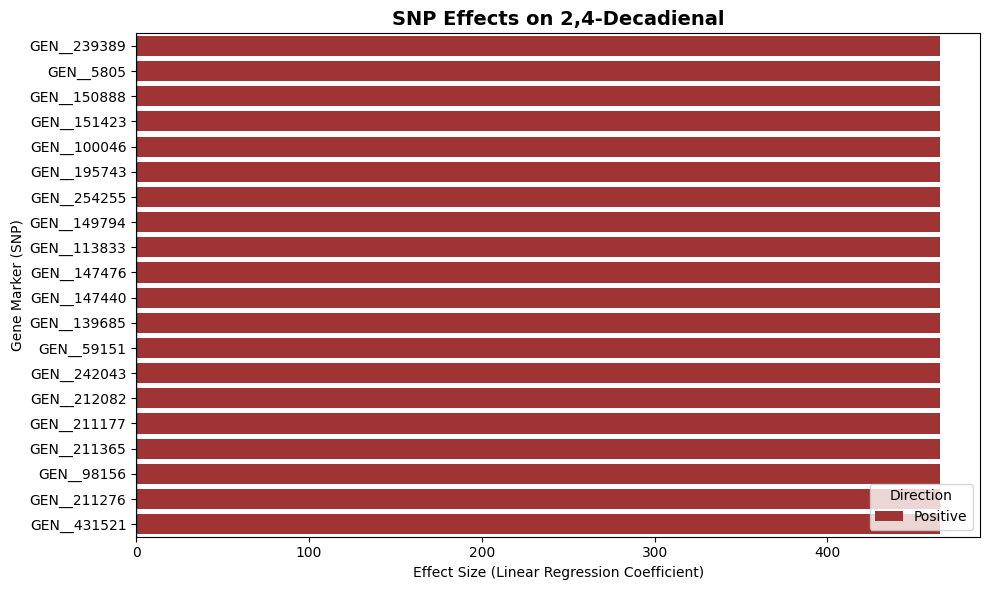


 Analyzing 2,6-Dimethylpyrazine (20 SNPs)...


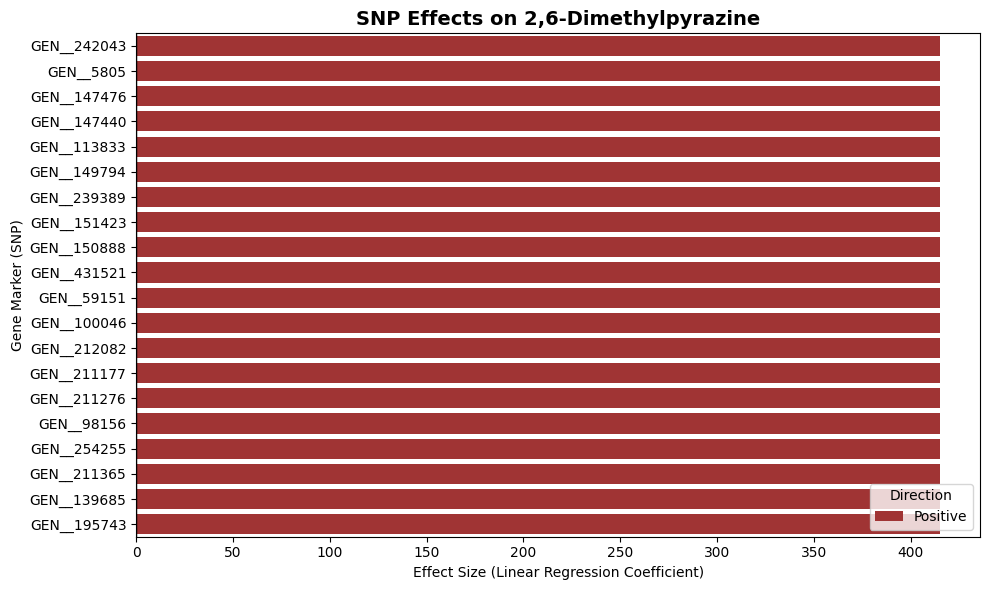


 Analyzing 2-Isopropyl-3-methoxypyrazine (20 SNPs)...


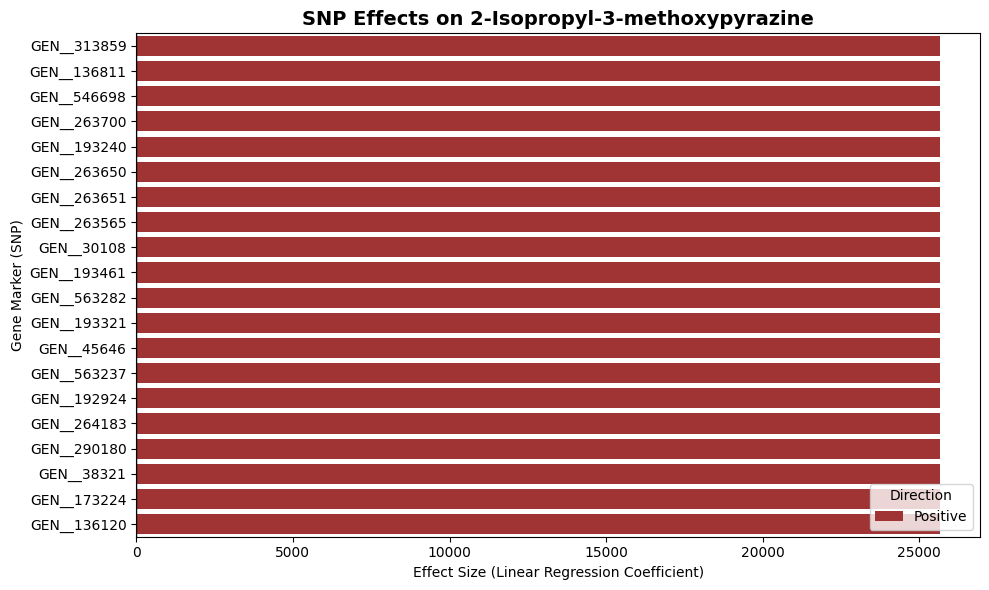


 Analyzing 2-Methyl-1-propanol (20 SNPs)...


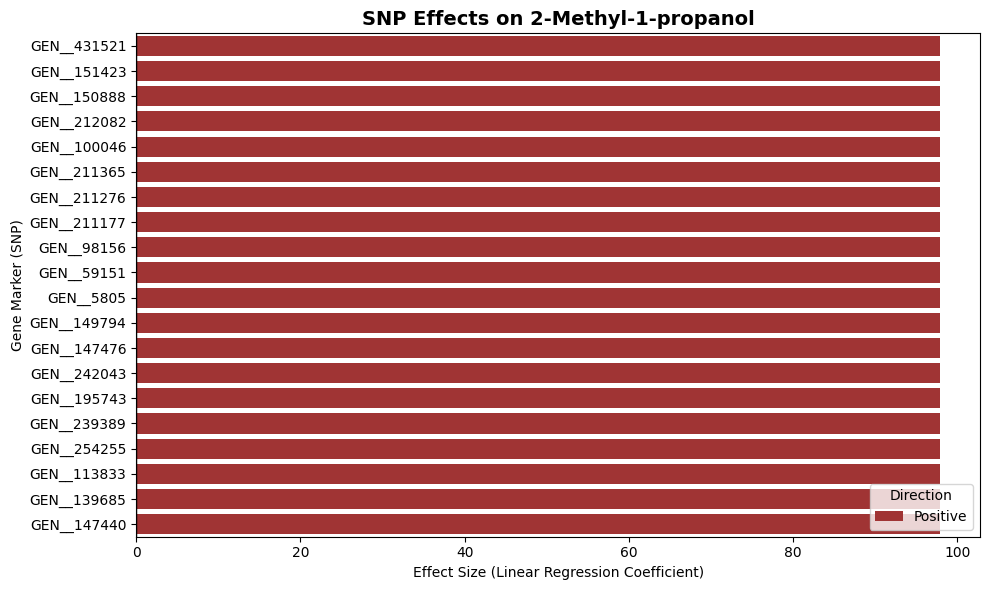


 Analyzing 2-Methylthiazole (20 SNPs)...


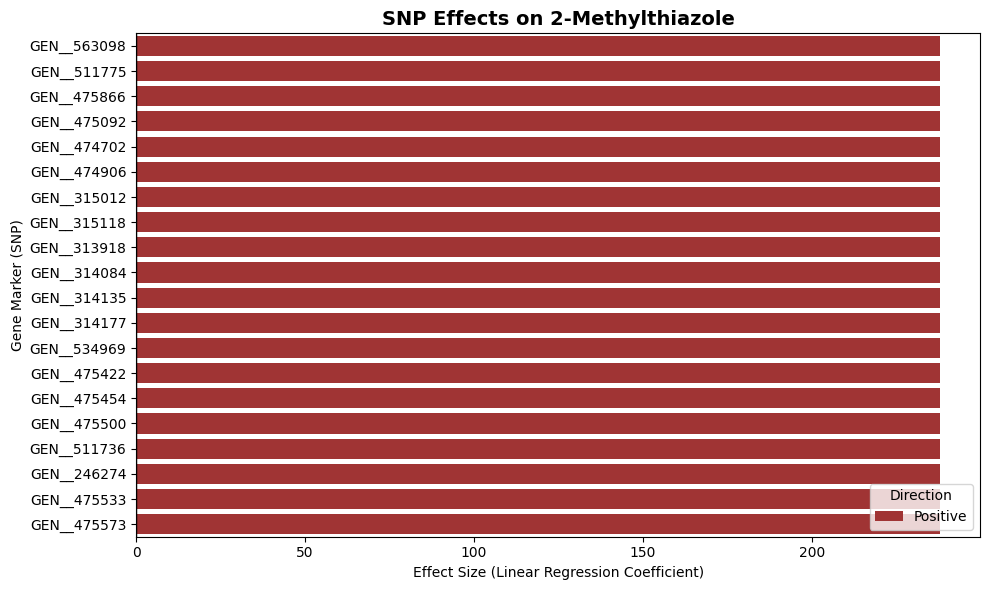


 Analyzing Acetic acid (20 SNPs)...


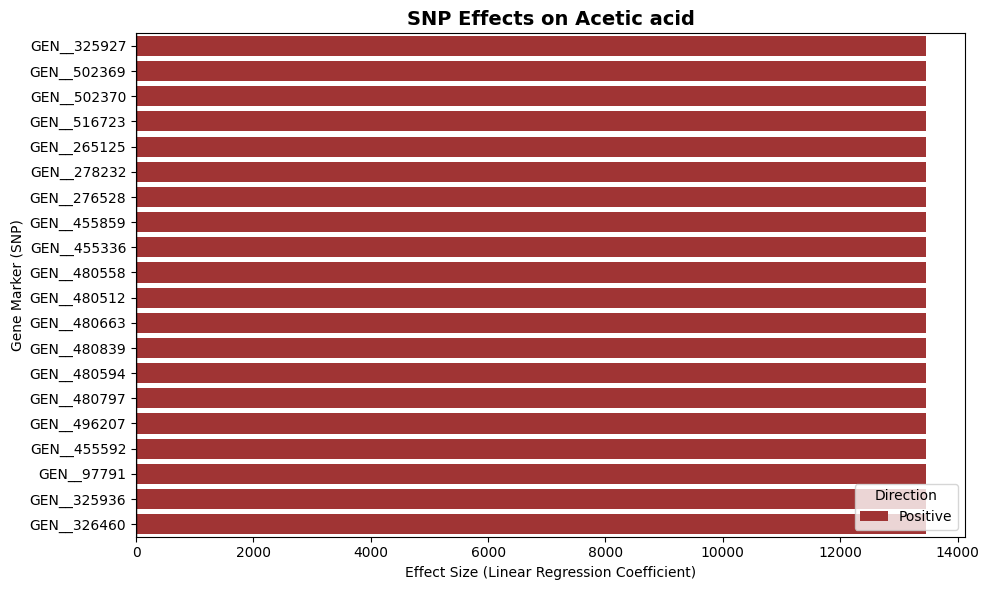


 Analyzing Butanal, 3-methyl- (20 SNPs)...


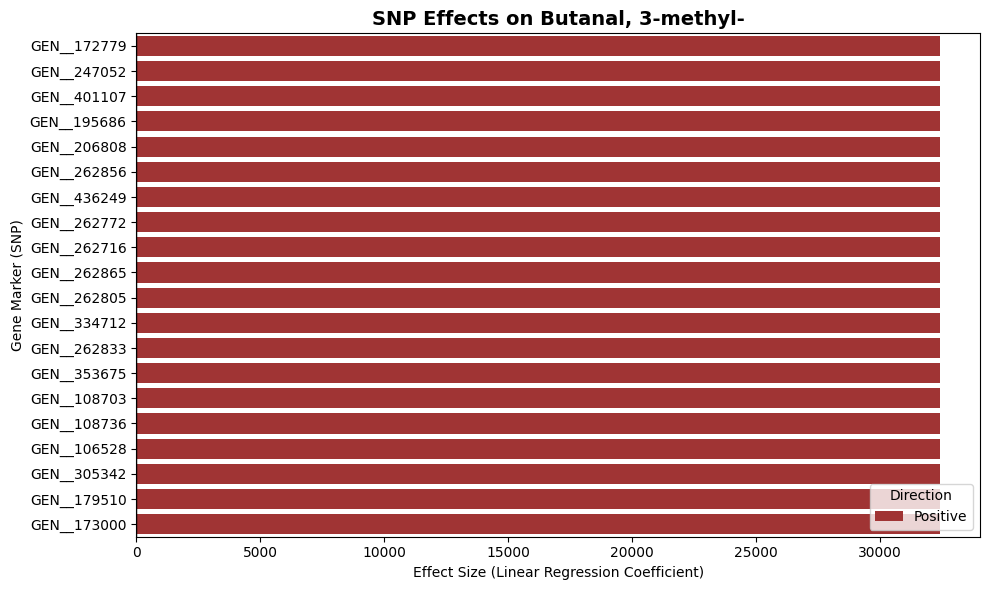


 Analyzing Butanoic acid (20 SNPs)...


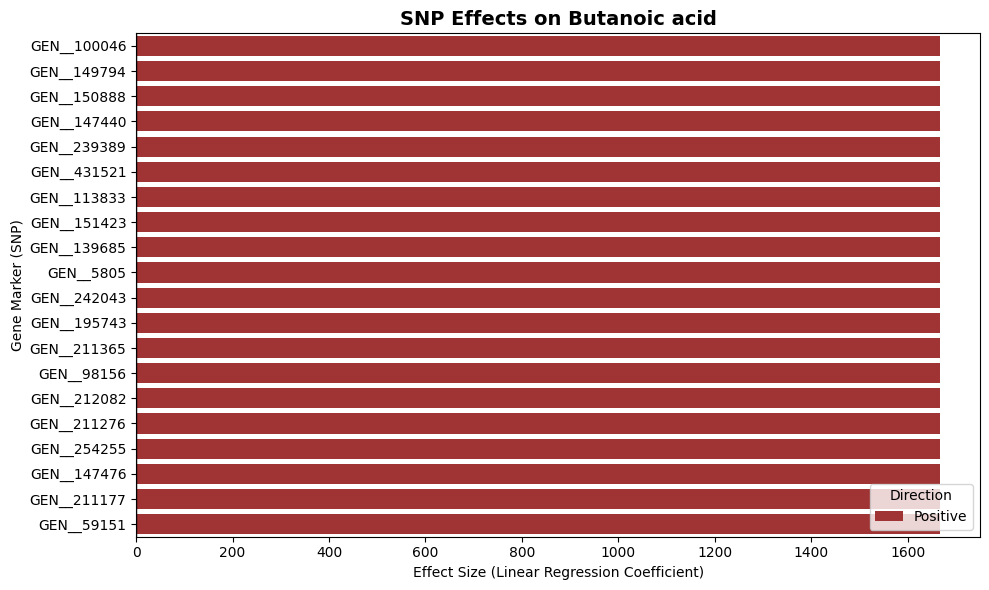


 Analyzing Dimethyl trisulfide (20 SNPs)...


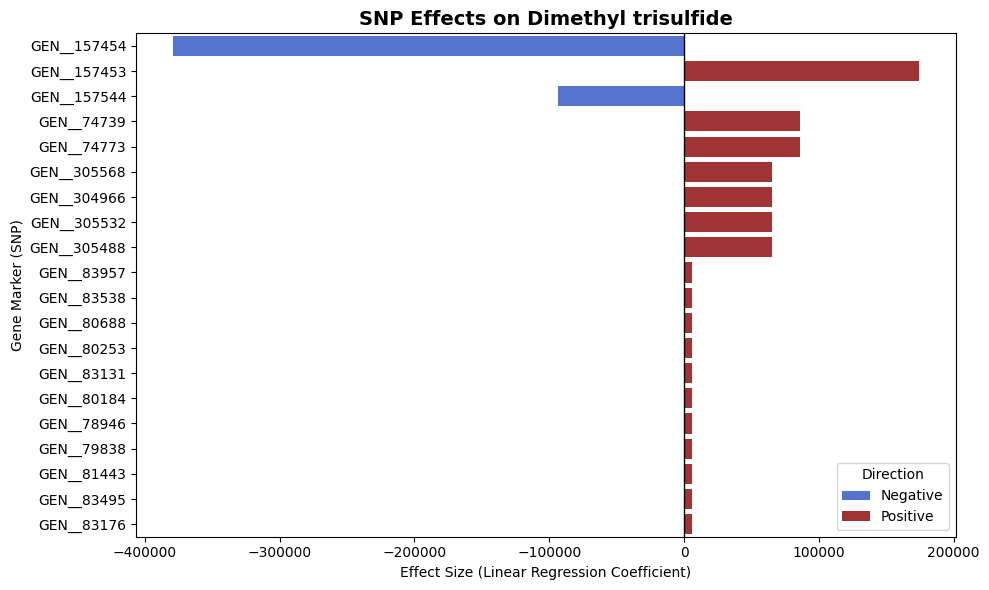


 Analyzing Ethyl acetate (20 SNPs)...


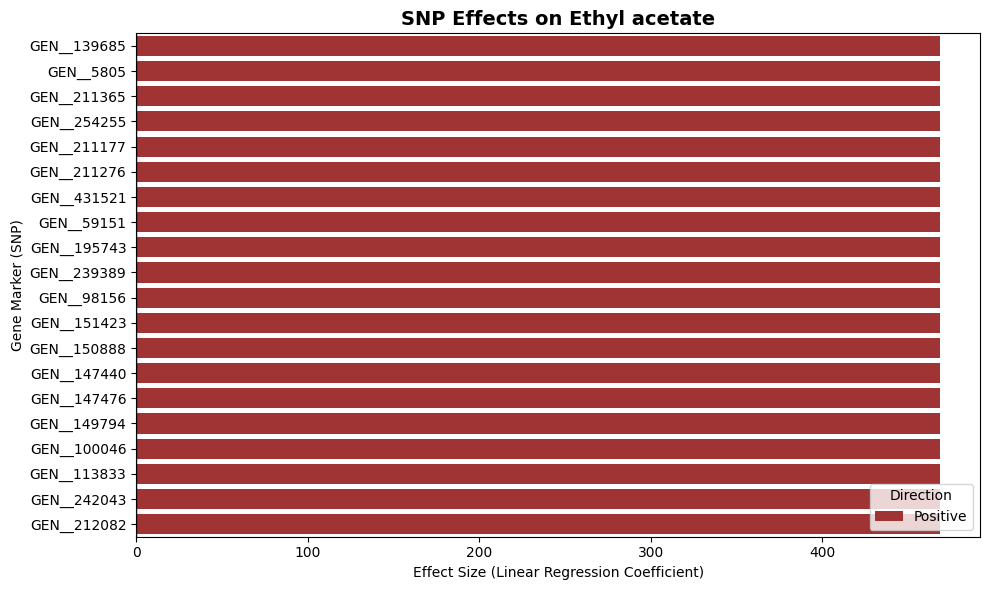


 Analyzing Ethyl hexanoate (20 SNPs)...


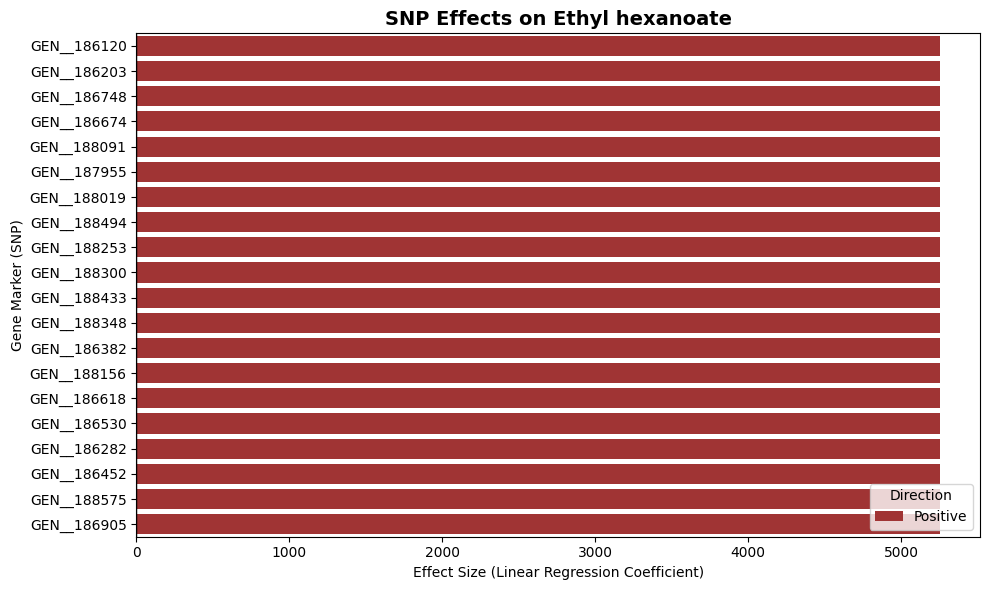


 Analyzing Ethyl propanoate (20 SNPs)...


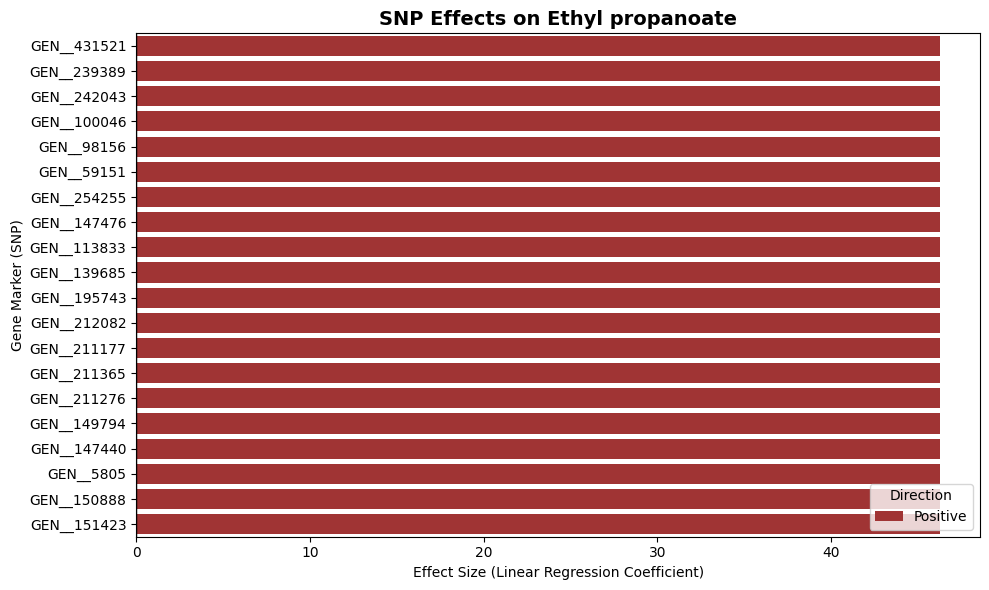


 Analyzing Hexanol (20 SNPs)...


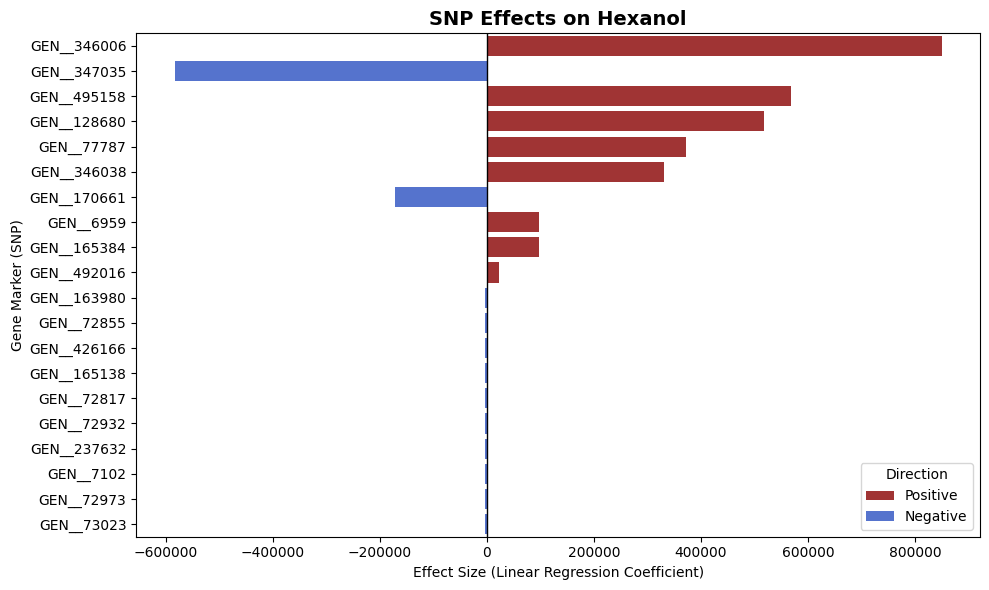


 Analyzing Isoamyl acetate (20 SNPs)...


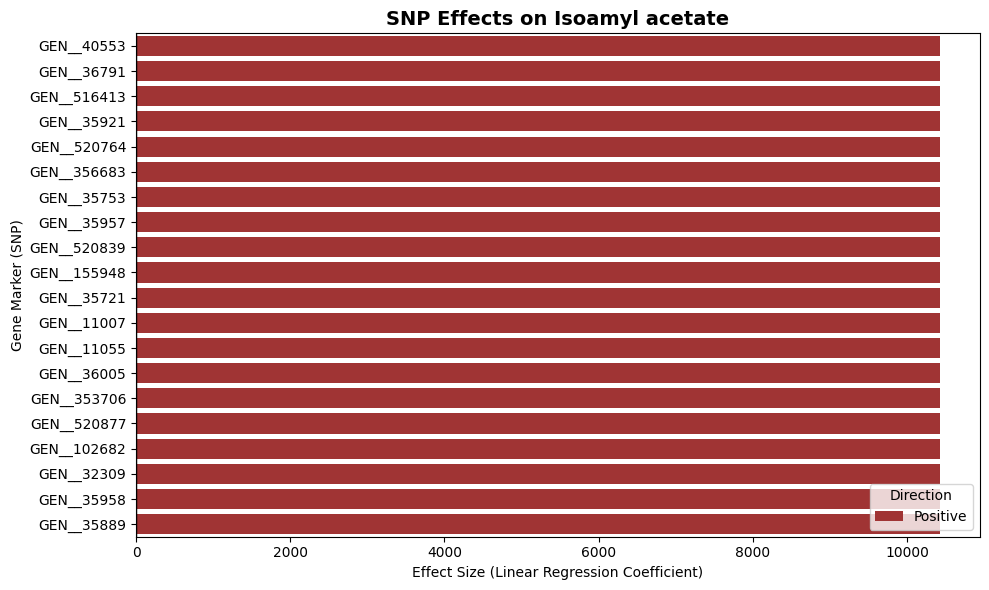


 Analyzing Methanethiol (20 SNPs)...


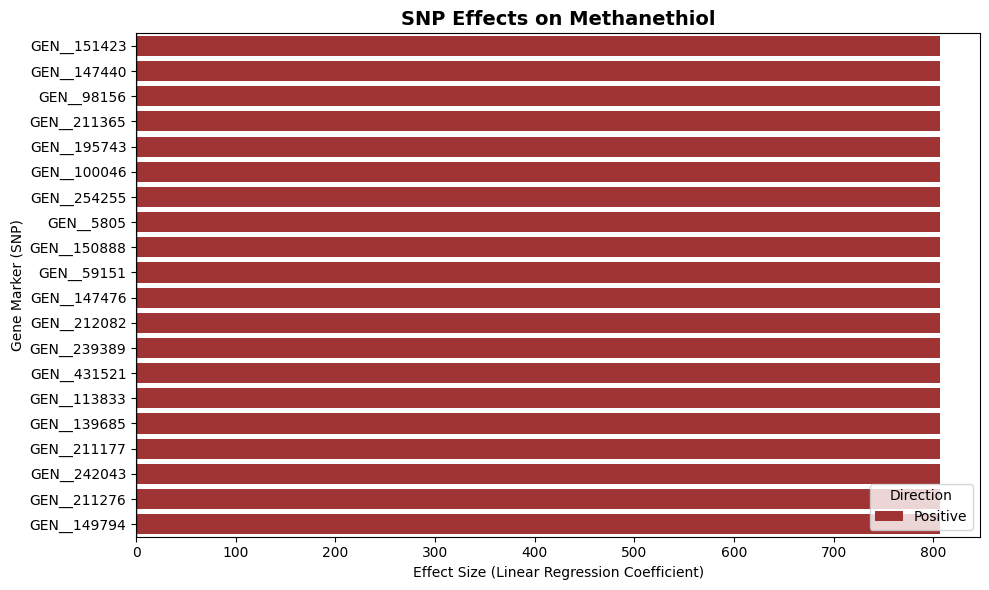


 Analyzing Methional (20 SNPs)...


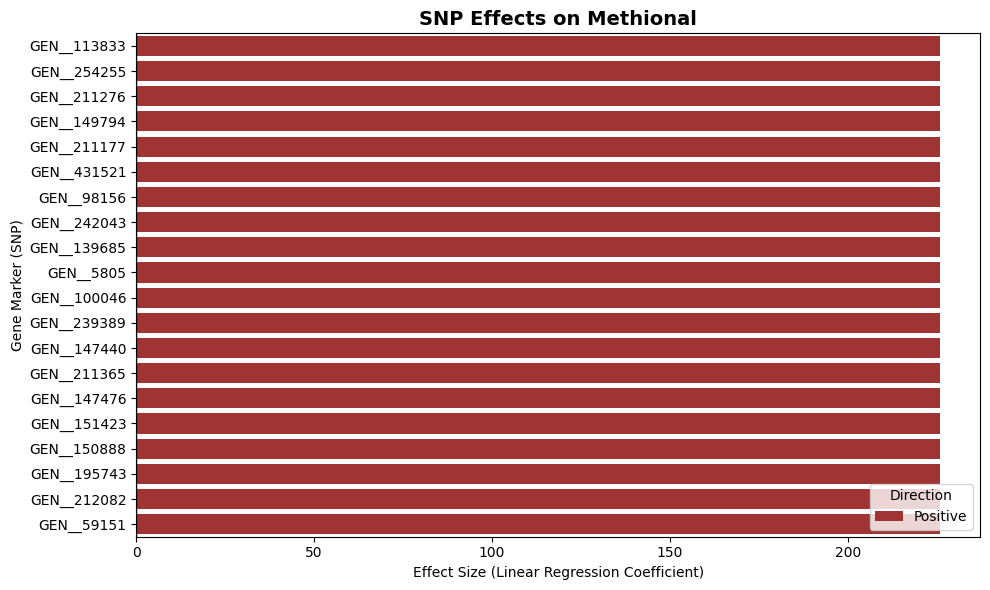


 Analyzing Nonanal (20 SNPs)...


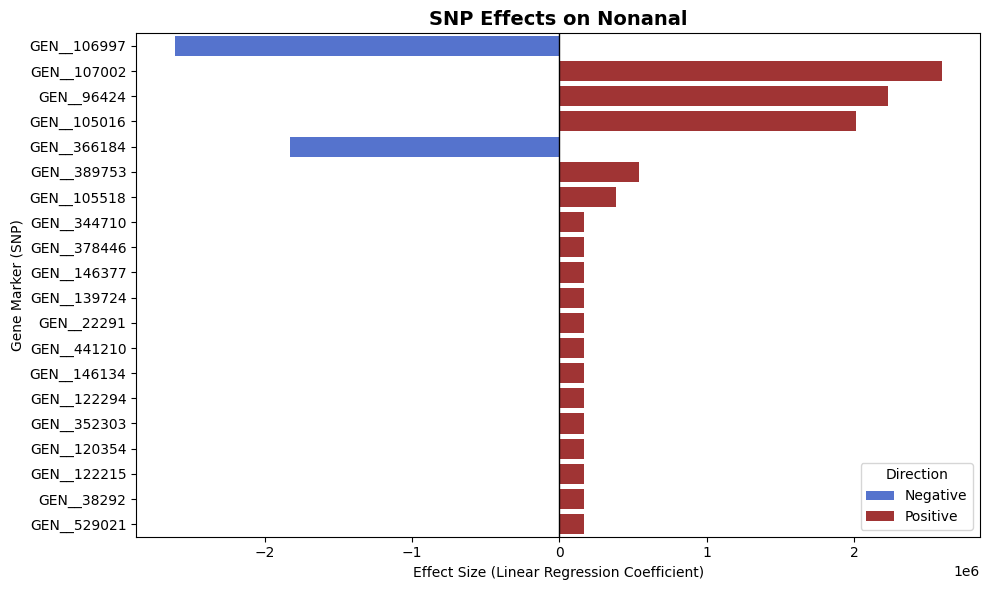


 Analyzing Pentanal (20 SNPs)...


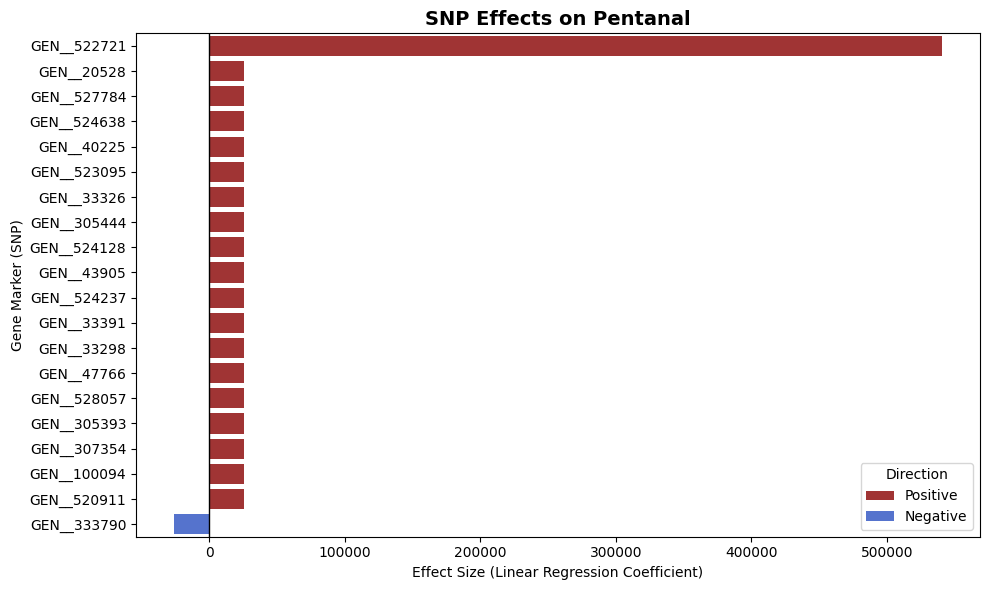


 Analyzing Propanoic acid (20 SNPs)...


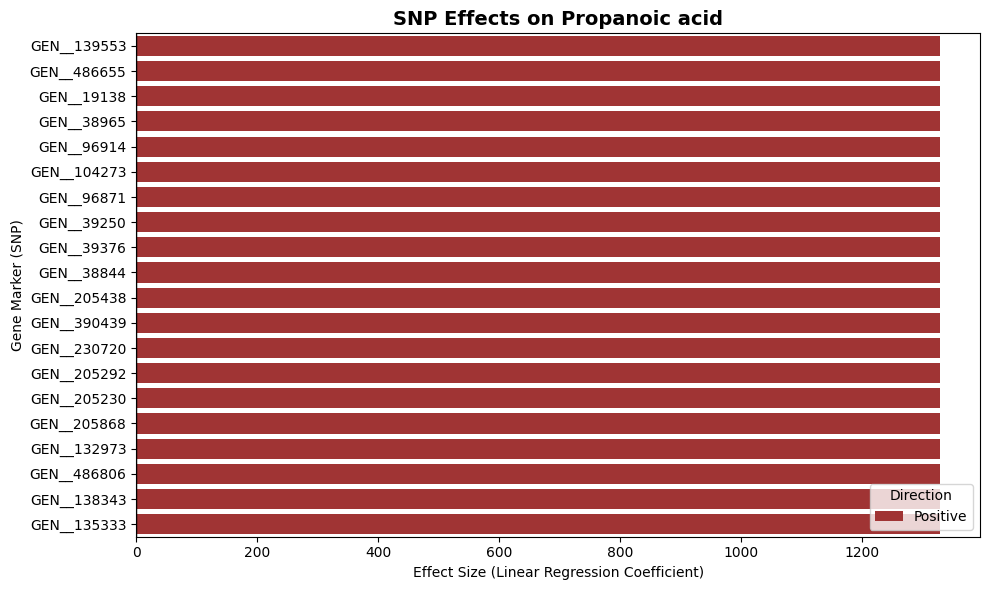


 Finished analyzing SNP effects for high-correlation traits.


In [39]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import  analyze_marker_effects_for_top_correlated_traits


effects_summary = analyze_marker_effects_for_top_correlated_traits(
    gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
    df_aroma=cleaned_data_gene_aroma,
    corr_matrix=corr_matrix_outlier_removed[0] ,   
    corr_threshold=0.1,
    top_snps_per_trait=20,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1"
)



In [40]:
# # ==========================================================
# # 🔺 Build Gene–Compound–Sensory PC Triangle
# # ==========================================================

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import networkx as nx

# # ----------------------------------------------------------
# # Extract top 5 compounds most correlated with sensory PCs
# # ----------------------------------------------------------
# top_compounds = corr.abs().mean(axis=1).sort_values(ascending=False)
# top_traits = top_compounds.head(5).index.tolist()

# print("Top 5 gene-predicted compounds most related to sensory PCs:")
# display(top_compounds.head(5))

# # ----------------------------------------------------------
# # Build triangle relationships: Gene → Compound → Sensory PC
# # ----------------------------------------------------------
# triangle_links = []

# for compound in top_traits:
#     # Step 1: find the sensory PC most correlated with this compound
#     sensory_target = corr_matrix.loc[compound].abs().idxmax()
#     corr_value = corr_matrix.loc[compound, sensory_target]

#     # Step 2: get the top associated genes (SNPs) for this compound
#     top_genes = (
#         gwas_all[gwas_all["Trait"] == compound]
#         .sort_values("p_fdr")
#         .head(10)["SNP"]
#         .tolist()
#     )

#     # Step 3: store the links
#     for gene in top_genes:
#         triangle_links.append({
#             "Gene (SNP)": gene,
#             "Compound": compound,
#             "Sensory PC": sensory_target,
#             "Compound–Sensory Corr": corr_value
#         })

# triangle_df = pd.DataFrame(triangle_links)
# print("\n✅ Triangle relationships (top 5 compounds × top 10 SNPs each):")
# display(triangle_df.head(20))

# # Save results
# triangle_df.to_csv("gene_compound_sensory_triangle.csv", index=False)
# print("Triangle table saved as 'gene_compound_sensory_triangle.csv'")

# # ----------------------------------------------------------
# # 🔺 Visualization — Network Graph (Triangle Layout)
# # ----------------------------------------------------------

# # Create the network graph
# G = nx.Graph()

# # Add nodes and edges
# for _, row in triangle_df.iterrows():
#     G.add_node(row["Gene (SNP)"], color="skyblue", layer="Gene")
#     G.add_node(row["Compound"], color="lightgreen", layer="Compound")
#     G.add_node(row["Sensory PC"], color="salmon", layer="Sensory")

#     G.add_edge(row["Gene (SNP)"], row["Compound"], weight=0.8)
#     G.add_edge(row["Compound"], row["Sensory PC"], weight=abs(row["Compound–Sensory Corr"]))

# # Create a layered layout (Genes left, Compounds center, Sensory right)
# pos = {}
# x_gene, x_comp, x_sens = 0, 1, 2
# y_gap = 1.0

# genes = [n for n, d in G.nodes(data=True) if d["layer"] == "Gene"]
# comps = [n for n, d in G.nodes(data=True) if d["layer"] == "Compound"]
# senses = [n for n, d in G.nodes(data=True) if d["layer"] == "Sensory"]

# for i, g in enumerate(genes):
#     pos[g] = (x_gene, i * y_gap)
# for i, c in enumerate(comps):
#     pos[c] = (x_comp, i * y_gap)
# for i, s in enumerate(senses):
#     pos[s] = (x_sens, i * y_gap)

# # Draw network
# node_colors = [G.nodes[n].get("color") for n in G.nodes]

# plt.figure(figsize=(14, 10))
# nx.draw(
#     G, pos,
#     with_labels=True,
#     node_color=node_colors,
#     node_size=1200,
#     font_size=9,
#     edge_color="gray",
#     width=1.2
# )
# plt.title("Triangle Relationships: Gene–Compound–Sensory PC", fontsize=15)
# plt.axis("off")
# plt.show()


# PLSR Analysis Between High-Predictive Gene-Based Compounds and Reconstructed Sensory Attributes


[KRR — default] Trait: 1-Heptanol

[KRR — default] Trait: 1-Nonanol

[KRR — default] Trait: 1-Octen-3-ol

[KRR — default] Trait: 1-Phenylethanol

[KRR — default] Trait: 2,3-Pentanedione

[KRR — default] Trait: 2,4-Decadienal

[KRR — default] Trait: 2,6-Dimethylpyrazine

[KRR — default] Trait: 2-Isopropyl-3-methoxypyrazine

[KRR — default] Trait: 2-Methyl-1-propanol

[KRR — default] Trait: 2-Methylthiazole

[KRR — default] Trait: 2-Nonanone

[KRR — default] Trait: 2-Propanone, 1-methoxy-

[KRR — default] Trait: 3-Heptanone


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — default] Trait: 3-Octanone

[KRR — default] Trait: Acetic acid

[KRR — default] Trait: Acetophenone


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — default] Trait: Benzaldehyde


...


[KRR — default] Trait: Octanal


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



[KRR — default] Trait: Octanoic acid

[KRR — default] Trait: Pentanal

[KRR — default] Trait: Phenylacetaldehyde

[KRR — default] Trait: Propanal

[KRR — default] Trait: Propanoic acid

[KRR — default] Trait: Tetramethylpyrazine
✅ Results saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_default.csv


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:2240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


📊 Plot saved → C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\krr_models_plot_default.png


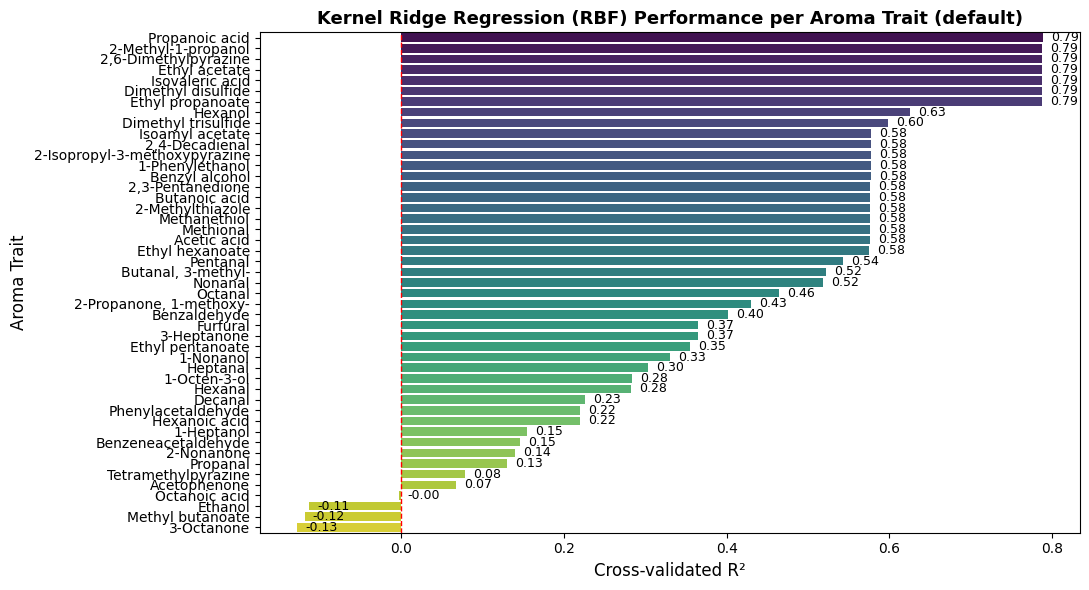

 Common varieties found: 84
 Using 24 high-predictive compounds for PLS
 Fitted PLS model with 5 components

 Correlation between PLS components and sensory attributes:


,METALLIC FLAVOUR,BITTER FLAVOUR,EARTHY FLAVOUR,SOUR FLAVOUR,FRESH FLAVOUR,SWEET FLAVOUR,ROOT/ VEGETABLE FLAVOUR,FARMYARD (GRASS/HAY) FLAVOUR,BITTER AFTERTASTE,SOUR AFTERTASTE,SWEET AFTERTASTE,EARTHY AROMA,FARMYARD,SWEET,STARCHY,DAMP,BUTTERY,FRESH,POTATO STARCH,METALIC
PLS1,0.07,0.11,-0.13,0.20,0.18,0.28,-0.02,-0.07,0.10,0.24,0.27,-0.32,0.13,0.15,-0.38,0.03,0.20,0.38,-0.44,-0.08
PLS2,0.09,0.13,-0.10,0.22,0.05,0.16,-0.09,-0.09,0.14,0.25,0.17,-0.23,0.15,-0.01,-0.42,0.13,0.05,0.29,-0.44,-0.03
PLS3,0.28,0.27,0.31,0.23,-0.24,-0.23,0.25,0.30,0.27,0.21,-0.25,0.24,0.26,-0.15,0.18,0.25,-0.15,-0.19,0.12,0.31
PLS4,-0.18,-0.18,-0.13,-0.19,-0.06,-0.07,-0.26,-0.20,-0.16,-0.19,-0.05,0.05,-0.19,-0.15,-0.07,-0.04,-0.16,-0.11,0.04,-0.13
PLS5,0.05,0.05,0.04,0.04,-0.20,-0.16,-0.13,-0.03,0.07,0.04,-0.15,0.13,0.04,-0.25,-0.11,0.17,-0.24,-0.12,-0.04,0.07


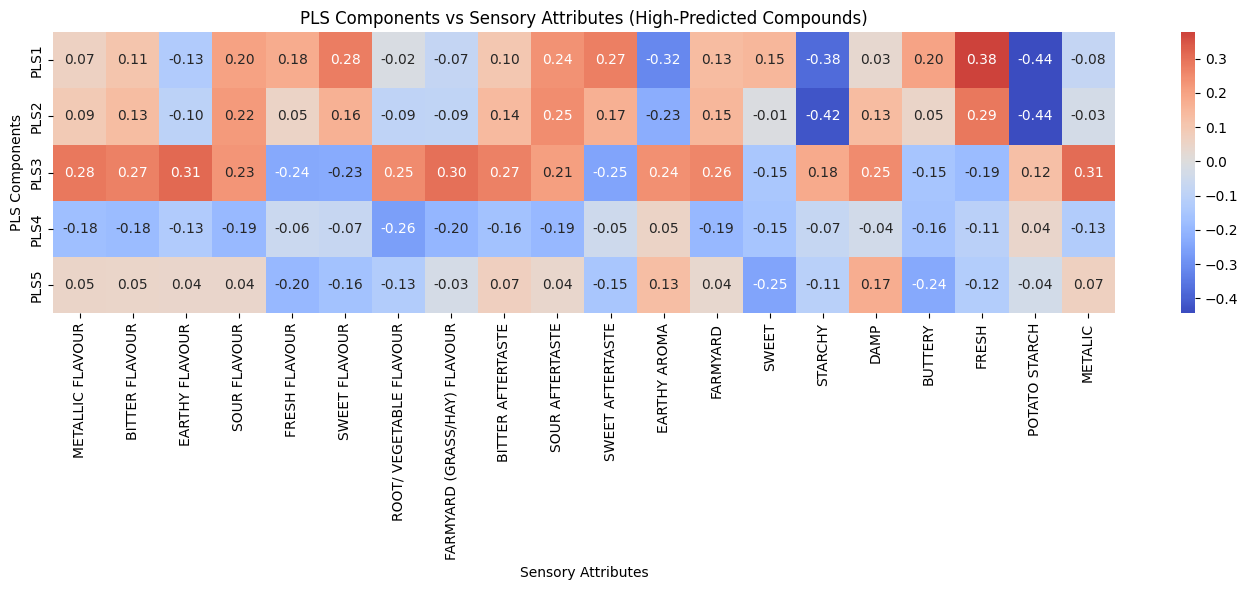

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:3541: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


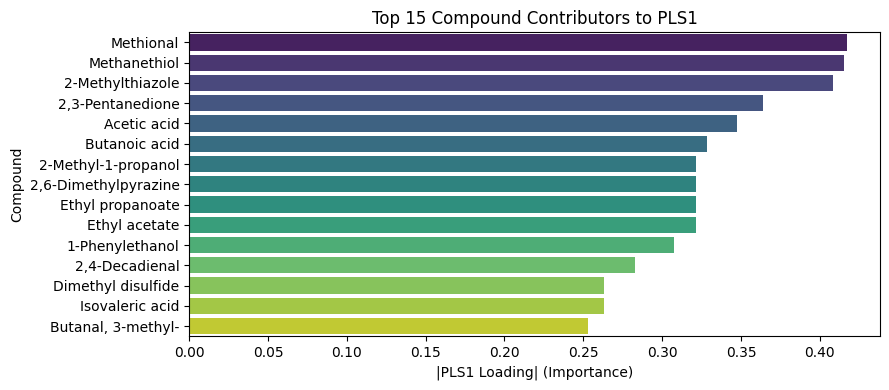

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:3541: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


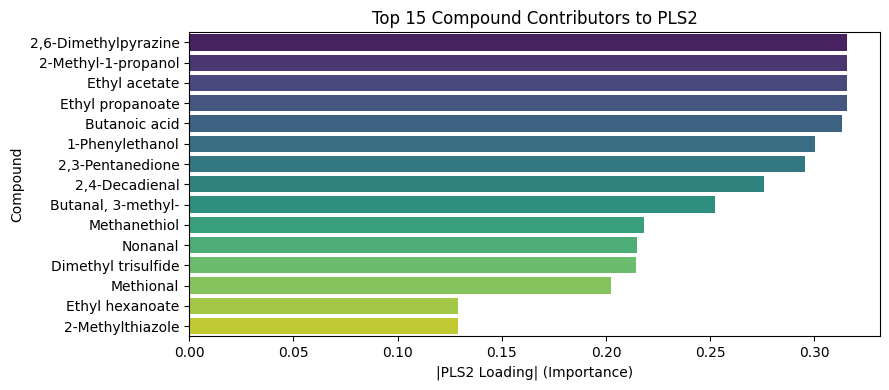

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:3541: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


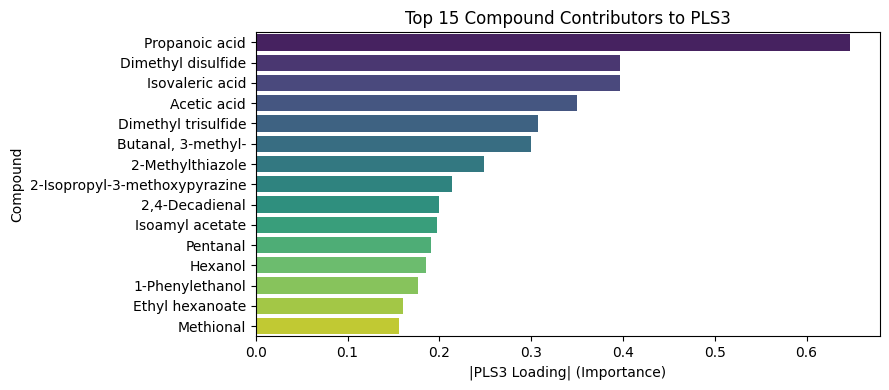

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:3541: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


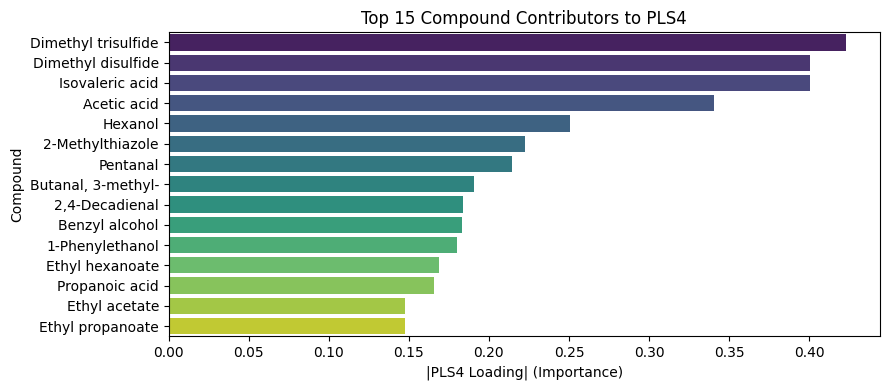

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\genemarker_module.py:3541: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


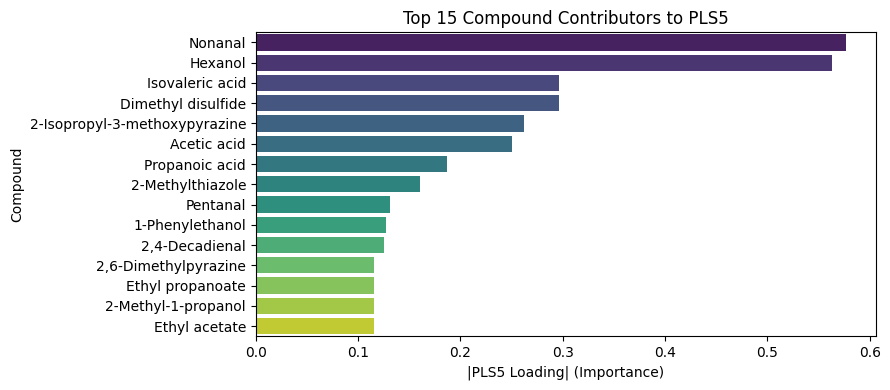


 Flavor alignment per PLS axis:
  PLS1: aligned with POTATO STARCH (negative)
  PLS2: aligned with POTATO STARCH (negative)
  PLS3: aligned with EARTHY FLAVOUR (positive)
  PLS4: aligned with ROOT/ VEGETABLE FLAVOUR (negative)
  PLS5: aligned with SWEET (negative)

 Correlation and loadings files saved successfully:
   → C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\pls_high_predicted_compound_sensory_correlations.csv
   → C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\pls_high_predicted_compound_loadings.csv


In [41]:
import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import run_plsr_gene_predicted_vs_sensory,run_krr_models_gene_aroma





results_krr_outlier_removed, predictions = run_krr_models_gene_aroma(
    gwas_file=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/documents/GitHub/internship/biorep1/save_results/gwas_aroma_all_traits.csv",
    snp_df=cleaned_data_gene_aroma,
    top_n_snps=6000,
    prune_threshold=0.95,
    save_dir=r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1',
    tag='default'
)

high_r2_traits = results_krr_outlier_removed.query("CV_Best_R2 >= 0.5")["Trait"].tolist()


pls_results = run_plsr_gene_predicted_vs_sensory(
    predictions=predictions,
    sensory_reconstructed_path=r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_reconstructed_traits.csv",
    high_r2_traits=high_r2_traits,
    save_dir=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship",
    n_components=5
)

# PLSR Analysis Between Gene-Predicted Aroma Compounds and Sensory Attribute biplot

 Common varieties found: 84
X_scaled shape: (84, 24), Y_scaled shape: (84, 20)
 PLS model fitted successfully!


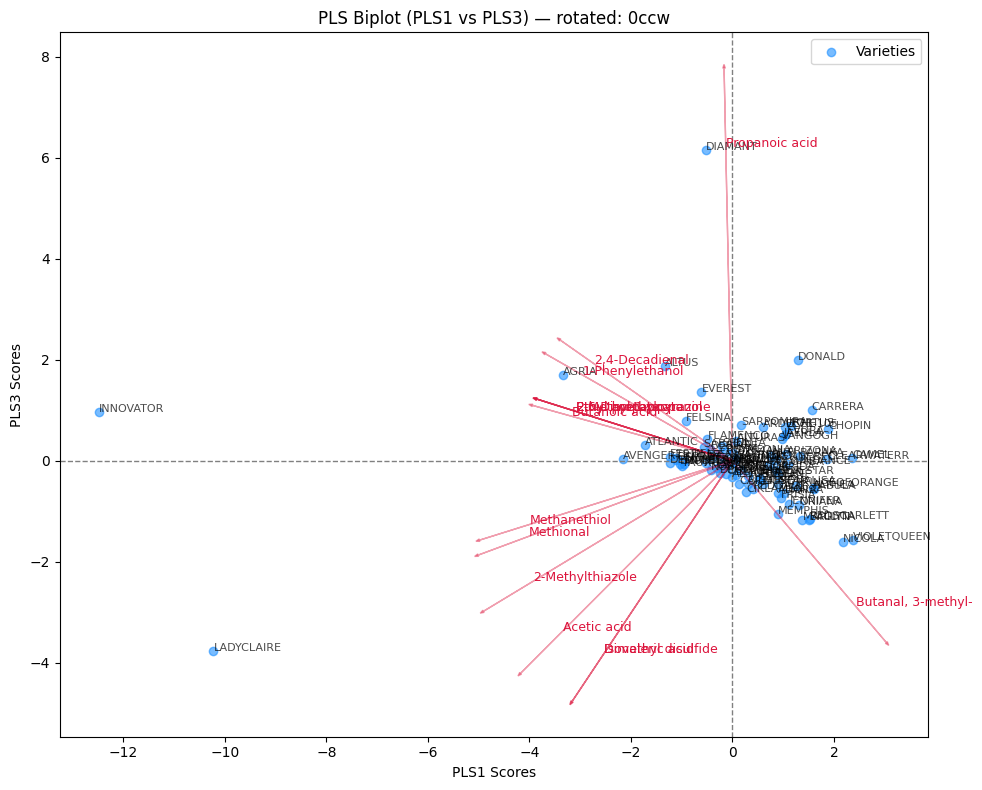

In [42]:

import importlib
import yaml
import genemarker_module
importlib.reload(genemarker_module)
from genemarker_module import  prepare_plsr_data, plot_plsr_biplot


#Prepare data and fit PLS

sensory_reconstructed_path = r"C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/sensory_reconstructed_traits.csv"

#  Make sure 'predictions' and 'high_r2_traits' already exist in memory
X, Y, X_scaled, Y_scaled = prepare_plsr_data(predictions, high_r2_traits, sensory_reconstructed_path)

# Fit PLS model
pls = PLSRegression(n_components=5)
pls.fit(X_scaled, Y_scaled)
print(" PLS model fitted successfully!")


# Visualize PLS biplot

plot_plsr_biplot(
    pls_model=pls,
    X_scaled=pd.DataFrame(X_scaled, index=X.index, columns=X.columns),
    pc1=1,
    pc2=3,
    rotate='0ccw',
    top_n_loadings=15,
    scale_arrows=12
)
